In [1]:
from collections import Counter

import torch

import altair as alt
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from natsort import natsorted
import logomaker

from netam import framework
from dnsmex import dxsm_data, dnsm_zoo
from dnsmex.dnsm_oe import write_sites_oe
from dnsmex.local import localify


from netam.common import heavy_chain_shim
from netam.framework import load_crepe, load_pcp_df
from netam.sequences import translate_sequence, AA_STR_SORTED

from dnsmex.dasm_viz import dms_style_heatmap
from dnsmex.local import localify
from dnsmex.dxsm_data import pcp_df_of_nickname

figures_dir = localify("FIGURES_DIR")

## create solvent accessibility data

/tmp/ipykernel_3806011/166459181.py:89: DtypeWarning: Columns (12,36,42,43,44,45,46,47,48,49,62,77,78,79,80,81,82,83,84,85,92,93,94,100,103,104,108,109,111,112,113,114,115,117,118,119,120,121,123,124,125,127,128,129,130,131,132,133,134,138,139,140,141,142,143,144,154,167,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,233) have mixed types. Specify dtype option on import or set low_memory=False.
  sa_df = pd.read_csv('/fh/fast/matsen_e/nharel/pdb-db.dnsm_1m-v1jaffe+v1tang-joint.ALL.csv')


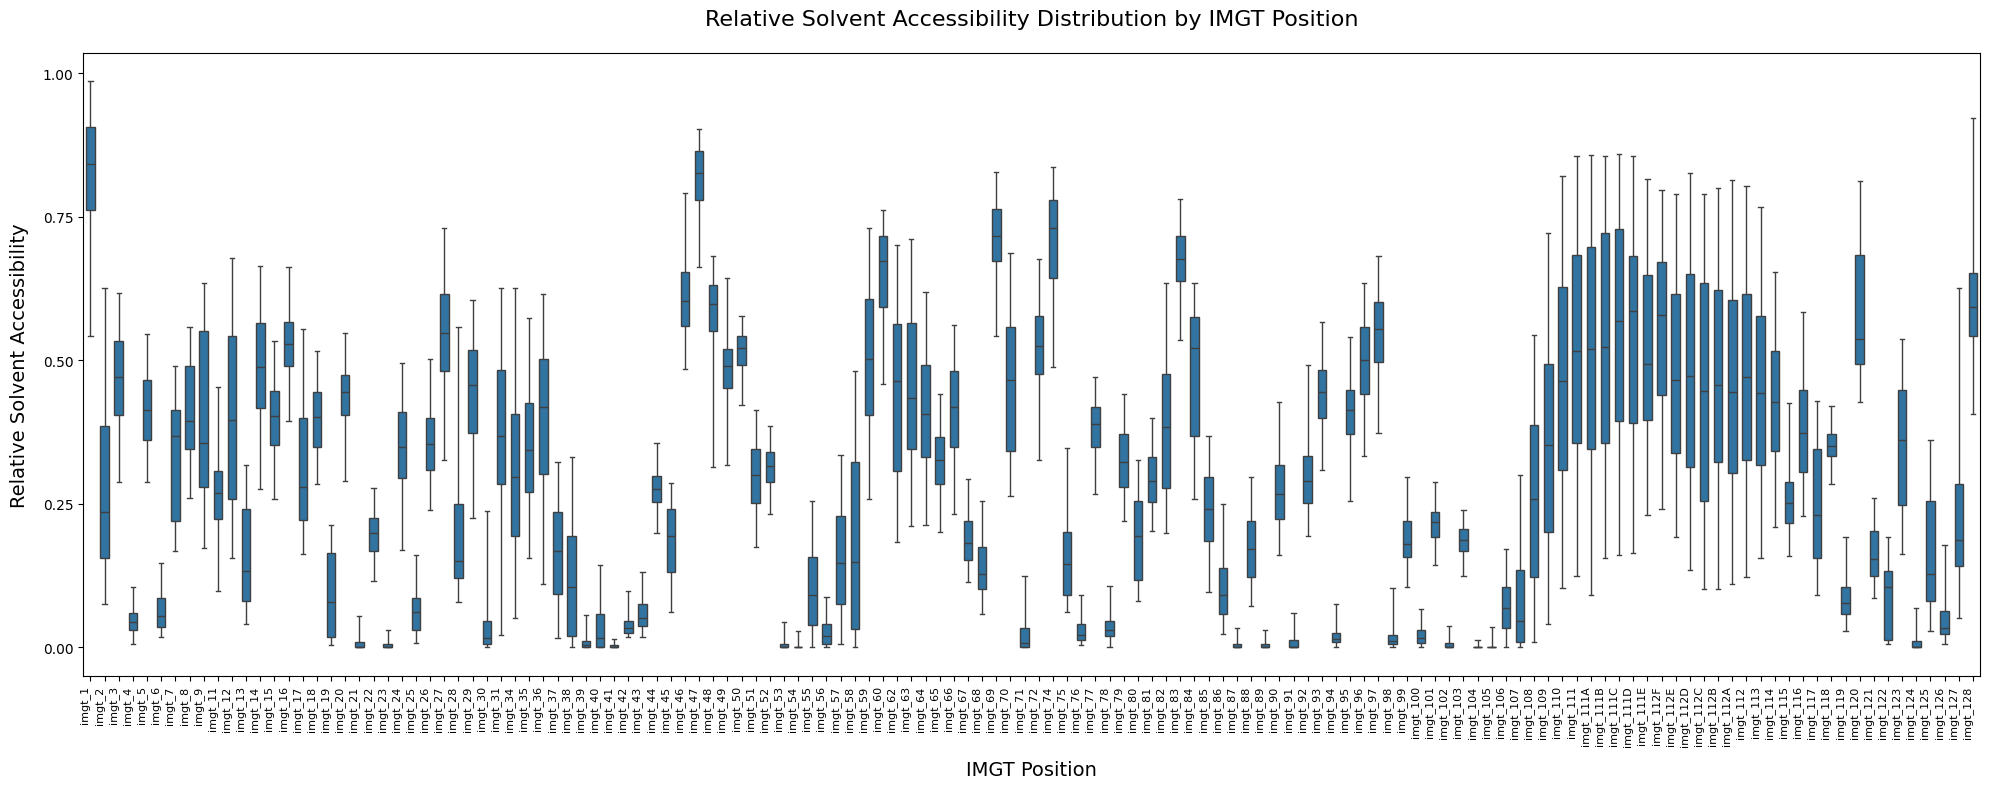

In [3]:



def plot_imgt_solvent_accessibility(df, filter_stat=None, min_percentage=5):
    """
    Create a boxplot of solvent accessibility across IMGT positions.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Dataframe containing the IMGT position columns and solvent accessibility data
    filter_stat : str, optional
        Value to filter the 'stat' column by (e.g., 'rel_asa')
    color_palette : str or list, optional
        Color palette to use for the boxplot (default: 'Blues')
        
    Returns:
    --------
    matplotlib.figure.Figure
        The figure object for further customization or saving
    """
    # Apply filter if specified
    if filter_stat is not None and 'stat' in df.columns:
        df = df[df['stat'] == filter_stat]
    
    # Identify all IMGT position columns - handling both formats: imgt_1 or IMGT_1
    imgt_cols = [col for col in df.columns if col.lower().startswith('imgt_')]
    
    if not imgt_cols:
        raise ValueError("No IMGT position columns found in the dataframe")
    
    # Filter IMGT positions that appear in at least min_percentage of antibodies
    total_rows = len(df)
    threshold = total_rows * (min_percentage / 100)
    
    filtered_cols = []
    for col in imgt_cols:
        non_null_count = df[col].count()  # Count non-null values
        if non_null_count >= threshold:
            filtered_cols.append(col)

    
    # Convert from wide to long format for seaborn
    df_long = pd.melt(
        df, 
        value_vars=filtered_cols,
        var_name='imgt_position', 
        value_name='solvent_accessibility'
    )
    df_long['solvent_accessibility'] = df_long['solvent_accessibility'].astype(float)

    # Set up the figure with appropriate size
    plt.figure(figsize=(20, 8))
    
    # Create the boxplot
    ax = sns.boxplot(
        x='imgt_position',
        y='solvent_accessibility',
        data=df_long,
        width=0.6,
        fliersize=3,
        linewidth=1,
        showfliers=False,
        whis=(5,95),  # Adjust whiskers to show 90% range
    )
    
    # Customize the plot
    plt.title('Relative Solvent Accessibility Distribution by IMGT Position', fontsize=16, pad=20)
    plt.xlabel('IMGT Position', fontsize=14, labelpad=10)
    plt.ylabel('Relative Solvent Accessibility', fontsize=14, labelpad=10)
    
    # FIXED: Properly set y-ticks using np.linspace
    # Create 5 evenly spaced ticks between 0 and 1
    y_ticks = np.linspace(0, 1, 5)
    ax.set_yticks(y_ticks)
    #ax.set_yticklabels([f'{y:.1f}' for y in y_ticks])  # Format to show one decimal place
    
    # If there are many IMGT positions, rotate the x-axis labels
    if len(imgt_cols) > 10:
        plt.xticks(rotation=90, ha='right', fontsize=8)
    
    # Ensure tight layout
    plt.tight_layout()
    
    medians = df_long.groupby('imgt_position', sort=False)['solvent_accessibility'].median().reset_index()
    medians['imgt_position'] = medians['imgt_position'].str.replace('imgt_', '', case=False)
    for i,j in enumerate('ABCDEFGHIJ'):
        medians['imgt_position'] = medians['imgt_position'].str.replace(j, '.' + str(i+1), case=False)

    return medians

sa_df = pd.read_csv('/fh/fast/matsen_e/nharel/pdb-db.dnsm_1m-v1jaffe+v1tang-joint.ALL.csv')
sa_df_filtered = sa_df = sa_df[(sa_df['organism'] == 'human_ig') & (sa_df['source'] == 'opig-imgt') & (sa_df.chain_type == 'H') & (sa_df['stat'] == 'rel_asa')]
solvent_accessibilities_median_df = plot_imgt_solvent_accessibility(sa_df_filtered[sa_df_filtered['stat'] == 'rel_asa'])

solvent_accessibilities_median_df['imgt_position'] = solvent_accessibilities_median_df['imgt_position'].astype(float)

In [4]:
sa_df.groupby(['j_family']).size().sort_values().tail(n=20)

j_family
IGHJ1,IGHJ5,IGHJ4,IGHJ6       8
IGHJ8,IGHJ5,IGHJ4,IGHJ3      12
IGHJ2,IGHJ4                  13
IGHJ5,IGHJ4,IGHJ8            15
IGHJ6,IGHJ3                  21
IGHJ1,IGHJ4                  26
IGHJ4,IGHJ3                  26
IGHJ1,IGHJ5                  38
IGHJ2,IGHJ5,IGHJ4            39
IGHJ4,IGHJ6                  44
IGHJ1,IGHJ5,IGHJ4            66
IGHJ5,IGHJ4                  68
IGHJ1,IGHJ5,IGHJ4,IGHJ3      75
IGHJ2                       178
IGHJ5                       281
IGHJ1                       339
IGHJ3                       414
IGHJ6                       553
IGHJ4                       885
unknown                    3254
dtype: int64

/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home

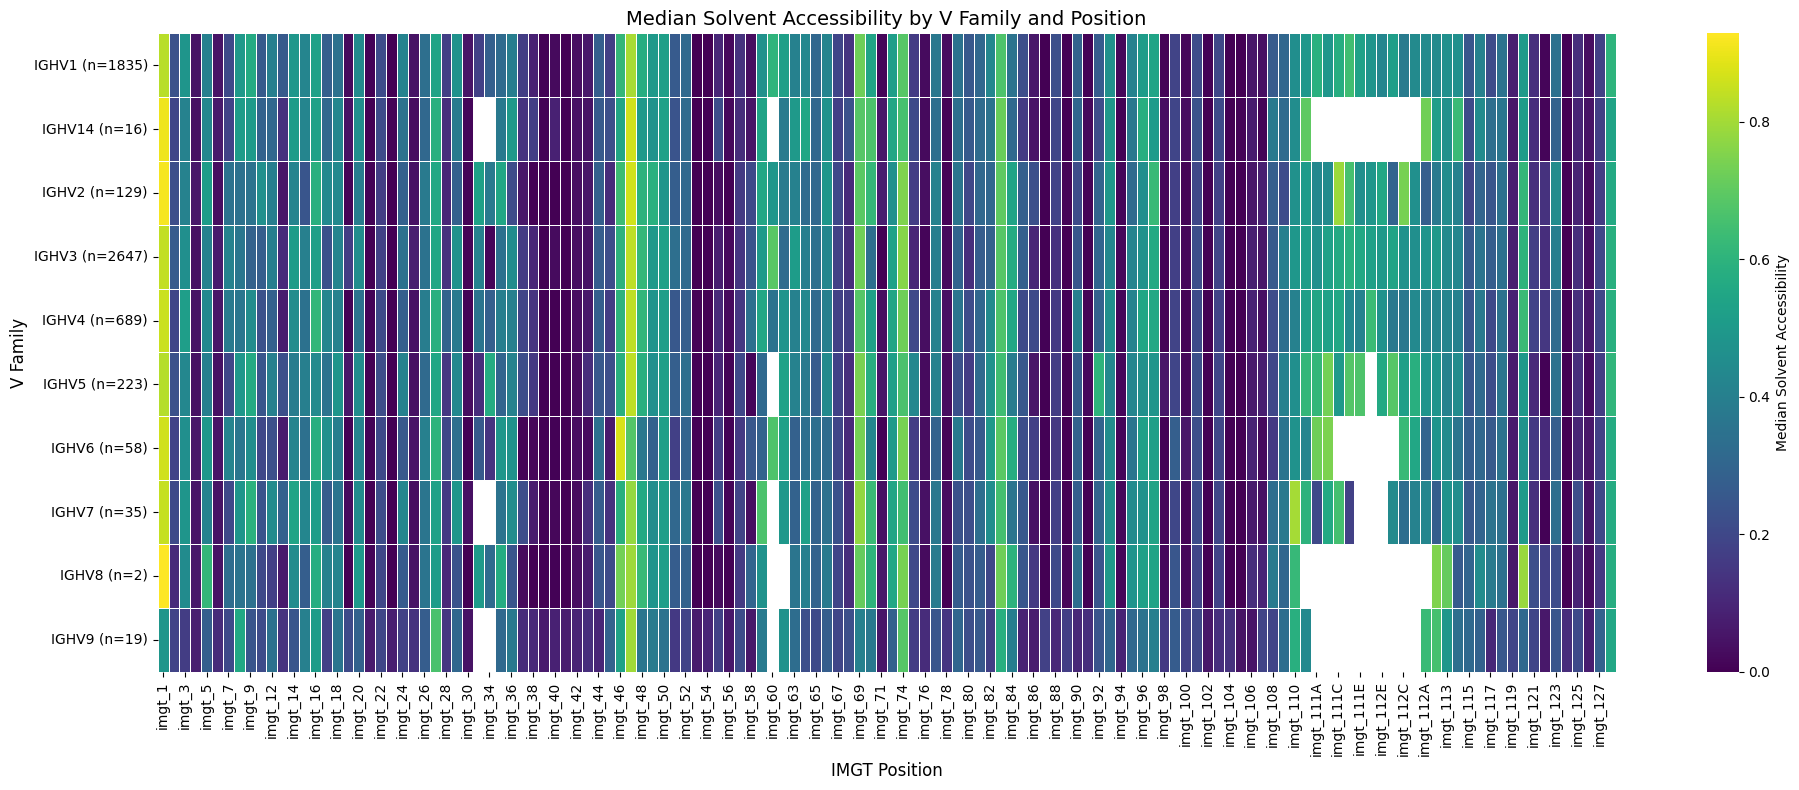

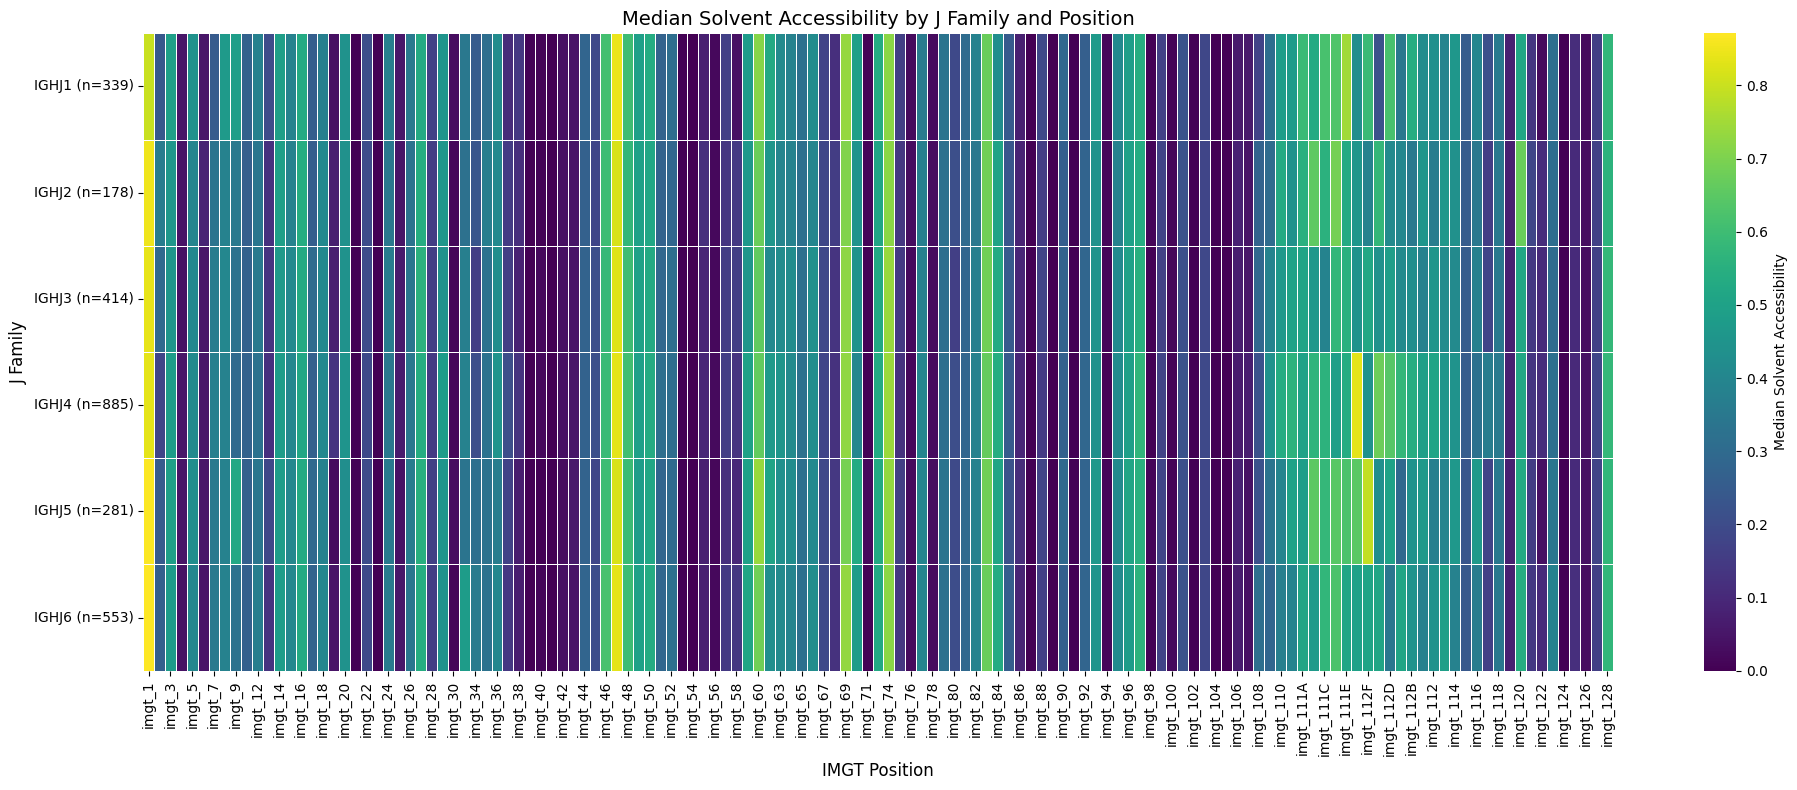

In [5]:
def create_solvent_accessibility_heatmap(df, position_cols, family_col, value_col='solvent_accessibility', 
                                         figsize=(20, 8), cmap='viridis', title=None, min_percentage=5):
    """
    Creates a heatmap of median solvent accessibility values for different positions across gene families.
    Keeps the original order of position columns.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe containing IMGT positions and gene family data
    position_cols : list
        List of column names representing IMGT positions (e.g., 'imgt_1', 'imgt_2', etc.)
    family_col : str
        Column name for the gene family (e.g., 'v_family' or 'j_family')
    value_col : str, optional
        Column name containing the solvent accessibility values, default: 'solvent_accessibility'
    figsize : tuple, optional
        Figure size as (width, height), default: (20, 8)
    cmap : str, optional
        Colormap for heatmap, default: 'viridis'
    title : str or None, optional
        Plot title, default: None (auto-generated)
    min_percentage : float, optional
        Minimum percentage of non-null values required for a position column to be included, default: 5
    
    Returns:
    --------
    tuple
        (fig, ax) - The figure and axis objects
    """
    # Make a copy of the DataFrame to avoid modifications to the original
    df = df.copy()

    # filter out rows with ',' in the family column
    df = df[~df[family_col].str.contains(',')]
    df = df[~df[family_col].str.contains('unknown')]
    
    # Filter IMGT positions that appear in at least min_percentage of antibodies
    total_rows = len(df)
    threshold = total_rows * (min_percentage / 100)
    filtered_position_cols = []
    for col in position_cols:
        non_null_count = df[col].count()  # Count non-null values
        if non_null_count >= threshold:
            filtered_position_cols.append(col)
    
    # Use the filtered position columns
    position_cols = filtered_position_cols
    
    # Convert string columns to numeric
    for col in position_cols:
        if df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Reshape the data for the heatmap
    result_data = []
    
    # Get unique families
    families = df[family_col].unique()
    
    # For each position column, calculate median value per family
    for pos_col in position_cols:
        pos_name = pos_col  # Extract just the position name/number
        
        for family in families:
            # Filter data for this family
            family_data = df[df[family_col] == family]
            
            # Calculate median value for this position and family
            median_value = family_data[pos_col].median()
            
            # Add to result data
            result_data.append({
                'Position': pos_name,
                'Family': family,
                'Median_Value': median_value
            })
    
    # Create a dataframe from the results
    result_df = pd.DataFrame(result_data)
    
    # Pivot the data for the heatmap
    pivot_df = result_df.pivot(index='Family', columns='Position', values='Median_Value')
    
    # Reorder columns to maintain original order from position_cols
    # This is the key change to preserve the original column order
    pivot_df = pivot_df.reindex(columns=position_cols)
    
    # Create the heatmap
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create the heatmap
    sns.heatmap(pivot_df, cmap=cmap, ax=ax, 
                cbar_kws={'label': f'Median {value_col.replace("_", " ").title()}'},
                linewidths=0.5)
    
    # Generate title if not provided
    if title is None:
        title = f'Median {value_col.replace("_", " ").title()} by {family_col.replace("_", " ").title()} and Position'
    
    # Add labels and title
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('IMGT Position', fontsize=12)
    ax.set_ylabel(family_col.replace('_', ' ').title(), fontsize=12)
    
    # Calculate the number of families analyzed
    family_counts = df[family_col].value_counts()
    
    # Modify the y-tick labels to include the count of samples per family
    ylabels = [f"{family} (n={family_counts[family]})" for family in pivot_df.index]
    ax.set_yticklabels(ylabels, rotation=0)
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax

# Assuming df is your dataframe and contains columns like 'imgt_1', 'imgt_2', etc., 'v_family', and 'solvent_accessibility'
position_cols = [col for col in sa_df_filtered.columns if col.startswith('imgt_')]

# # For V families
fig_v, ax_v = create_solvent_accessibility_heatmap(sa_df_filtered, position_cols, 'v_family')

# # For J families
fig_j, ax_j = create_solvent_accessibility_heatmap(sa_df_filtered, position_cols, 'j_family')

## Prep data - Rodriguez dataset

In [6]:
%%bash
## get counts of V and J genes
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 11 | cut -d '-' -f 1 | sort | uniq -c | sort -nr
echo "---"
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 20 | cut -d '*' -f 1 | sort | uniq -c | sort -nr

   9985 IGHV3
   5246 IGHV4
   4328 IGHV1
    944 IGHV5
    771 IGHV2
    351 IGHV6
    129 IGHV7
---
  11562 IGHJ4
   3563 IGHJ6
   2863 IGHJ5
   2825 IGHJ3
    562 IGHJ2
    379 IGHJ1


In [ ]:
dataset_name = "v1rodriguez"
model_name = "dnsm_1m-v1jaffe+v1tang-joint"

crepe_prefix = localify(f"DNSM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DNSM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

try:
    site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
    pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")
    site_sub_probs_df['selection_factor'] = site_sub_probs_df_germline['selection_factor'].apply(lambda x: x.item())


except FileNotFoundError:
    if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
        dnsm_zoo.write_branch_lengths("/fh/fast/matsen_e/shared/bcr-mut-sel/dnsm/dnsm-experiments-1/dnsm-train/trained_models/dnsm_1m-v1jaffe+v1tang-joint", dataset_name, f"{test_output_prefix}.branch_lengths_csv")


    complete_plotter, plotter_dict = write_sites_oe(
        crepe_prefix=crepe_prefix,
        dataset_name=dataset_name,
        branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
        csv_output_path=f"{test_output_prefix}-sites-oe.csv",
        fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
        min_log_prob=-4,
        #v_families=["IGHV1", "IGHV2", "IGHV3", "IGHV4", "IGHV5", "IGHV6", "IGHV7"],
        replace_title=True,
    )
    complete_plotter = complete_plotter["heavy"]


    pcp_df = complete_plotter.pcp_df.copy()
    site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
    for column_name in ['selection_factor', 'neutral_prob', 'prob']:
        site_sub_probs_df[column_name] = site_sub_probs_df[column_name].apply(lambda x: x.item() if hasattr(x, 'item') else x)


    pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
    site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)



    def site_sub_probs_df_without_low_freq(in_plotter, quantile_cutoff=0.05):
        site_sub_probs_df = in_plotter.site_sub_probs_df.copy()
        site_counts = site_sub_probs_df["site"].value_counts()
        cutoff = site_counts.quantile(quantile_cutoff)
        sites_above_cutoff = set(site_counts[site_counts > cutoff].index)
        site_sub_probs_df = site_sub_probs_df[site_sub_probs_df["site"].isin(sites_above_cutoff)]
        return site_sub_probs_df

    def sort_df_by_site(df):
        sorted_index = natsorted(df.index, key=lambda x: df.loc[x, 'site'])
        return df.iloc[sorted_index]

    def build_persite_df(site_sub_probs_df):
        persite_df = site_sub_probs_df.groupby(['site', 'is_cdr']).agg(
            mean_prob=('prob', 'mean'),
            mean_neutral_prob=('neutral_prob', 'mean'),
            mean_selection_factor=('selection_factor', 'mean'),
            mut_freq=('mutation', 'mean')
        ).reset_index()

        persite_df = sort_df_by_site(persite_df)

        return persite_df



Loading /home/nharel/data/v3/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12_MASKED_NI_noN_no-naive.csv.gz
Filtering out problematic pairs of sample_id and clonal families [('sample-igg-SC-18', '440')]
Loading model
Loading model ThriftyHumV0.2-59
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip


Evaluating model: 100%|██████████| 2176/2176 [00:04<00:00, 486.56it/s]


Loading branch lengths


Calculating model predictions: 100%|██████████| 22/22 [03:06<00:00,  8.48s/it]


Preparing heavy chain plot data
ANARCI seq length mismatch! sample-igg-SC-13 2013
ANARCI seq length mismatch! sample-igg-SC-15 925
Invalid IMGT insertion: 68.1 sample-igg-SC-18 440
ANARCI seq length mismatch! sample-igg-SC-19 1803
IMGT mismatch with CDR annotation! sample-igg-W-25 4
IMGT mismatch with CDR annotation! sample-igg-W-19 41
Invalid IMGT insertion: 119.1 sample-igg-W-37 140
IMGT mismatch with CDR annotation! sample-igg-W-37 1
Invalid IMGT insertion: 119.1 sample-igg-W-3 17
Invalid IMGT insertion: 119.1 sample-igg-W-34 200


Calculating model predictions:   0%|          | 0/5 [00:00<?, ?it/s]

In [19]:
# add family annotations to aa and site substitution dfs
pcp_df['j_family'] = pcp_df['j_gene'].str.split('*').str[0]
pcp_df_for_merge = pcp_df.copy()
pcp_df_for_merge = pcp_df_for_merge[['v_gene', 'j_gene', 'v_family', 'j_family', 'sample_id', 'family']]
pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index

site_sub_probs_df = pd.merge(site_sub_probs_df, pcp_df_for_merge, on='pcp_index', how='inner')


## Analysis

In [ ]:
site_sub_probs_df

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,child_aa,v_gene_h,j_gene,v_family,j_family,sample_id,family
0,0.118513,0.078600,0.009315,False,0,1.0,False,CAG,Q,CAG,Q,IGHV7-4-1*02,IGHJ4*02,IGHV7,IGHJ4,sample-igg-SC-24,1401
1,0.035649,0.078600,0.002802,False,1,1.0,False,CAG,Q,CAG,Q,IGHV7-4-1*02,IGHJ4*02,IGHV7,IGHJ4,sample-igg-SC-24,1401
2,0.013648,0.142620,0.001946,False,2,1.0,False,CAG,Q,CAG,Q,IGHV4-59*01,IGHJ4*02,IGHV4,IGHJ4,sample-igg-SC-24,474
3,0.065786,0.180413,0.011869,False,3,1.0,False,CAG,Q,CAG,Q,IGHV4-31*03,IGHJ6*02,IGHV4,IGHJ6,sample-igg-SC-24,238
4,0.013025,0.180413,0.002350,False,4,1.0,False,CAG,Q,CAG,Q,IGHV4-31*03,IGHJ6*02,IGHV4,IGHJ6,sample-igg-SC-24,238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646366,0.002226,0.625077,0.001391,False,21747,128.0,False,TCA,S,TCA,S,IGHV1-8*02,IGHJ1*01,IGHV1,IGHJ1,sample-igg-W-109,62
2646367,0.002697,0.788967,0.002128,False,21748,128.0,False,TCA,S,TCA,S,IGHV3-7*01,IGHJ5*02,IGHV3,IGHJ5,sample-igg-W-109,10
2646368,0.002654,0.788967,0.002094,False,21749,128.0,False,TCA,S,TCA,S,IGHV3-7*01,IGHJ5*02,IGHV3,IGHJ5,sample-igg-W-109,10
2646369,0.002819,0.805355,0.002271,False,21750,128.0,False,TCA,S,TCA,S,IGHV1-18*01,IGHJ4*02,IGHV1,IGHJ4,sample-igg-W-117,10


In [ ]:
## validate analysis with DNSM plot - makes sense

temp_df = site_sub_probs_df[site_sub_probs_df.v_family.isin(['IGHV3', 'IGHV4'])]
temp_df = temp_df.groupby(['v_family', 'site']).selection_factor.mean().reset_index().pivot(index='site', columns='v_family', values='selection_factor')
temp_df['mean_selection_diff'] = temp_df['IGHV3'] - temp_df['IGHV4']
temp_df

v_family,IGHV3,IGHV4,mean_selection_diff
site,,,
1.0,0.660416,0.152905,0.507511
2.0,0.622794,0.594861,0.027933
3.0,0.458353,0.398191,0.060162
4.0,0.238851,0.118600,0.120251
5.0,0.400746,0.348845,0.051901
...,...,...,...
124.0,0.131306,0.203201,-0.071895
125.0,0.519541,0.508542,0.010999
126.0,0.072485,0.097965,-0.025480


<Axes: xlabel='site', ylabel='selection_factor'>

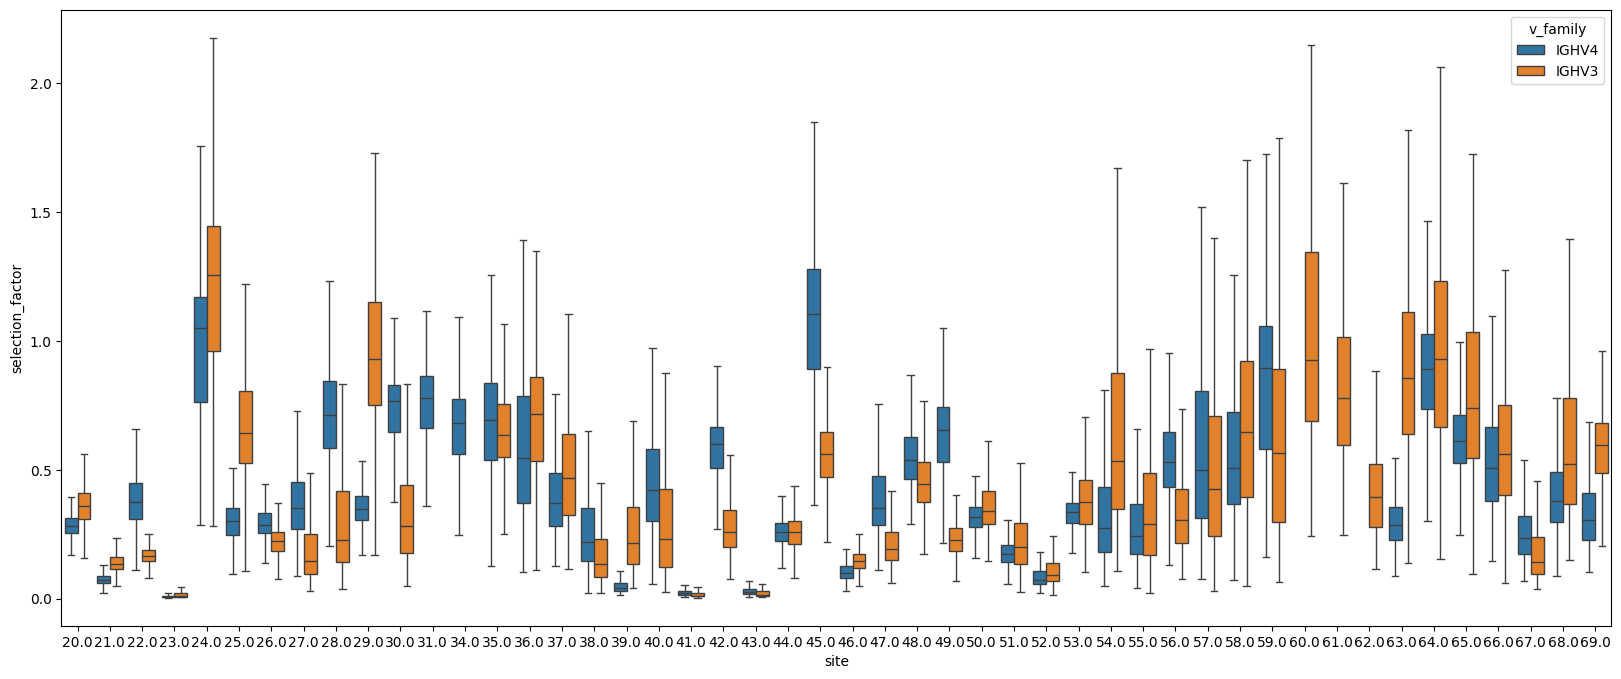

In [ ]:
fig, ax = plt.subplots(figsize=(20, 8))
sns.boxplot(data=site_sub_probs_df[(site_sub_probs_df.site.isin([float(i) for i in list(range(20,70))])) & (site_sub_probs_df.v_family.isin(['IGHV3', 'IGHV4']))], x='site', y='selection_factor', hue='v_family', showfliers=False, ax=ax)



## compare V and J gene families selection factors

In [ ]:
def plot_selection_factor_heatmap(data, family_column='v_family', statistic='mean',
                                 figsize=(20, 3.5), cmap="coolwarm", linewidths=0.5,
                                 title=None, xlabel='Site', ylabel=None, min_pct=0.1, 
                                 display_fam_counts=True):
    """
    Creates a heatmap of selection factors for different immunoglobulin gene families across sites.
    Filters out positions that appear in less than the specified percentage of pcp_index per family.
    
    Additional modification: CDR sites are colored red on x-axis labels.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        The dataframe containing selection factor data
    family_column : str, optional
        Column to use for family grouping ('v_family' or 'j_family'), default: 'v_family'
    statistic : str, optional
        Statistic to plot ('mean' or 'median'), default: 'mean'
    figsize : tuple, optional
        Figure size as (width, height), default: (20, 4)
    cmap : str, optional
        Colormap for heatmap, default: "coolwarm"
    linewidths : float, optional
        Width of cell borders, default: 0.5
    title : str or None, optional
        Plot title, default: None (auto-generated)
    xlabel : str, optional
        X-axis label, default: 'Site'
    ylabel : str or None, optional
        Y-axis label, default: None (auto-generated)
    min_pct : float, optional
        Minimum percentage of pcp_index per family for a position to be included, default: 0.05
    display_fam_counts : bool, optional
        Whether to display family and pcp_index counts, default: True
        
    Returns:
    --------
    tuple
        (fig, ax) - The figure and axis objects
    """
    # Input validation
    if family_column not in ['v_family', 'j_family']:
        raise ValueError("family_column must be either 'v_family' or 'j_family'")
    
    if statistic not in ['mean', 'median']:
        raise ValueError("statistic must be either 'mean' or 'median'")
    
    # Make a copy of the dataframe to avoid modifying the original
    df = data.copy()
    
    # Calculate the number of unique pcp_index per family
    family_pcp_counts = df.groupby(family_column)['pcp_index'].nunique()
    family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
    
    filtered_df = pd.DataFrame()
    # Filter out positions that appear in less than min_pct of pcp_index per family
    for family in df[family_column].unique():
        family_df = df[df[family_column] == family]
        # Count the total number of unique pcp_index values for this family
        total_pcp_indices = family_df['pcp_index'].nunique()
        # For each site, count how many unique pcp_index values it appears with
        site_pcp_counts = family_df.groupby('site')['pcp_index'].nunique()
        # Calculate the percentage of pcp_index coverage for each site
        site_pcp_percentages = site_pcp_counts / total_pcp_indices
        # Keep only sites that appear in at least min_pct of the pcp_indices for this family
        sites_above_threshold = site_pcp_percentages[site_pcp_percentages >= min_pct].index
        # Filter the family dataframe to only include these sites
        filtered_family_df = family_df[family_df['site'].isin(sites_above_threshold)]
        # Add to the overall filtered dataframe
        filtered_df = pd.concat([filtered_df, filtered_family_df])

    # Calculate the selected statistic for each family and site
    if statistic == 'mean':
        heatmap_data = filtered_df.groupby([family_column, 'site'])['selection_factor'].mean().reset_index()
        cbar_label = 'Mean Selection Factor'
    else:  # median
        heatmap_data = filtered_df.groupby([family_column, 'site'])['selection_factor'].median().reset_index()
        cbar_label = 'Median Selection Factor'
    
    # Pivot the data to create a matrix suitable for heatmap
    pivot_data = heatmap_data.pivot(index=family_column, columns='site', values='selection_factor')
    
    # Calculate variability (standard deviation) between families for each position
    position_variability = pivot_data.std()
    #position_variability = (np.std(pivot_data) / np.mean(pivot_data)) * 100
    
    # Get the 5 positions with the highest variability
    top_variable_positions = position_variability.nlargest(5).index.tolist()
    
    # Create the figure and axes
    fig, ax = plt.subplots(figsize=figsize)
    
    # Add extra space at the top of the figure for the title and asterisks
    plt.subplots_adjust(top=0.85, bottom=0.25)  # Added bottom margin for x labels
    
    # Create the heatmap
    heatmap = sns.heatmap(pivot_data,
                cmap=cmap,
                center=1,           # Center the colormap at 1
                vmin=0,
                vmax=2,
                linewidths=linewidths,
                cbar_kws={'label': cbar_label},
                ax=ax)


    # Generate title if not provided
    if title is None:
        family_type = "V Family" if family_column == 'v_family' else "J Family"
        title = f'{statistic.capitalize()} Selection Factor by {family_type} and Site'
    
    # Generate y-label if not provided
    if ylabel is None:
        ylabel = "V Family" if family_column == 'v_family' else "J Family"
    
    # Add labels and title
    ax.set_title(title, fontsize=14, pad=20)  # Reduced title font size
    ax.set_xlabel(xlabel, fontsize=14)        # Reduced x-label font size
    ax.set_ylabel(ylabel, fontsize=14)        # Reduced y-label font size
    
    # Show all tick labels on y-axis with smaller font size
    ax.tick_params(axis='y', which='major', labelsize=8)
    
    # Modify the y-tick labels to include the count of pcp_index per family
    if display_fam_counts:
        ylabels = [f"{family} (n={family_pcp_counts[family]}, families={family_clonal_families_count[family_clonal_families_count[family_column] == family].unique_combinations.values[0]}" for family in pivot_data.index]
    else:
        ylabels = [f"{family}" for family in pivot_data.index]
    ax.set_yticklabels(ylabels, rotation=0, fontsize=9)  # Reduced font size for y-tick labels
    
    # Make sure all y-ticks are shown 
    ax.set_yticks(np.arange(len(pivot_data.index)) + 0.5)
    
    # Determine CDR sites from the original dataframe
    cdr_sites = df[df['is_cdr'] == True]['site'].unique()
    
    # Set x-ticks and labels
    ax.set_xticks(np.arange(len(pivot_data.columns)) + 0.5)
    ax.set_xticklabels(pivot_data.columns, rotation=90, fontsize=7)

    # Force rendering so tick labels exist
    fig.canvas.draw()

    # Color x-tick labels: red for CDR sites, black otherwise
    cdr_sites_str = set(str(s) for s in cdr_sites)  # Ensure all comparisons are string-based

    for label in ax.get_xticklabels():
        site = label.get_text()
        if site in cdr_sites_str:
            label.set_color('red')
            label.set_fontweight('bold')  # Optional
        else:
            label.set_color('black')

    # Set x-ticks and labels normally
    ax.set_xticks(np.arange(len(pivot_data.columns)) + 0.5)
    ax.set_xticklabels(pivot_data.columns, rotation=90, fontsize=7)

    # Color the labels red if they are CDR sites
    for label in ax.get_xticklabels():
        site = label.get_text()
        if site in cdr_sites:
            label.set_color('red')
        else:
            label.set_color('black')
    
    # Highlight the 5 positions with the most variability
    for i, position in enumerate(top_variable_positions):
        # Find the column index of this position
        col_idx = list(pivot_data.columns).index(position)
        
        # Add an asterisk to the top of the column, higher up to avoid overlap
        ax.text(
            col_idx + 0.5,  # x position (middle of column)
            -0,  # y position (at the bottom)
            '*',
            ha='center',
            va='center',
            fontsize=12,  # Slightly reduced asterisk size
            color='black'
        )
    
    # Add a legend for the asterisks
    if top_variable_positions:
        ax.text(
            1.02,  # x position (just outside the right edge)
            -0.3,  # y position (below the plot)
            "* Positions with highest coefficient of variation between families",
            ha='right',
            va='center',
            fontsize=8,  # Reduced legend font size
            transform=ax.transAxes
        )
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax


## counts based approach
def plot_mutation_heatmap(data, family_column='v_family', 
                              figsize=(20, 3.5), cmap="coolwarm", linewidths=0.5,
                              title=None, xlabel='Site', ylabel=None, min_pct=0.1, 
                              display_fam_counts=True):
    """
    Creates a heatmap of mutation frequencies for different immunoglobulin gene families across sites.
    Filters out positions that appear in less than the specified percentage of pcp_index per family.
    
    Additional modification: CDR sites are colored red on x-axis labels.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        The dataframe containing mutation data
    family_column : str, optional
        Column to use for family grouping ('v_family' or 'j_family'), default: 'v_family'
    figsize : tuple, optional
        Figure size as (width, height), default: (20, 4)
    cmap : str, optional
        Colormap for heatmap, default: "coolwarm"
    linewidths : float, optional
        Width of cell borders, default: 0.5
    title : str or None, optional
        Plot title, default: None (auto-generated)
    xlabel : str, optional
        X-axis label, default: 'Site'
    ylabel : str or None, optional
        Y-axis label, default: None (auto-generated)
    min_pct : float, optional
        Minimum percentage of pcp_index per family for a position to be included, default: 0.05
    display_fam_counts : bool, optional
        Whether to display family and pcp_index counts, default: True
        
    Returns:
    --------
    tuple
        (fig, ax) - The figure and axis objects
    """
    # Input validation
    if family_column not in ['v_family', 'j_family']:
        raise ValueError("family_column must be either 'v_family' or 'j_family'")
    
    # Make a copy of the dataframe to avoid modifying the original
    df = data.copy()
    
    # Calculate the number of unique pcp_index per family
    family_pcp_counts = df.groupby(family_column)['pcp_index'].nunique()
    family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
    
    filtered_df = pd.DataFrame()
    # Filter out positions that appear in less than min_pct of pcp_index per family
    for family in df[family_column].unique():
        family_df = df[df[family_column] == family]
        # Count the total number of unique pcp_index values for this family
        total_pcp_indices = family_df['pcp_index'].nunique()
        # For each site, count how many unique pcp_index values it appears with
        site_pcp_counts = family_df.groupby('site')['pcp_index'].nunique()
        # Calculate the percentage of pcp_index coverage for each site
        site_pcp_percentages = site_pcp_counts / total_pcp_indices
        # Keep only sites that appear in at least min_pct of the pcp_indices for this family
        sites_above_threshold = site_pcp_percentages[site_pcp_percentages >= min_pct].index
        # Filter the family dataframe to only include these sites
        filtered_family_df = family_df[family_df['site'].isin(sites_above_threshold)]
        # Add to the overall filtered dataframe
        filtered_df = pd.concat([filtered_df, filtered_family_df])

    # Calculate the mean mutation frequency for each family and site
    heatmap_data = filtered_df.groupby([family_column, 'site'])['mutation'].mean().reset_index()
    # log normalized the data
    #heatmap_data['mutation'] = heatmap_data['mutation'].apply(lambda x: np.log(x + 1e-4))  # Log normalization
    cbar_label = 'Mutation Frequency'
    
    # Pivot the data to create a matrix suitable for heatmap
    pivot_data = heatmap_data.pivot(index=family_column, columns='site', values='mutation')
    
    # Calculate variability (standard deviation) between families for each position
    #position_variability = pivot_data.std()
    position_variability = (np.std(pivot_data) / np.mean(pivot_data)) * 100

    
    # Get the 5 positions with the highest variability
    top_variable_positions = position_variability.nlargest(5).index.tolist()
    
    # Create the figure and axes
    fig, ax = plt.subplots(figsize=figsize)
    
    # Add extra space at the top of the figure for the title and asterisks
    plt.subplots_adjust(top=0.85, bottom=0.25)  # Added bottom margin for x labels
    
    # Create the heatmap
    heatmap = sns.heatmap(pivot_data,
                cmap=cmap,
                #center=np.mean(pivot_data.values),  # Center at mean mutation frequency
                #center=0.1,
                #vmin=0, 
                #vmax=0,
                linewidths=linewidths,
                cbar_kws={'label': cbar_label},
                #norm=LogNorm(),
                ax=ax)

    # Generate title if not provided
    if title is None:
        family_type = "V Family" if family_column == 'v_family' else "J Family"
        title = f'Mean Mutation Frequency by {family_type} and Site'
    
    # Generate y-label if not provided
    if ylabel is None:
        ylabel = "V Family" if family_column == 'v_family' else "J Family"
    
    # Add labels and title
    ax.set_title(title, fontsize=14, pad=20)  # Reduced title font size
    ax.set_xlabel(xlabel, fontsize=14)        # Reduced x-label font size
    ax.set_ylabel(ylabel, fontsize=14)        # Reduced y-label font size
    
    # Show all tick labels on y-axis with smaller font size
    ax.tick_params(axis='y', which='major', labelsize=8)
    
    # Modify the y-tick labels to include the count of pcp_index per family
    if display_fam_counts:
        ylabels = [f"{family} (n={family_pcp_counts[family]}, families={family_clonal_families_count[family_clonal_families_count[family_column] == family].unique_combinations.values[0]}" for family in pivot_data.index]
    else:
        ylabels = [f"{family}" for family in pivot_data.index]
    ax.set_yticklabels(ylabels, rotation=0, fontsize=9)  # Reduced font size for y-tick labels
    
    # Make sure all y-ticks are shown 
    ax.set_yticks(np.arange(len(pivot_data.index)) + 0.5)
    
    # Determine CDR sites from the original dataframe
    cdr_sites = df[df['is_cdr'] == True]['site'].unique()
    
    # Set x-ticks and labels
    ax.set_xticks(np.arange(len(pivot_data.columns)) + 0.5)
    ax.set_xticklabels(pivot_data.columns, rotation=90, fontsize=7)

    # Force rendering so tick labels exist
    fig.canvas.draw()

    # Color x-tick labels: red for CDR sites, black otherwise
    cdr_sites_str = set(str(s) for s in cdr_sites)  # Ensure all comparisons are string-based

    for label in ax.get_xticklabels():
        site = label.get_text()
        if site in cdr_sites_str:
            label.set_color('red')
            label.set_fontweight('bold')  # Optional
        else:
            label.set_color('black')

    # Set x-ticks and labels normally
    ax.set_xticks(np.arange(len(pivot_data.columns)) + 0.5)
    ax.set_xticklabels(pivot_data.columns, rotation=90, fontsize=7)

    # Color the labels red if they are CDR sites
    for label in ax.get_xticklabels():
        site = label.get_text()
        if site in cdr_sites:
            label.set_color('red')
        else:
            label.set_color('black')
    
    # Highlight the 5 positions with the most variability
    for i, position in enumerate(top_variable_positions):
        # Find the column index of this position
        col_idx = list(pivot_data.columns).index(position)
        
        # Add an asterisk to the top of the column, higher up to avoid overlap
        ax.text(
            col_idx + 0.5,  # x position (middle of column)
            -0,  # y position (at the bottom)
            '*',
            ha='center',
            va='center',
            fontsize=12,  # Slightly reduced asterisk size
            color='black'
        )
    
    # Add a legend for the asterisks
    if top_variable_positions:
        ax.text(
            1.02,  # x position (just outside the right edge)
            -0.3,  # y position (below the plot)
            "* Positions with highest coefficient of variation between families",
            ha='right',
            va='center',
            fontsize=8,  # Reduced legend font size
            transform=ax.transAxes
        )
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax




## counts based approach - count monoclonal families that have a specific mutations instead of counting the mutation frequency.
## the mutation frequency can be inlfuenced by the depth of the family, so this approach is more robust.
def plot_mutation_in_clonal_family_heatmap(data, family_column='v_family', 
                              figsize=(20, 3.5), cmap="coolwarm", linewidths=0.5,
                              title=None, xlabel='Site', ylabel=None, min_pct=0.1, 
                              display_fam_counts=True):
    """
    Creates a heatmap of mutation frequencies for different immunoglobulin gene families across sites.
    Filters out positions that appear in less than the specified percentage of pcp_index per family.
    
    Additional modification: CDR sites are colored red on x-axis labels.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        The dataframe containing mutation data
    family_column : str, optional
        Column to use for family grouping ('v_family' or 'j_family'), default: 'v_family'
    figsize : tuple, optional
        Figure size as (width, height), default: (20, 4)
    cmap : str, optional
        Colormap for heatmap, default: "coolwarm"
    linewidths : float, optional
        Width of cell borders, default: 0.5
    title : str or None, optional
        Plot title, default: None (auto-generated)
    xlabel : str, optional
        X-axis label, default: 'Site'
    ylabel : str or None, optional
        Y-axis label, default: None (auto-generated)
    min_pct : float, optional
        Minimum percentage of pcp_index per family for a position to be included, default: 0.05
    display_fam_counts : bool, optional
        Whether to display family and pcp_index counts, default: True
        
    Returns:
    --------
    tuple
        (fig, ax) - The figure and axis objects
    """
    # Input validation
    if family_column not in ['v_family', 'j_family']:
        raise ValueError("family_column must be either 'v_family' or 'j_family'")
    
    # Make a copy of the dataframe to avoid modifying the original
    df = data.copy()
    
    # Calculate the number of unique pcp_index per family
    family_pcp_counts = df.groupby(family_column)['pcp_index'].nunique()
    family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
    
    filtered_df = pd.DataFrame()
    # Filter out positions that appear in less than min_pct of pcp_index per family
    for family in df[family_column].unique():
        family_df = df[df[family_column] == family]
        # Count the total number of unique pcp_index values for this family
        total_pcp_indices = family_df['pcp_index'].nunique()
        # For each site, count how many unique pcp_index values it appears with
        site_pcp_counts = family_df.groupby('site')['pcp_index'].nunique()
        # Calculate the percentage of pcp_index coverage for each site
        site_pcp_percentages = site_pcp_counts / total_pcp_indices
        # Keep only sites that appear in at least min_pct of the pcp_indices for this family
        sites_above_threshold = site_pcp_percentages[site_pcp_percentages >= min_pct].index
        # Filter the family dataframe to only include these sites
        filtered_family_df = family_df[family_df['site'].isin(sites_above_threshold)]
        # Add to the overall filtered dataframe
        filtered_df = pd.concat([filtered_df, filtered_family_df])

    # Calculate the mean mutation frequency for each family and site
    #heatmap_data = filtered_df.groupby([family_column, 'site'])['mutation'].mean().reset_index()
    heatmap_data = filtered_df.groupby([family_column, 'sample_id', 'family', 'site']).mutation.max().reset_index().groupby([family_column, 'site']).mutation.mean().reset_index()

    # log normalized the data
    # heatmap_data['mutation'] = heatmap_data['mutation'].apply(lambda x: np.log(x + 1e-4))  # Log normalization
    cbar_label = 'Mutation Frequency'
    
    # Pivot the data to create a matrix suitable for heatmap
    pivot_data = heatmap_data.pivot(index=family_column, columns='site', values='mutation')
    
    # Calculate variability (standard deviation) between families for each position
    #position_variability = pivot_data.std()
    position_variability = (np.std(pivot_data) / np.mean(pivot_data)) * 100
    
    # Get the 5 positions with the highest variability
    top_variable_positions = position_variability.nlargest(5).index.tolist()
    
    # Create the figure and axes
    fig, ax = plt.subplots(figsize=figsize)
    
    # Add extra space at the top of the figure for the title and asterisks
    plt.subplots_adjust(top=0.85, bottom=0.25)  # Added bottom margin for x labels
    
    # Create the heatmap
    heatmap = sns.heatmap(pivot_data,
                cmap=cmap,
                #center=np.mean(pivot_data.values),  # Center at mean mutation frequency
                #center=0.1,
                #vmin=0, 
                #vmax=0,
                linewidths=linewidths,
                cbar_kws={'label': cbar_label},
                #norm=LogNorm(),
                ax=ax)

    # Generate title if not provided
    if title is None:
        family_type = "V Family" if family_column == 'v_family' else "J Family"
        title = f'Mean Mutation Frequency by {family_type} and Site'
    
    # Generate y-label if not provided
    if ylabel is None:
        ylabel = "V Family" if family_column == 'v_family' else "J Family"
    
    # Add labels and title
    ax.set_title(title, fontsize=14, pad=20)  # Reduced title font size
    ax.set_xlabel(xlabel, fontsize=14)        # Reduced x-label font size
    ax.set_ylabel(ylabel, fontsize=14)        # Reduced y-label font size
    
    # Show all tick labels on y-axis with smaller font size
    ax.tick_params(axis='y', which='major', labelsize=8)
    
    # Modify the y-tick labels to include the count of pcp_index per family
    if display_fam_counts:
        ylabels = [f"{family} (n={family_pcp_counts[family]}, families={family_clonal_families_count[family_clonal_families_count[family_column] == family].unique_combinations.values[0]}" for family in pivot_data.index]
    else:
        ylabels = [f"{family}" for family in pivot_data.index]
    ax.set_yticklabels(ylabels, rotation=0, fontsize=9)  # Reduced font size for y-tick labels
    
    # Make sure all y-ticks are shown 
    ax.set_yticks(np.arange(len(pivot_data.index)) + 0.5)
    
    # Determine CDR sites from the original dataframe
    cdr_sites = df[df['is_cdr'] == True]['site'].unique()
    
    # Set x-ticks and labels
    ax.set_xticks(np.arange(len(pivot_data.columns)) + 0.5)
    ax.set_xticklabels(pivot_data.columns, rotation=90, fontsize=7)

    # Force rendering so tick labels exist
    fig.canvas.draw()

    # Color x-tick labels: red for CDR sites, black otherwise
    cdr_sites_str = set(str(s) for s in cdr_sites)  # Ensure all comparisons are string-based

    for label in ax.get_xticklabels():
        site = label.get_text()
        if site in cdr_sites_str:
            label.set_color('red')
            label.set_fontweight('bold')  # Optional
        else:
            label.set_color('black')

    # Set x-ticks and labels normally
    ax.set_xticks(np.arange(len(pivot_data.columns)) + 0.5)
    ax.set_xticklabels(pivot_data.columns, rotation=90, fontsize=7)

    # Color the labels red if they are CDR sites
    for label in ax.get_xticklabels():
        site = label.get_text()
        if site in cdr_sites:
            label.set_color('red')
        else:
            label.set_color('black')
    
    # Highlight the 5 positions with the most variability
    for i, position in enumerate(top_variable_positions):
        # Find the column index of this position
        col_idx = list(pivot_data.columns).index(position)
        
        # Add an asterisk to the top of the column, higher up to avoid overlap
        ax.text(
            col_idx + 0.5,  # x position (middle of column)
            -0,  # y position (at the bottom)
            '*',
            ha='center',
            va='center',
            fontsize=12,  # Slightly reduced asterisk size
            color='black'
        )
    
    # Add a legend for the asterisks
    if top_variable_positions:
        ax.text(
            1.02,  # x position (just outside the right edge)
            -0.3,  # y position (below the plot)
            "* Positions with highest coefficient of variation between families",
            ha='right',
            va='center',
            fontsize=8,  # Reduced legend font size
            transform=ax.transAxes
        )
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, ax


In [ ]:
def plot_selection_factor_heatmap(data, family_column='v_family', statistic='mean',
                                 figsize=(20, 5), cmap="coolwarm", std_cmap="YlGnBu", linewidths=0.5,
                                 title=None, xlabel='Site', ylabel=None, min_pct=0.1, 
                                 display_fam_counts=True):
    """
    Creates a heatmap of selection factors for different immunoglobulin gene families across sites,
    with an additional heatmap row showing standard deviation.
    
    Parameters are similar to the previous version, with an added std_cmap parameter.
    
    Returns:
    --------
    tuple
        (fig, ax) - The figure and axis objects
    """
    # Input validation
    if family_column not in ['v_family', 'j_family']:
        raise ValueError("family_column must be either 'v_family' or 'j_family'")
    
    if statistic not in ['mean', 'median']:
        raise ValueError("statistic must be either 'mean' or 'median'")
    
    # Make a copy of the dataframe to avoid modifying the original
    df = data.copy()
    
    # Calculate the number of unique pcp_index per family
    family_pcp_counts = df.groupby(family_column)['pcp_index'].nunique()
    family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
    
    filtered_df = pd.DataFrame()
    # Filter out positions that appear in less than min_pct of pcp_index per family
    for family in df[family_column].unique():
        family_df = df[df[family_column] == family]
        # Count the total number of unique pcp_index values for this family
        total_pcp_indices = family_df['pcp_index'].nunique()
        # For each site, count how many unique pcp_index values it appears with
        site_pcp_counts = family_df.groupby('site')['pcp_index'].nunique()
        # Calculate the percentage of pcp_index coverage for each site
        site_pcp_percentages = site_pcp_counts / total_pcp_indices
        # Keep only sites that appear in at least min_pct of the pcp_indices for this family
        sites_above_threshold = site_pcp_percentages[site_pcp_percentages >= min_pct].index
        # Filter the family dataframe to only include these sites
        filtered_family_df = family_df[family_df['site'].isin(sites_above_threshold)]
        # Add to the overall filtered dataframe
        filtered_df = pd.concat([filtered_df, filtered_family_df])

    # Calculate the selected statistic for each family and site
    if statistic == 'mean':
        heatmap_data = filtered_df.groupby([family_column, 'site'])['selection_factor'].mean().reset_index()
        cbar_label = 'Mean Selection Factor'
    else:  # median
        heatmap_data = filtered_df.groupby([family_column, 'site'])['selection_factor'].median().reset_index()
        cbar_label = 'Median Selection Factor'
    
    # Pivot the data to create a matrix suitable for heatmap
    pivot_data = heatmap_data.pivot(index=family_column, columns='site', values='selection_factor')
    
    # Calculate standard deviation between families for each position
    position_std = pivot_data.std()
    
    # Determine top variable positions
    position_cv = (pivot_data.std() / pivot_data.mean()) * 100
    top_variable_positions = position_cv.nlargest(5).index.tolist()
    
    # Create the figure and axes
    plt.close('all')  # Close any existing plots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, 
                                   gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.05})
    
    # Create the selection factor heatmap
    sns.heatmap(pivot_data,
                cmap=cmap,
                center=1,           # Center the colormap at 1
                vmin=0,
                vmax=2,
                linewidths=linewidths,
                cbar_kws={'label': cbar_label},
                ax=ax1)

    # Create the standard deviation heatmap
    std_heatmap = sns.heatmap(pd.DataFrame([position_std], columns=pivot_data.columns, index=['Std Dev']),
                cmap=std_cmap,
                cbar_kws={'label': 'Std Dev'},
                ax=ax2)

    # Generate title if not provided
    if title is None:
        family_type = "V Family" if family_column == 'v_family' else "J Family"
        title = f'{statistic.capitalize()} Selection Factor by {family_type} and Site'
    
    # Generate y-label if not provided
    if ylabel is None:
        ylabel = "V Family" if family_column == 'v_family' else "J Family"
    
    # Add labels and title to the first subplot
    ax1.set_title(title, fontsize=14, pad=20)
    ax1.set_xlabel('')  # Remove x-label from top plot
    ax1.set_ylabel(ylabel, fontsize=14)
    
    # Set x-label and xlabel to the bottom subplot
    ax2.set_xlabel(xlabel, fontsize=14)
    
    # Determine CDR sites from the original dataframe
    cdr_sites = df[df['is_cdr'] == True]['site'].unique()
    cdr_sites_str = set(str(s) for s in cdr_sites)
    
    # Color x-tick labels for both subplots: red for CDR sites, black otherwise
    for ax in [ax1, ax2]:
        ax.set_xticklabels(pivot_data.columns, rotation=90, fontsize=7)
        for label in ax.get_xticklabels():
            site = label.get_text()
            if site in cdr_sites_str:
                label.set_color('red')
                label.set_fontweight('bold')
            else:
                label.set_color('black')
    
    # Highlight the 5 positions with the most variability
    for i, position in enumerate(top_variable_positions):
        # Find the column index of this position
        col_idx = list(pivot_data.columns).index(position)
        
        # Add an asterisk to the top of the column
        ax1.text(
            col_idx + 0.5,  # x position (middle of column)
            -0,  # y position (at the bottom)
            '*',
            ha='center',
            va='center',
            fontsize=12,
            color='black'
        )
    
    # Add a legend for the asterisks
    if top_variable_positions:
        ax1.text(
            1.02,  # x position (just outside the right edge)
            -0.3,  # y position (below the plot)
            "* Positions with highest coefficient of variation between families",
            ha='right',
            va='center',
            fontsize=8,
            transform=ax1.transAxes
        )
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, (ax1, ax2)

In [ ]:
def plot_selection_factor_heatmap(data, family_column='v_family', statistic='mean',
                                 figsize=(20, 5), cmap="coolwarm", std_cmap="YlGnBu", linewidths=0.5,
                                 title=None, xlabel='Site', ylabel=None, min_pct=0.1, 
                                 display_fam_counts=True):
    """
    Creates a heatmap of selection factors for different immunoglobulin gene families across sites.
    Filters out positions that appear in less than the specified percentage of pcp_index per family.
    
    Additional features:
    - CDR sites are colored red on x-axis labels
    - Optional display of family and pcp_index counts
    - Standard deviation row with a different colormap
    
    Parameters:
    -----------
    data : pandas.DataFrame
        The dataframe containing selection factor data
    family_column : str, optional
        Column to use for family grouping ('v_family' or 'j_family'), default: 'v_family'
    statistic : str, optional
        Statistic to plot ('mean' or 'median'), default: 'mean'
    figsize : tuple, optional
        Figure size as (width, height), default: (20, 5)
    cmap : str, optional
        Colormap for selection factor heatmap, default: "coolwarm"
    std_cmap : str, optional
        Colormap for standard deviation row, default: "YlGnBu"
    linewidths : float, optional
        Width of cell borders, default: 0.5
    title : str or None, optional
        Plot title, default: None (auto-generated)
    xlabel : str, optional
        X-axis label, default: 'Site'
    ylabel : str or None, optional
        Y-axis label, default: None (auto-generated)
    min_pct : float, optional
        Minimum percentage of pcp_index per family for a position to be included, default: 0.05
    display_fam_counts : bool, optional
        Whether to display family and pcp_index counts, default: True
        
    Returns:
    --------
    tuple
        (fig, ax) - The figure and axis objects
    """
    # Input validation
    if family_column not in ['v_family', 'j_family']:
        raise ValueError("family_column must be either 'v_family' or 'j_family'")
    
    if statistic not in ['mean', 'median']:
        raise ValueError("statistic must be either 'mean' or 'median'")
    
    # Make a copy of the dataframe to avoid modifying the original
    df = data.copy()
    
    # Calculate the number of unique pcp_index per family
    family_pcp_counts = df.groupby(family_column)['pcp_index'].nunique()
    family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
    
    filtered_df = pd.DataFrame()
    # Filter out positions that appear in less than min_pct of pcp_index per family
    for family in df[family_column].unique():
        family_df = df[df[family_column] == family]
        # Count the total number of unique pcp_index values for this family
        total_pcp_indices = family_df['pcp_index'].nunique()
        # For each site, count how many unique pcp_index values it appears with
        site_pcp_counts = family_df.groupby('site')['pcp_index'].nunique()
        # Calculate the percentage of pcp_index coverage for each site
        site_pcp_percentages = site_pcp_counts / total_pcp_indices
        # Keep only sites that appear in at least min_pct of the pcp_indices for this family
        sites_above_threshold = site_pcp_percentages[site_pcp_percentages >= min_pct].index
        # Filter the family dataframe to only include these sites
        filtered_family_df = family_df[family_df['site'].isin(sites_above_threshold)]
        # Add to the overall filtered dataframe
        filtered_df = pd.concat([filtered_df, filtered_family_df])

    # Calculate the selected statistic for each family and site
    if statistic == 'mean':
        heatmap_data = filtered_df.groupby([family_column, 'site'])['selection_factor'].mean().reset_index()
        cbar_label = 'Mean Selection Factor'
    else:  # median
        heatmap_data = filtered_df.groupby([family_column, 'site'])['selection_factor'].median().reset_index()
        cbar_label = 'Median Selection Factor'
    
    # Pivot the data to create a matrix suitable for heatmap
    pivot_data = heatmap_data.pivot(index=family_column, columns='site', values='selection_factor')
    
    # Calculate standard deviation between families for each position
    position_std = pivot_data.std()
    
    # Calculate coefficient of variation (as percentage)
    position_cv = (pivot_data.std() / pivot_data.mean()) * 100
    top_variable_positions = position_cv.nlargest(5).index.tolist()
    
    # Create the figure and axes
    plt.close('all')  # Close any existing plots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, 
                                   gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.05})
    
    # Create the selection factor heatmap
    sns.heatmap(pivot_data,
                cmap=cmap,
                center=1,           # Center the colormap at 1
                vmin=0,
                vmax=2,
                linewidths=linewidths,
                cbar_kws={'label': cbar_label},
                ax=ax1)

    # Create the standard deviation heatmap
    std_heatmap = sns.heatmap(pd.DataFrame([position_std], columns=pivot_data.columns, index=['Std Dev']),
                cmap=std_cmap,
                cbar_kws={'label': 'Std Dev'},
                vmin=0,
                vmax=0.7,
                ax=ax2)

    # Generate title if not provided
    if title is None:
        family_type = "V Family" if family_column == 'v_family' else "J Family"
        title = f'{statistic.capitalize()} Selection Factor by {family_type} and Site'
    
    # Generate y-label if not provided
    if ylabel is None:
        ylabel = "V Family" if family_column == 'v_family' else "J Family"
    
    # Add labels and title to the first subplot
    ax1.set_title(title, fontsize=14, pad=20)
    ax1.set_xlabel('')  # Remove x-label from top plot
    ax1.set_ylabel(ylabel, fontsize=14)
    
    # Set x-label to the bottom subplot
    ax2.set_xlabel(xlabel, fontsize=14)
    
    # Modify the y-tick labels to include the count of pcp_index per family
    if display_fam_counts:
        ylabels = [
            f"{family} (n={family_pcp_counts[family]}, families={family_clonal_families_count[family_clonal_families_count[family_column] == family].unique_combinations.values[0]})" 
            for family in pivot_data.index
        ]
    else:
        ylabels = [f"{family}" for family in pivot_data.index]
    
    ax1.set_yticklabels(ylabels, rotation=0, fontsize=9)
    
    # Determine CDR sites from the original dataframe
    cdr_sites = df[df['is_cdr'] == True]['site'].unique()
    cdr_sites_str = set(str(s) for s in cdr_sites)
    
    # Precise x-tick setting for both subplots
    sites = pivot_data.columns
    ax1.set_xticks(np.arange(len(sites)) + 0.5)
    ax2.set_xticks(np.arange(len(sites)) + 0.5)
    
    # Color x-tick labels for both subplots: red for CDR sites, black otherwise
    for ax in [ax1, ax2]:
        ax.set_xticklabels(sites, rotation=90, fontsize=7)
        for label in ax.get_xticklabels():
            site = label.get_text()
            if site in cdr_sites_str:
                label.set_color('red')
                label.set_fontweight('bold')
            else:
                label.set_color('black')
    
    # # Highlight the 5 positions with the most variability
    # for i, position in enumerate(top_variable_positions):
    #     # Find the column index of this position
    #     col_idx = list(sites).index(position)
        
    #     # Add an asterisk to the top of the column
    #     ax1.text(
    #         col_idx + 0.5,  # x position (middle of column)
    #         -0,  # y position (at the bottom)
    #         '*',
    #         ha='center',
    #         va='center',
    #         fontsize=12,
    #         color='black'
    #     )
    
    # # Add a legend for the asterisks
    # if top_variable_positions:
    #     ax1.text(
    #         1.02,  # x position (just outside the right edge)
    #         -0.3,  # y position (below the plot)
    #         "* Positions with highest coefficient of variation between families",
    #         ha='right',
    #         va='center',
    #         fontsize=8,
    #         transform=ax1.transAxes
    #     )
    
    # Adjust layout
    plt.tight_layout()
    plt.show()
    
    return fig, (ax1, ax2)

/tmp/ipykernel_4138/4239223832.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
/tmp/ipykernel_4138/4239223832.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


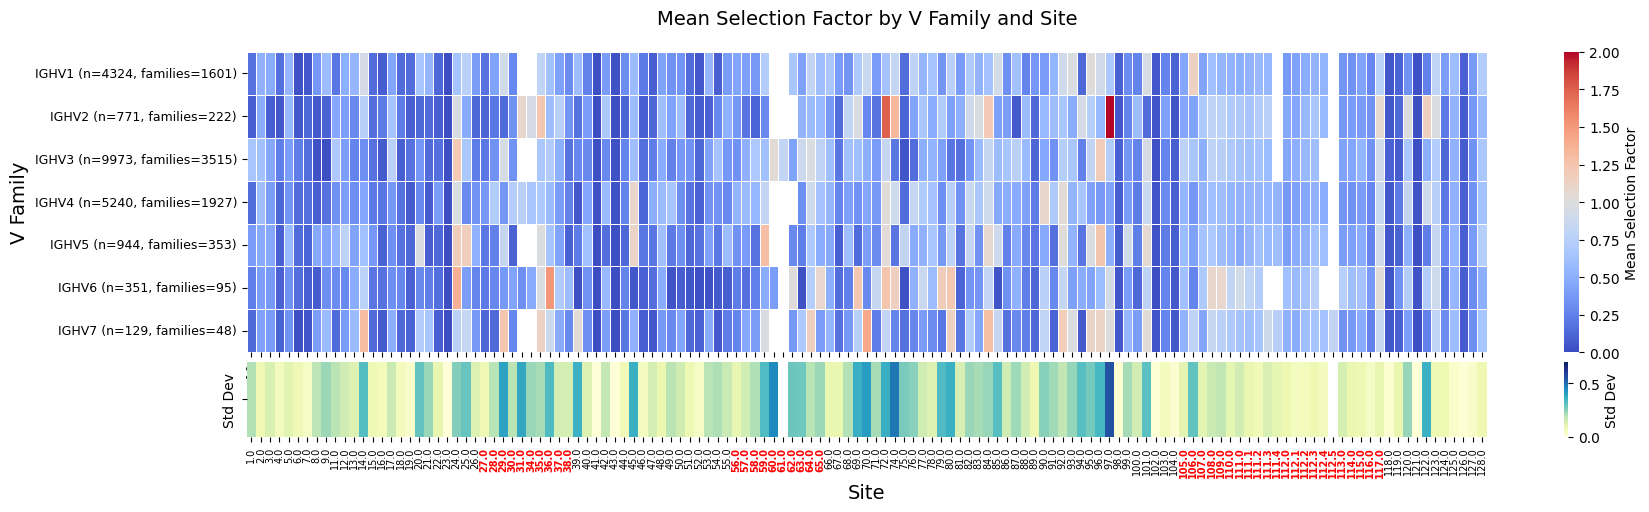

/tmp/ipykernel_4138/4239223832.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
/tmp/ipykernel_4138/4239223832.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


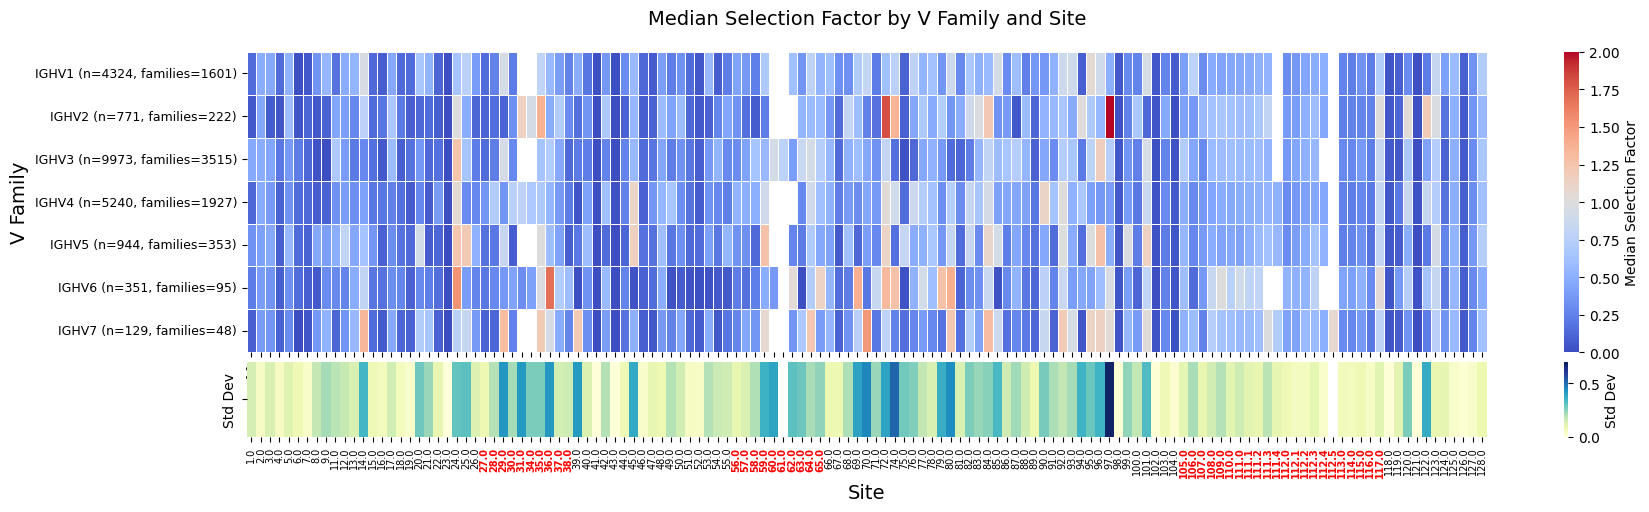

/tmp/ipykernel_4138/4239223832.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
/tmp/ipykernel_4138/4239223832.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


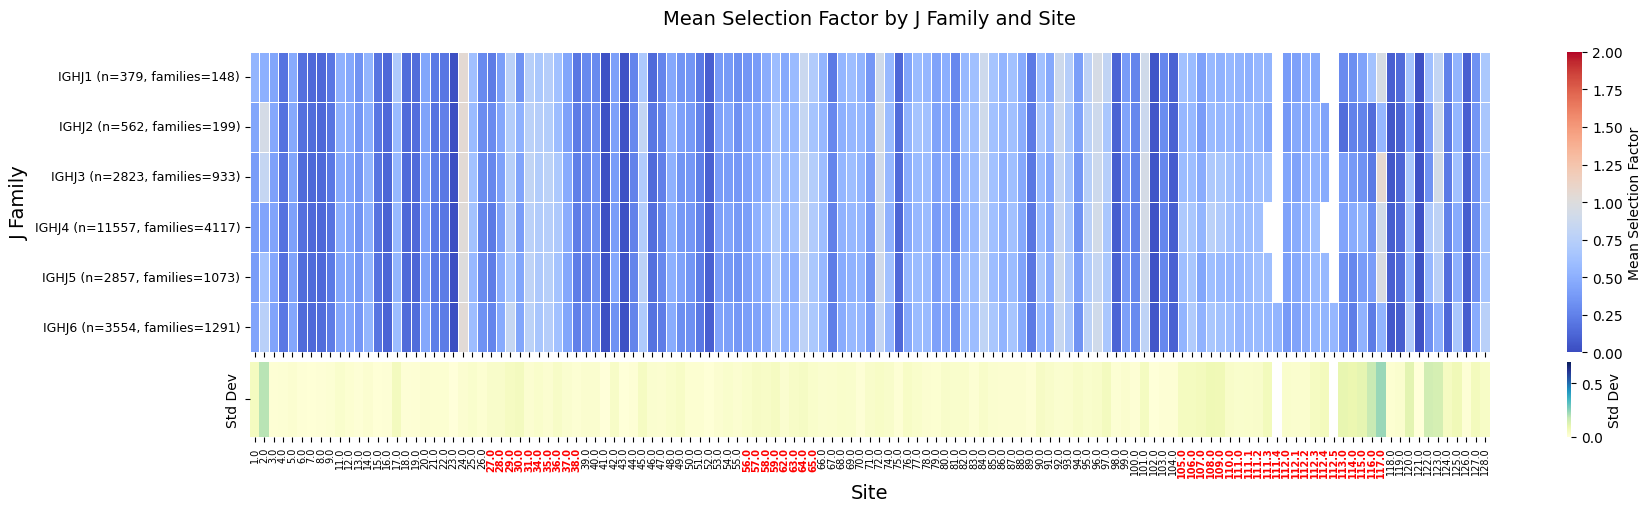

/tmp/ipykernel_4138/4239223832.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
/tmp/ipykernel_4138/4239223832.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


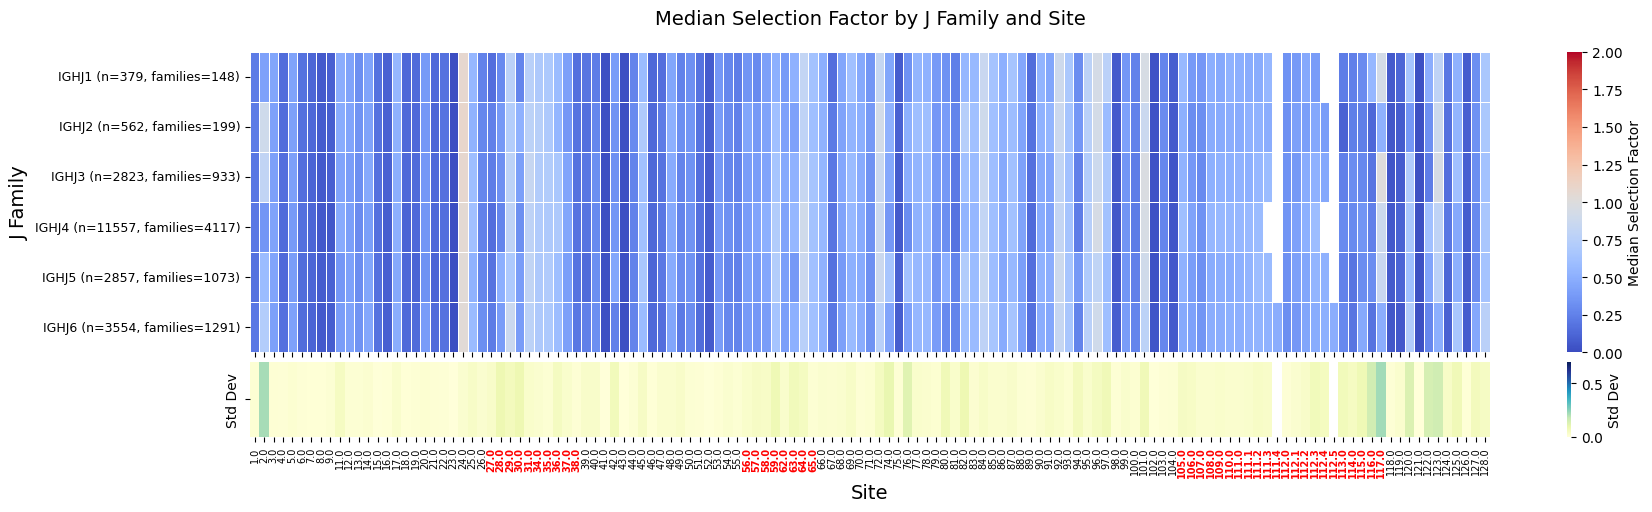

In [ ]:
# Plot mean selection factor for V families (default behavior)
fig, (ax1, ax2) = plot_selection_factor_heatmap(site_sub_probs_df)

# Plot median selection factor for V families
fig, (ax1, ax2) = plot_selection_factor_heatmap(site_sub_probs_df, statistic='median')

# Plot mutation count for V families
#fig, ax = plot_mutation_heatmap(site_sub_probs_df)

# Plot mean selection factor for J families
fig, (ax1, ax2) = plot_selection_factor_heatmap(site_sub_probs_df, family_column='j_family')

# Plot mean selection factor for J families
fig, (ax1, ax2) = plot_selection_factor_heatmap(site_sub_probs_df, family_column='j_family', statistic='median')

# Plot mutation count for V families
#fig, ax = plot_mutation_heatmap(site_sub_probs_df, family_column='j_family')


#### V families have a lot of differences between them, but J families are more similar in terms of selection factors. Some of these changes are likely due to different starting codons/amino acids

#### For every position, get the most common parent codon, filter only sequences with that codon, and then plot the selection factor heatmaps for that codon. See if still getting large differences in selection factor between families.

In [ ]:

def get_most_common_parent_aa_per_family(df, family_column='v_family', min_pct=0.05):
    # Create a dictionary to track site order from the original DataFrame
    site_order = df['site'].unique()
    
    filtered_df = pd.DataFrame()
    # Filter out positions that appear in less than min_pct of pcp_index per family
    for family in df[family_column].unique():
        family_df = df[df[family_column] == family]
        # Count the total number of unique pcp_index values for this family
        total_pcp_indices = family_df['pcp_index'].nunique()
        # For each site, count how many unique pcp_index values it appears with
        site_pcp_counts = family_df.groupby('site')['pcp_index'].nunique()
        # Calculate the percentage of pcp_index coverage for each site
        site_pcp_percentages = site_pcp_counts / total_pcp_indices
        # Keep only sites that appear in at least min_pct of the pcp_indices for this family
        sites_above_threshold = site_pcp_percentages[site_pcp_percentages >= min_pct].index
        # Filter the family dataframe to only include these sites
        filtered_family_df = family_df[family_df['site'].isin(sites_above_threshold)]
        # Add to the overall filtered dataframe
        filtered_df = pd.concat([filtered_df, filtered_family_df])
    
    # Create a list to store results
    results = []
    
    # Group by family and site
    grouped = filtered_df.groupby([family_column, 'site'])
    
    # Iterate through each group
    for (gene_family, site), group in grouped:
        # Count occurrences of parent AAs
        aa_counts = group['parent_aa'].value_counts()
        
        # Get the most common AA
        most_common_aa = aa_counts.index[0]
        
        # Calculate the percentage
        percent = (aa_counts.iloc[0] / len(group)) * 100
        
        # Append to results
        results.append({
            'gene_family': gene_family,
            'site': site,
            'parent_aa': most_common_aa,
            'parent_aa_percent': round(percent, 2)
        })
    
    # Convert to DataFrame
    result_df = pd.DataFrame(results)
    
    # Sort the result DataFrame based on the original site order
    result_df['site_order'] = result_df['site'].map({site: i for i, site in enumerate(site_order)})
    result_df = result_df.sort_values('site_order').drop('site_order', axis=1)
    
    return result_df

def get_most_common_parent_codon_per_family(df, family_column='v_family', min_pct=0.05):
    # Create a dictionary to track site order from the original DataFrame
    site_order = df['site'].unique()
    
    filtered_df = pd.DataFrame()
    # Filter out positions that appear in less than min_pct of pcp_index per family
    for family in df[family_column].unique():
        family_df = df[df[family_column] == family]
        # Count the total number of unique pcp_index values for this family
        total_pcp_indices = family_df['pcp_index'].nunique()
        # For each site, count how many unique pcp_index values it appears with
        site_pcp_counts = family_df.groupby('site')['pcp_index'].nunique()
        # Calculate the percentage of pcp_index coverage for each site
        site_pcp_percentages = site_pcp_counts / total_pcp_indices
        # Keep only sites that appear in at least min_pct of the pcp_indices for this family
        sites_above_threshold = site_pcp_percentages[site_pcp_percentages >= min_pct].index
        # Filter the family dataframe to only include these sites
        filtered_family_df = family_df[family_df['site'].isin(sites_above_threshold)]
        # Add to the overall filtered dataframe
        filtered_df = pd.concat([filtered_df, filtered_family_df])
    
    # Create a list to store results
    results = []
    
    # Group by family and site
    grouped = filtered_df.groupby([family_column, 'site'])
    
    # Iterate through each group
    for (gene_family, site), group in grouped:
        # Count occurrences of parent codons
        codon_counts = group['parent_codon'].value_counts()
        
        # Get the most common codon
        most_common_codon = codon_counts.index[0]
        
        # Calculate the percentage
        percent = (codon_counts.iloc[0] / len(group)) * 100
        
        # Append to results
        results.append({
            'gene_family': gene_family,
            'site': site,
            'parent_codon': most_common_codon,
            'parent_codon_percent': round(percent, 2)
        })
    
    # Convert to DataFrame
    result_df = pd.DataFrame(results)
    
    # Sort the result DataFrame based on the original site order
    result_df['site_order'] = result_df['site'].map({site: i for i, site in enumerate(site_order)})
    result_df = result_df.sort_values('site_order').drop('site_order', axis=1)
    
    return result_df


most_common_codon_vfam_df = get_most_common_parent_codon_per_family(site_sub_probs_df,family_column='v_family')
most_common_codon_jfam_df = get_most_common_parent_codon_per_family(site_sub_probs_df,family_column='j_family')
most_common_aa_vfam_df = get_most_common_parent_aa_per_family(site_sub_probs_df,family_column='v_family')
most_common_aa_jfam_df = get_most_common_parent_aa_per_family(site_sub_probs_df,family_column='j_family')



In [ ]:
def get_most_common_parent_codon(df, min_pct=0.05):
    # Create a dictionary to track site order from the original DataFrame
    site_order = df['site'].unique()
    
    # Count the total number of unique pcp_index values
    total_pcp_indices = df['pcp_index'].nunique()
    
    # For each site, count how many unique pcp_index values it appears with
    site_pcp_counts = df.groupby('site')['pcp_index'].nunique()
    
    # Calculate the percentage of pcp_index coverage for each site
    site_pcp_percentages = site_pcp_counts / total_pcp_indices
    
    # Keep only sites that appear in at least min_pct of the pcp_indices
    sites_above_threshold = site_pcp_percentages[site_pcp_percentages >= min_pct].index
    
    # Filter the dataframe to only include these sites
    filtered_df = df[df['site'].isin(sites_above_threshold)]
    
    # Create a list to store results
    results = []
    
    # Iterate through each site
    for site in sites_above_threshold:
        # Get data for this site
        site_data = filtered_df[filtered_df['site'] == site]
        
        # Count occurrences of parent codons
        codon_counts = site_data['parent_codon'].value_counts()
        
        # Get the most common codon
        most_common_codon = codon_counts.index[0]
        
        # Calculate the percentage
        percent = (codon_counts.iloc[0] / len(site_data)) * 100
        
        # Append to results
        results.append({
            'site': site,
            'parent_codon': most_common_codon,
            'parent_codon_percent': round(percent, 2)
        })
    
    # Convert to DataFrame
    result_df = pd.DataFrame(results)
    
    # Sort the result DataFrame based on the original site order
    result_df['site_order'] = result_df['site'].map({site: i for i, site in enumerate(site_order)})
    result_df = result_df.sort_values('site_order').drop('site_order', axis=1)
    
    return result_df


def get_most_common_parent_aa(df, min_pct=0.05):
    """
    Get the most common parent amino acid for each site in the dataframe.
    
    Args:
        df: DataFrame containing site information with 'site', 'pcp_index', and 'parent_aa' columns
        min_pct: Minimum percentage of pcp_indices a site must appear in to be included
        
    Returns:
        DataFrame with site, most common parent_aa, and percentage of sequences with that aa
    """
    # Create a dictionary to track site order from the original DataFrame
    site_order = df['site'].unique()
    
    # Count the total number of unique pcp_index values
    total_pcp_indices = df['pcp_index'].nunique()
    
    # For each site, count how many unique pcp_index values it appears with
    site_pcp_counts = df.groupby('site')['pcp_index'].nunique()
    
    # Calculate the percentage of pcp_index coverage for each site
    site_pcp_percentages = site_pcp_counts / total_pcp_indices
    
    # Keep only sites that appear in at least min_pct of the pcp_indices
    sites_above_threshold = site_pcp_percentages[site_pcp_percentages >= min_pct].index
    
    # Filter the dataframe to only include these sites
    filtered_df = df[df['site'].isin(sites_above_threshold)]
    
    # Create a list to store results
    results = []
    
    # Iterate through each site
    for site in sites_above_threshold:
        # Get data for this site
        site_data = filtered_df[filtered_df['site'] == site]
        
        # We need to get the parent_aa for each unique pcp_index (to avoid counting duplicates)
        # Group by pcp_index and take the first parent_aa (they should all be the same for a given pcp_index and site)
        unique_site_data = site_data.groupby('pcp_index')['parent_aa'].first().reset_index()
        
        # Count occurrences of parent amino acids
        aa_counts = unique_site_data['parent_aa'].value_counts()
        
        # Get the most common amino acid
        most_common_aa = aa_counts.index[0]
        
        # Calculate the percentage
        percent = (aa_counts.iloc[0] / len(unique_site_data)) * 100
        
        # Append to results
        results.append({
            'site': site,
            'parent_aa': most_common_aa,
            'parent_aa_percent': round(percent, 2)
        })
    
    # Convert to DataFrame
    result_df = pd.DataFrame(results)
    
    # Sort the result DataFrame based on the original site order
    result_df['site_order'] = result_df['site'].map({site: i for i, site in enumerate(site_order)})
    result_df = result_df.sort_values('site_order').drop('site_order', axis=1)
    
    return result_df

most_common_parent_codon = get_most_common_parent_codon(site_sub_probs_df)
most_common_parent_codon

,site,parent_codon,parent_codon_percent
0,1.0,CAG,54.31
1,2.0,GTG,73.71
2,3.0,CAG,78.72
3,4.0,CTG,79.91
4,5.0,GTG,57.22
...,...,...,...
126,124.0,GTC,98.06
127,125.0,ACC,88.70
128,126.0,GTC,98.48
129,127.0,TCC,82.76


/tmp/ipykernel_4138/4239223832.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
/tmp/ipykernel_4138/4239223832.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


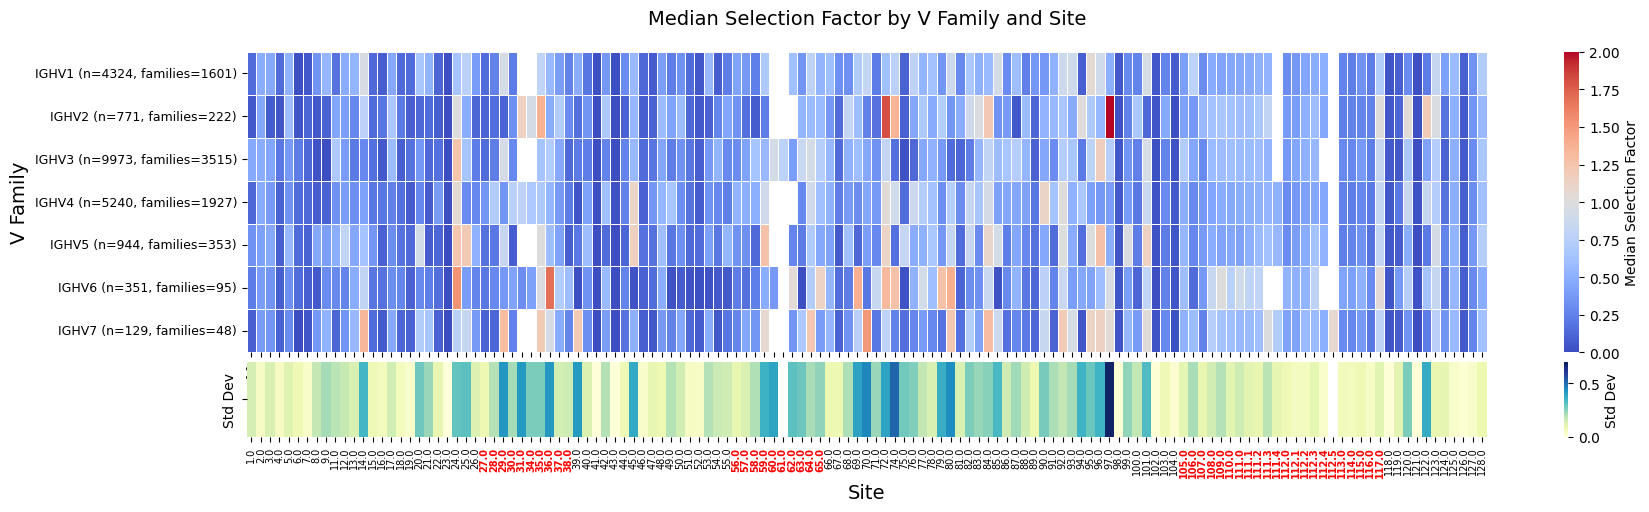

In [ ]:
fig, (ax1, ax2) = plot_selection_factor_heatmap(site_sub_probs_df, statistic='median')


/tmp/ipykernel_4138/4239223832.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
/tmp/ipykernel_4138/4239223832.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


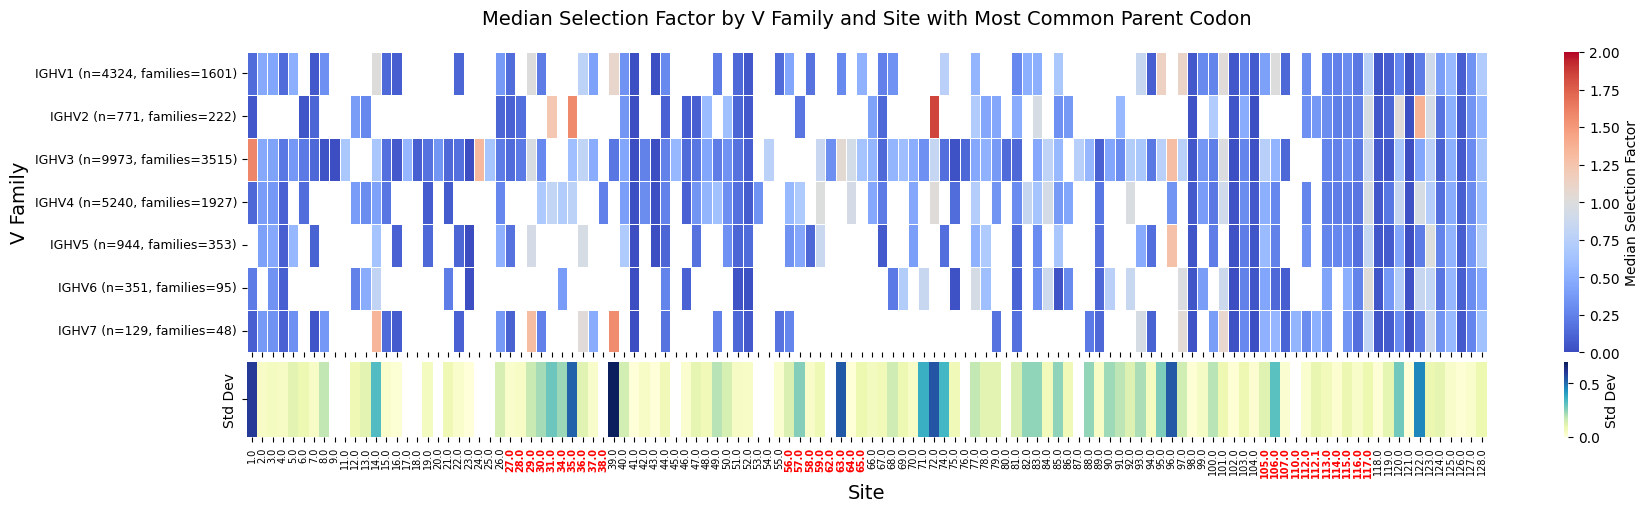

(<Figure size 2000x500 with 4 Axes>,
 (<Axes: title={'center': 'Median Selection Factor by V Family and Site with Most Common Parent Codon'}, ylabel='V Family'>,
  <Axes: xlabel='Site'>))

In [ ]:
plot_selection_factor_heatmap(pd.merge(site_sub_probs_df, get_most_common_parent_codon(site_sub_probs_df), on=['site', 'parent_codon'], how='inner'), statistic='median', family_column='v_family', title="Median Selection Factor by V Family and Site with Most Common Parent Codon")


/tmp/ipykernel_4138/4239223832.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
/tmp/ipykernel_4138/4239223832.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


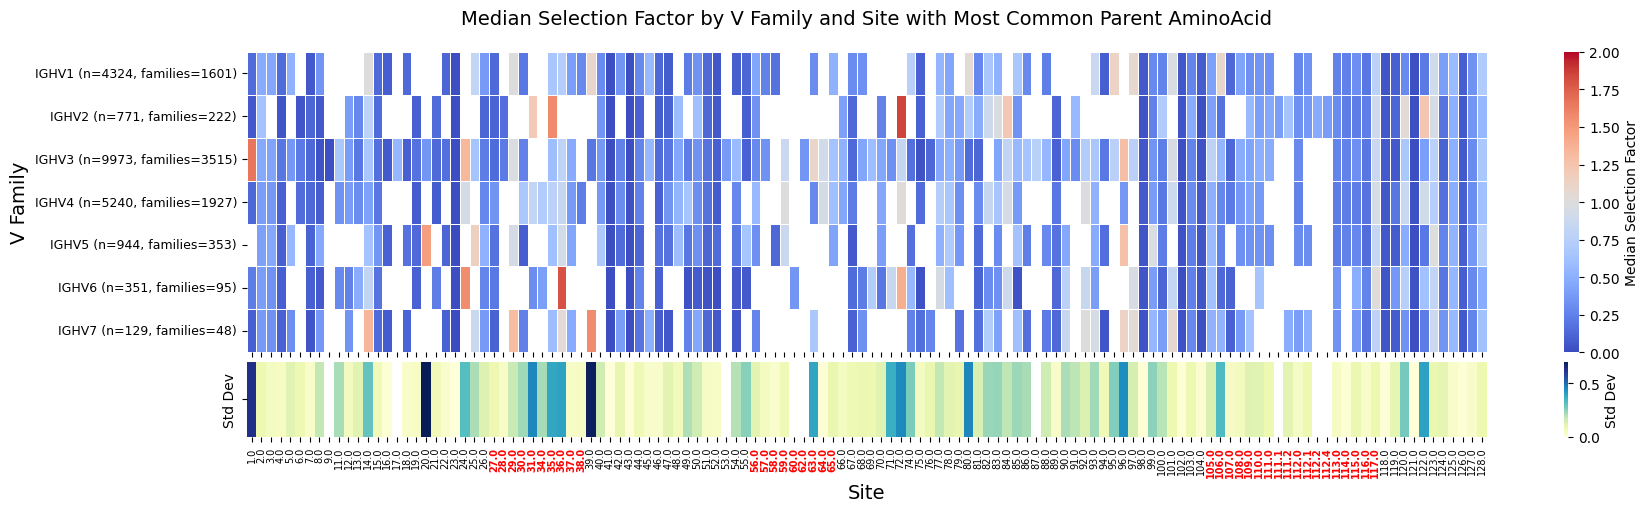

(<Figure size 2000x500 with 4 Axes>,
 (<Axes: title={'center': 'Median Selection Factor by V Family and Site with Most Common Parent AminoAcid'}, ylabel='V Family'>,
  <Axes: xlabel='Site'>))

In [ ]:
plot_selection_factor_heatmap(pd.merge(site_sub_probs_df, get_most_common_parent_aa(site_sub_probs_df), on=['site', 'parent_aa'], how='inner'), statistic='median', family_column='v_family', title="Median Selection Factor by V Family and Site with Most Common Parent AminoAcid")


/tmp/ipykernel_4138/4239223832.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
/tmp/ipykernel_4138/4239223832.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


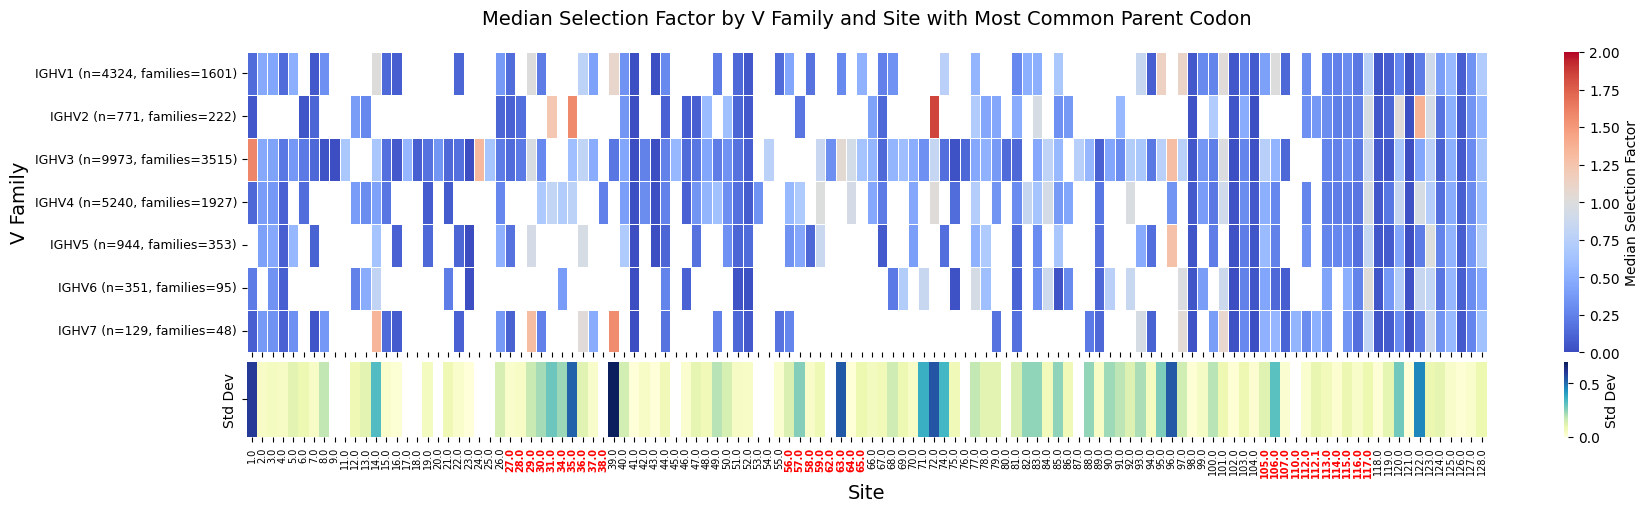

/tmp/ipykernel_4138/4239223832.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
/tmp/ipykernel_4138/4239223832.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


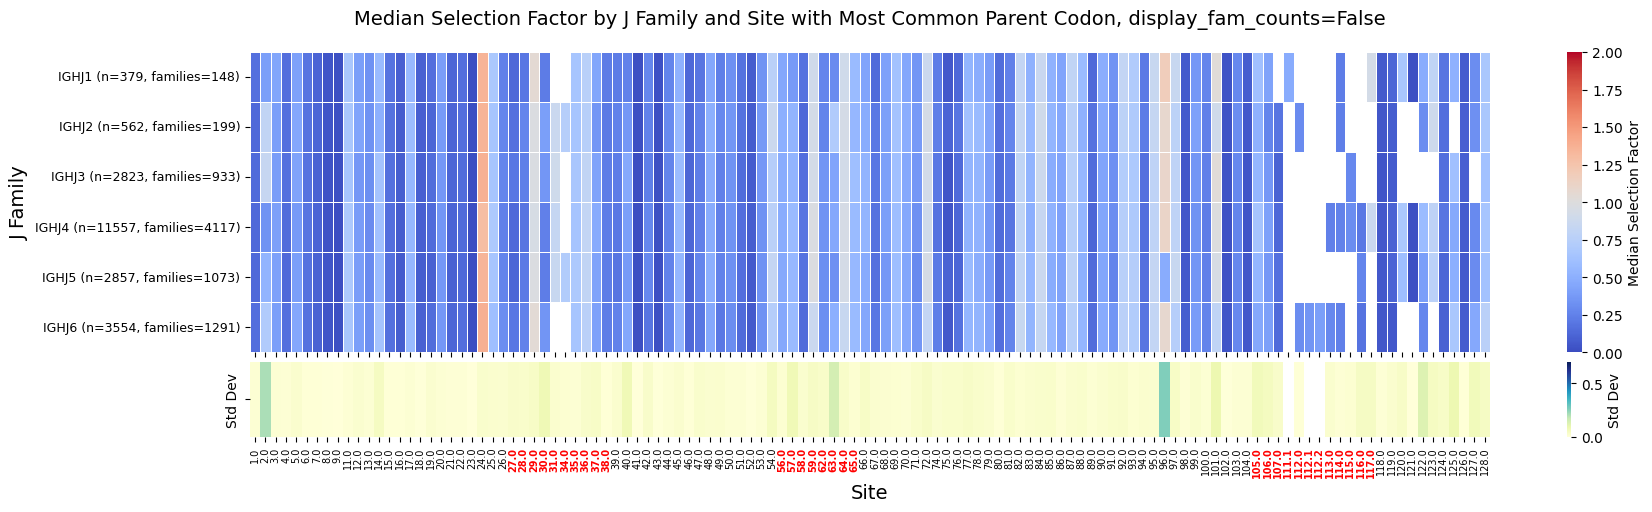

(<Figure size 2000x500 with 4 Axes>,
 (<Axes: title={'center': 'Median Selection Factor by J Family and Site with Most Common Parent Codon, display_fam_counts=False'}, ylabel='J Family'>,
  <Axes: xlabel='Site'>))

In [ ]:
# filter for most common parent codon amongst all seqs and plot seleciton heatmaps

plot_selection_factor_heatmap(pd.merge(site_sub_probs_df, get_most_common_parent_codon(site_sub_probs_df), on=['site', 'parent_codon'], how='inner'), statistic='median', family_column='v_family', title="Median Selection Factor by V Family and Site with Most Common Parent Codon")
plot_selection_factor_heatmap(pd.merge(site_sub_probs_df, get_most_common_parent_codon(site_sub_probs_df), on=['site', 'parent_codon'], how='inner'), statistic='median', family_column='j_family', title="Median Selection Factor by J Family and Site with Most Common Parent Codon"", display_fam_counts=False")

/tmp/ipykernel_4138/4239223832.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
/tmp/ipykernel_4138/4239223832.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


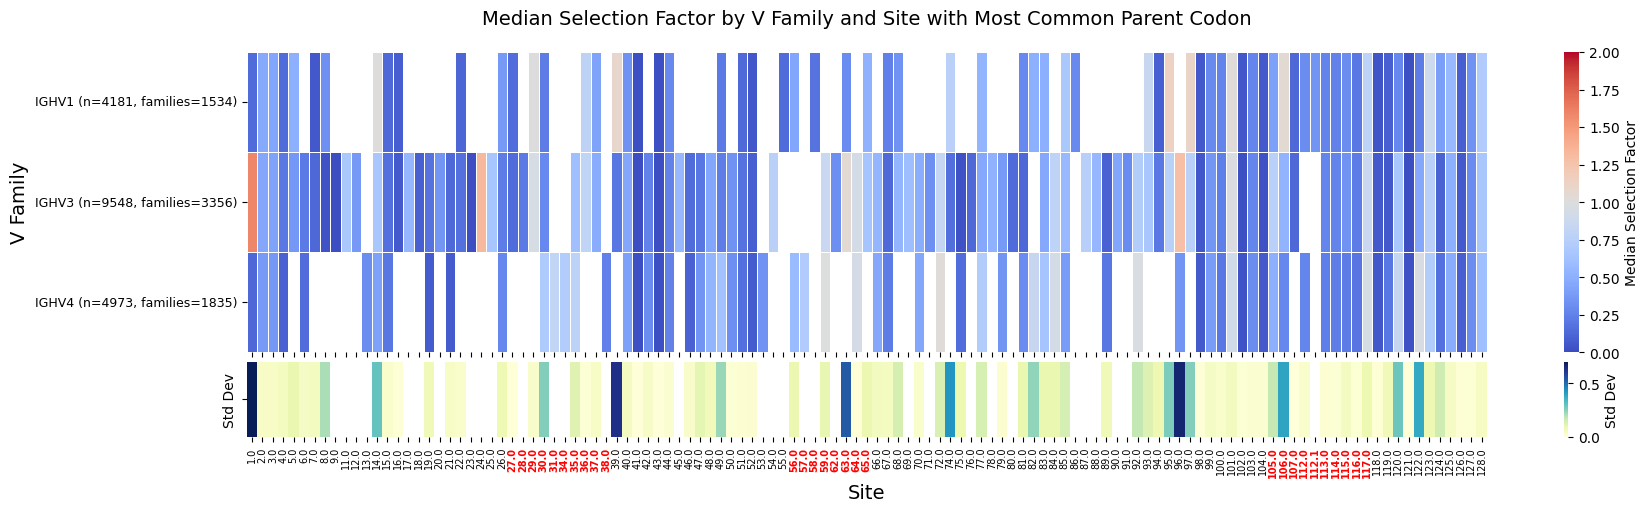

/tmp/ipykernel_4138/4239223832.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
/tmp/ipykernel_4138/4239223832.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


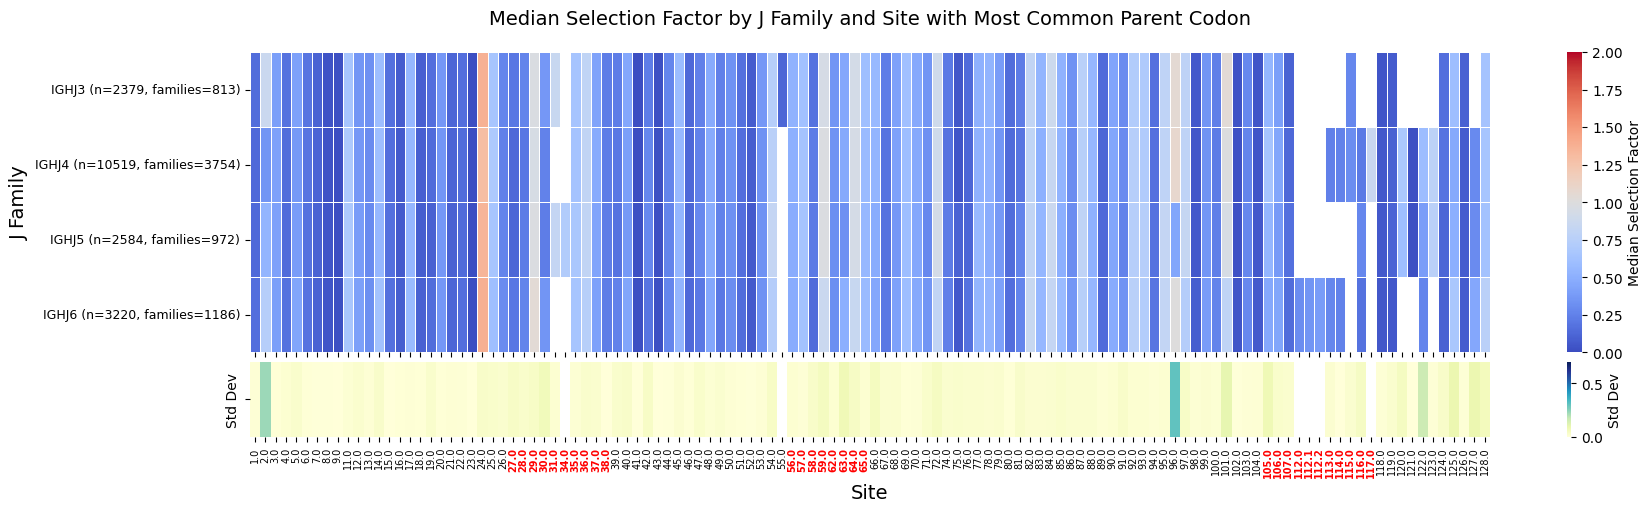

(<Figure size 2000x500 with 4 Axes>,
 (<Axes: title={'center': 'Median Selection Factor by J Family and Site with Most Common Parent Codon'}, ylabel='J Family'>,
  <Axes: xlabel='Site'>))

In [ ]:
## because we are already filtering for the most common parent codon, we want to make sure we're looking at something that the model has enough knoledge about. So we will look only at the most common gene families
#(at least according to this data)


common_v_fams = ['IGHV1', 'IGHV3', 'IGHV4']
common_j_fams = ['IGHJ4', 'IGHJ6', 'IGHJ3', 'IGHJ5']

common_site_sub_probs_df = site_sub_probs_df[(site_sub_probs_df.v_family.isin(common_v_fams)) & (site_sub_probs_df.j_family.isin(common_j_fams))]

plot_selection_factor_heatmap(pd.merge(common_site_sub_probs_df, get_most_common_parent_codon(common_site_sub_probs_df), on=['site', 'parent_codon'], how='inner'), statistic='median', family_column='v_family', title="Median Selection Factor by V Family and Site with Most Common Parent Codon")
plot_selection_factor_heatmap(pd.merge(common_site_sub_probs_df, get_most_common_parent_codon(common_site_sub_probs_df), on=['site', 'parent_codon'], how='inner'), statistic='median', family_column='j_family', title="Median Selection Factor by J Family and Site with Most Common Parent Codon")

In [ ]:
### examine case of positions 8-9 glycine epistasis in IGHV3

In [ ]:
most_common_aa_vfam_df[most_common_aa_vfam_df.site.isin([9.0])]

,gene_family,site,parent_aa,parent_aa_percent
524,IGHV5,9.0,A,93.11
653,IGHV6,9.0,P,99.15
137,IGHV2,9.0,P,100.00
783,IGHV7,9.0,S,100.00
265,IGHV3,9.0,G,99.90
8,IGHV1,9.0,A,87.70
394,IGHV4,9.0,P,85.25


/tmp/ipykernel_4138/3781830066.py:408: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
/tmp/ipykernel_4138/3781830066.py:408: DeprecationWarning: DataFrameGroupB

(<Figure size 2000x350 with 2 Axes>,
 <Axes: title={'center': 'Clonal families in which mutation occured per site by J Family, filtered on most common parent codon'}, xlabel='Site', ylabel='J Family'>)

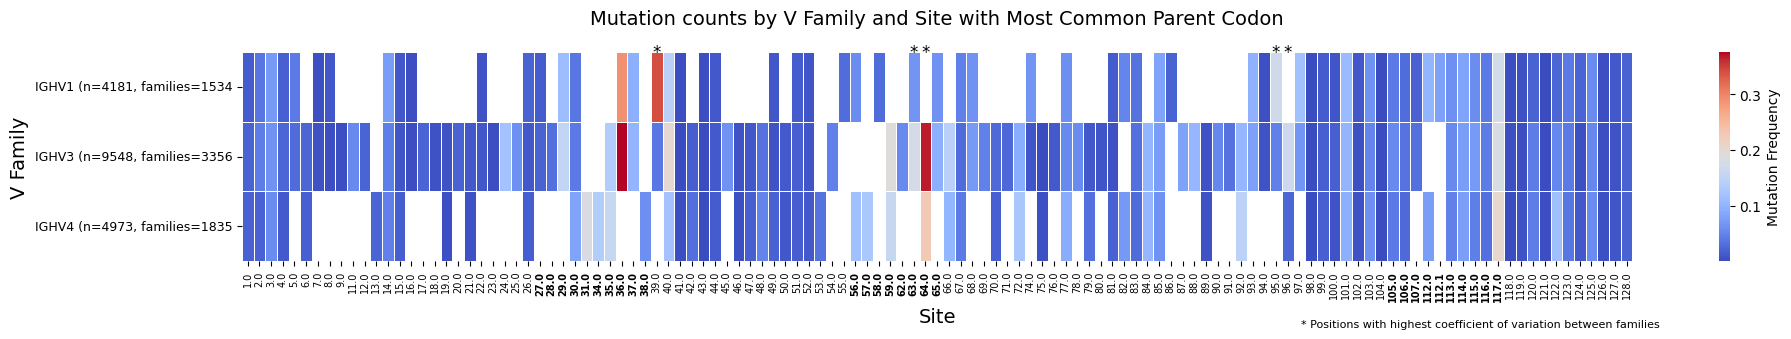

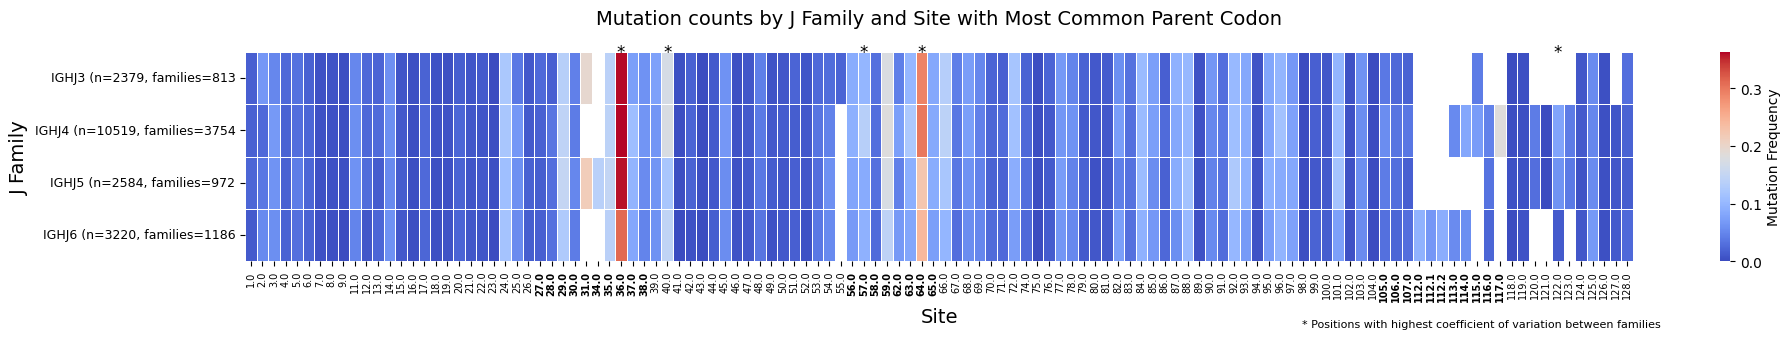

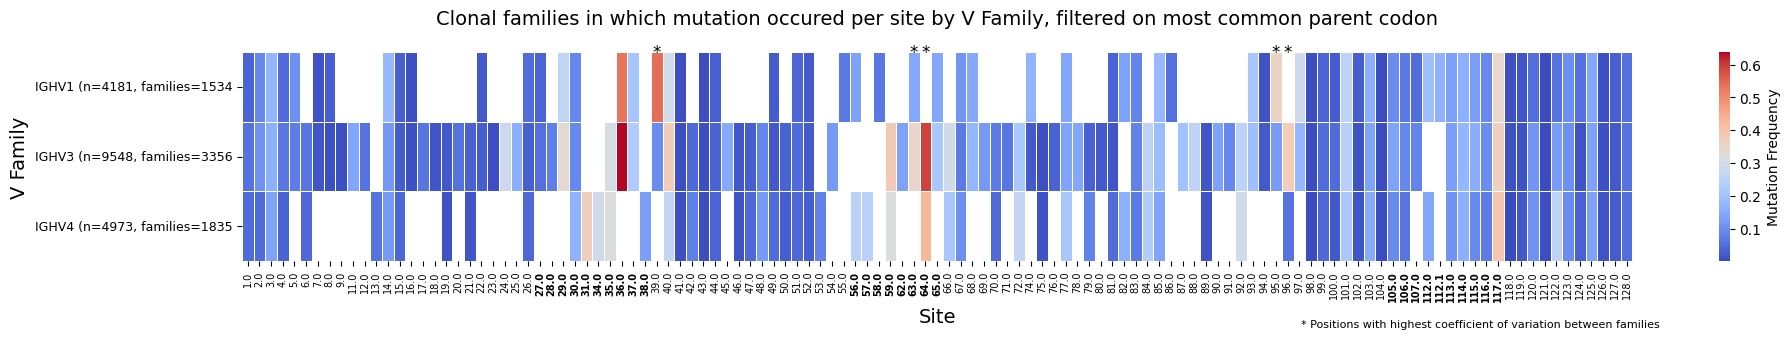

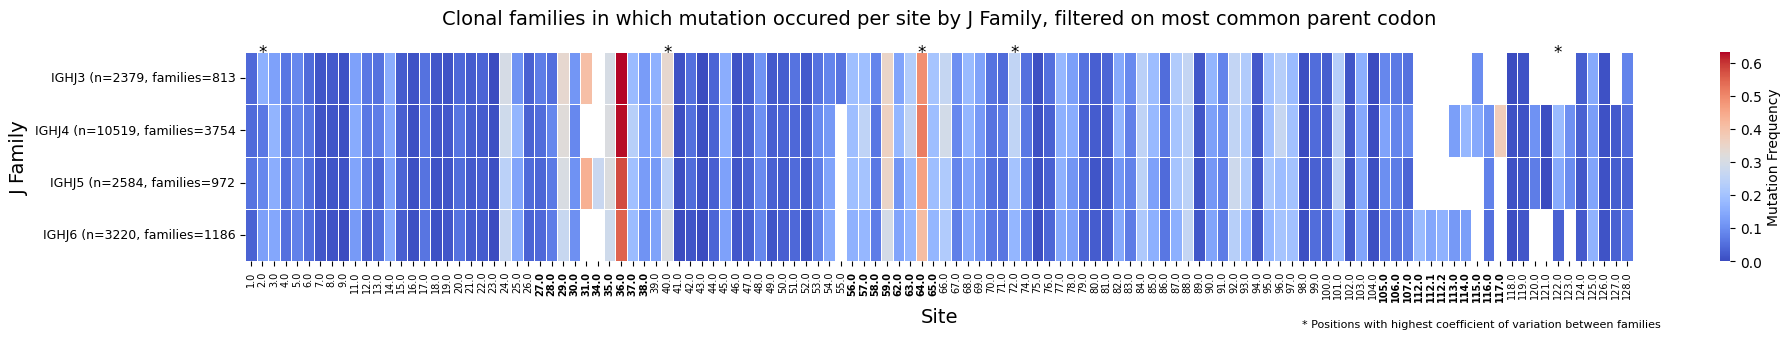

In [ ]:
### looks at the mutation counts of same analysis
## because we are already filtering for the most common parent codon, we want to make sure we're looking at something that the model has enough knoledge about. So we will look only at the most common gene families
#(at least according to this data)

plot_mutation_heatmap(pd.merge(common_site_sub_probs_df, get_most_common_parent_codon(common_site_sub_probs_df), on=['site', 'parent_codon'], how='inner'), family_column='v_family', title="Mutation counts by V Family and Site with Most Common Parent Codon")
plot_mutation_heatmap(pd.merge(common_site_sub_probs_df, get_most_common_parent_codon(common_site_sub_probs_df), on=['site', 'parent_codon'], how='inner'), family_column='j_family', title="Mutation counts by J Family and Site with Most Common Parent Codon")

plot_mutation_in_clonal_family_heatmap(pd.merge(common_site_sub_probs_df, get_most_common_parent_codon(common_site_sub_probs_df), on=['site', 'parent_codon'], how='inner'), family_column='v_family', title="Clonal families in which mutation occured per site by V Family, filtered on most common parent codon")
plot_mutation_in_clonal_family_heatmap(pd.merge(common_site_sub_probs_df, get_most_common_parent_codon(common_site_sub_probs_df), on=['site', 'parent_codon'], how='inner'), family_column='j_family', title="Clonal families in which mutation occured per site by J Family, filtered on most common parent codon")




In [ ]:
most_common_codon_vfam_df[most_common_codon_vfam_df.gene_family.isin(['IGHV3', 'IGHV4', 'IGHV1'])]

,gene_family,site,parent_codon,parent_codon_percent
0,IGHV1,1.0,CAG,93.15
257,IGHV3,1.0,GAG,73.00
386,IGHV4,1.0,CAG,94.52
258,IGHV3,2.0,GTG,90.98
387,IGHV4,2.0,GTG,69.27
...,...,...,...,...
384,IGHV3,127.0,TCC,84.73
514,IGHV4,127.0,TCC,84.94
515,IGHV4,128.0,TCA,93.32
385,IGHV3,128.0,TCA,94.28


/tmp/ipykernel_4138/2626473488.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_selection.set_xticklabels(family_selection['site'], rotation=90)
/tmp/ipykernel_4138/2626473488.py:125: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_neutral.set_xticklabels(family_selection['site'], rotation=90)
/tmp/ipykernel_4138/2626473488.py:140: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_raw_mutation.set_xticklabels(family_raw_mutation['site'], rotation=90)
/tmp/ipykernel_4138/2626473488.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_mutation_per_clonal.set_xticklabels(family_mutation_per_clonal['site'], rotation=90)
/tmp/ipykernel_4138/26264734

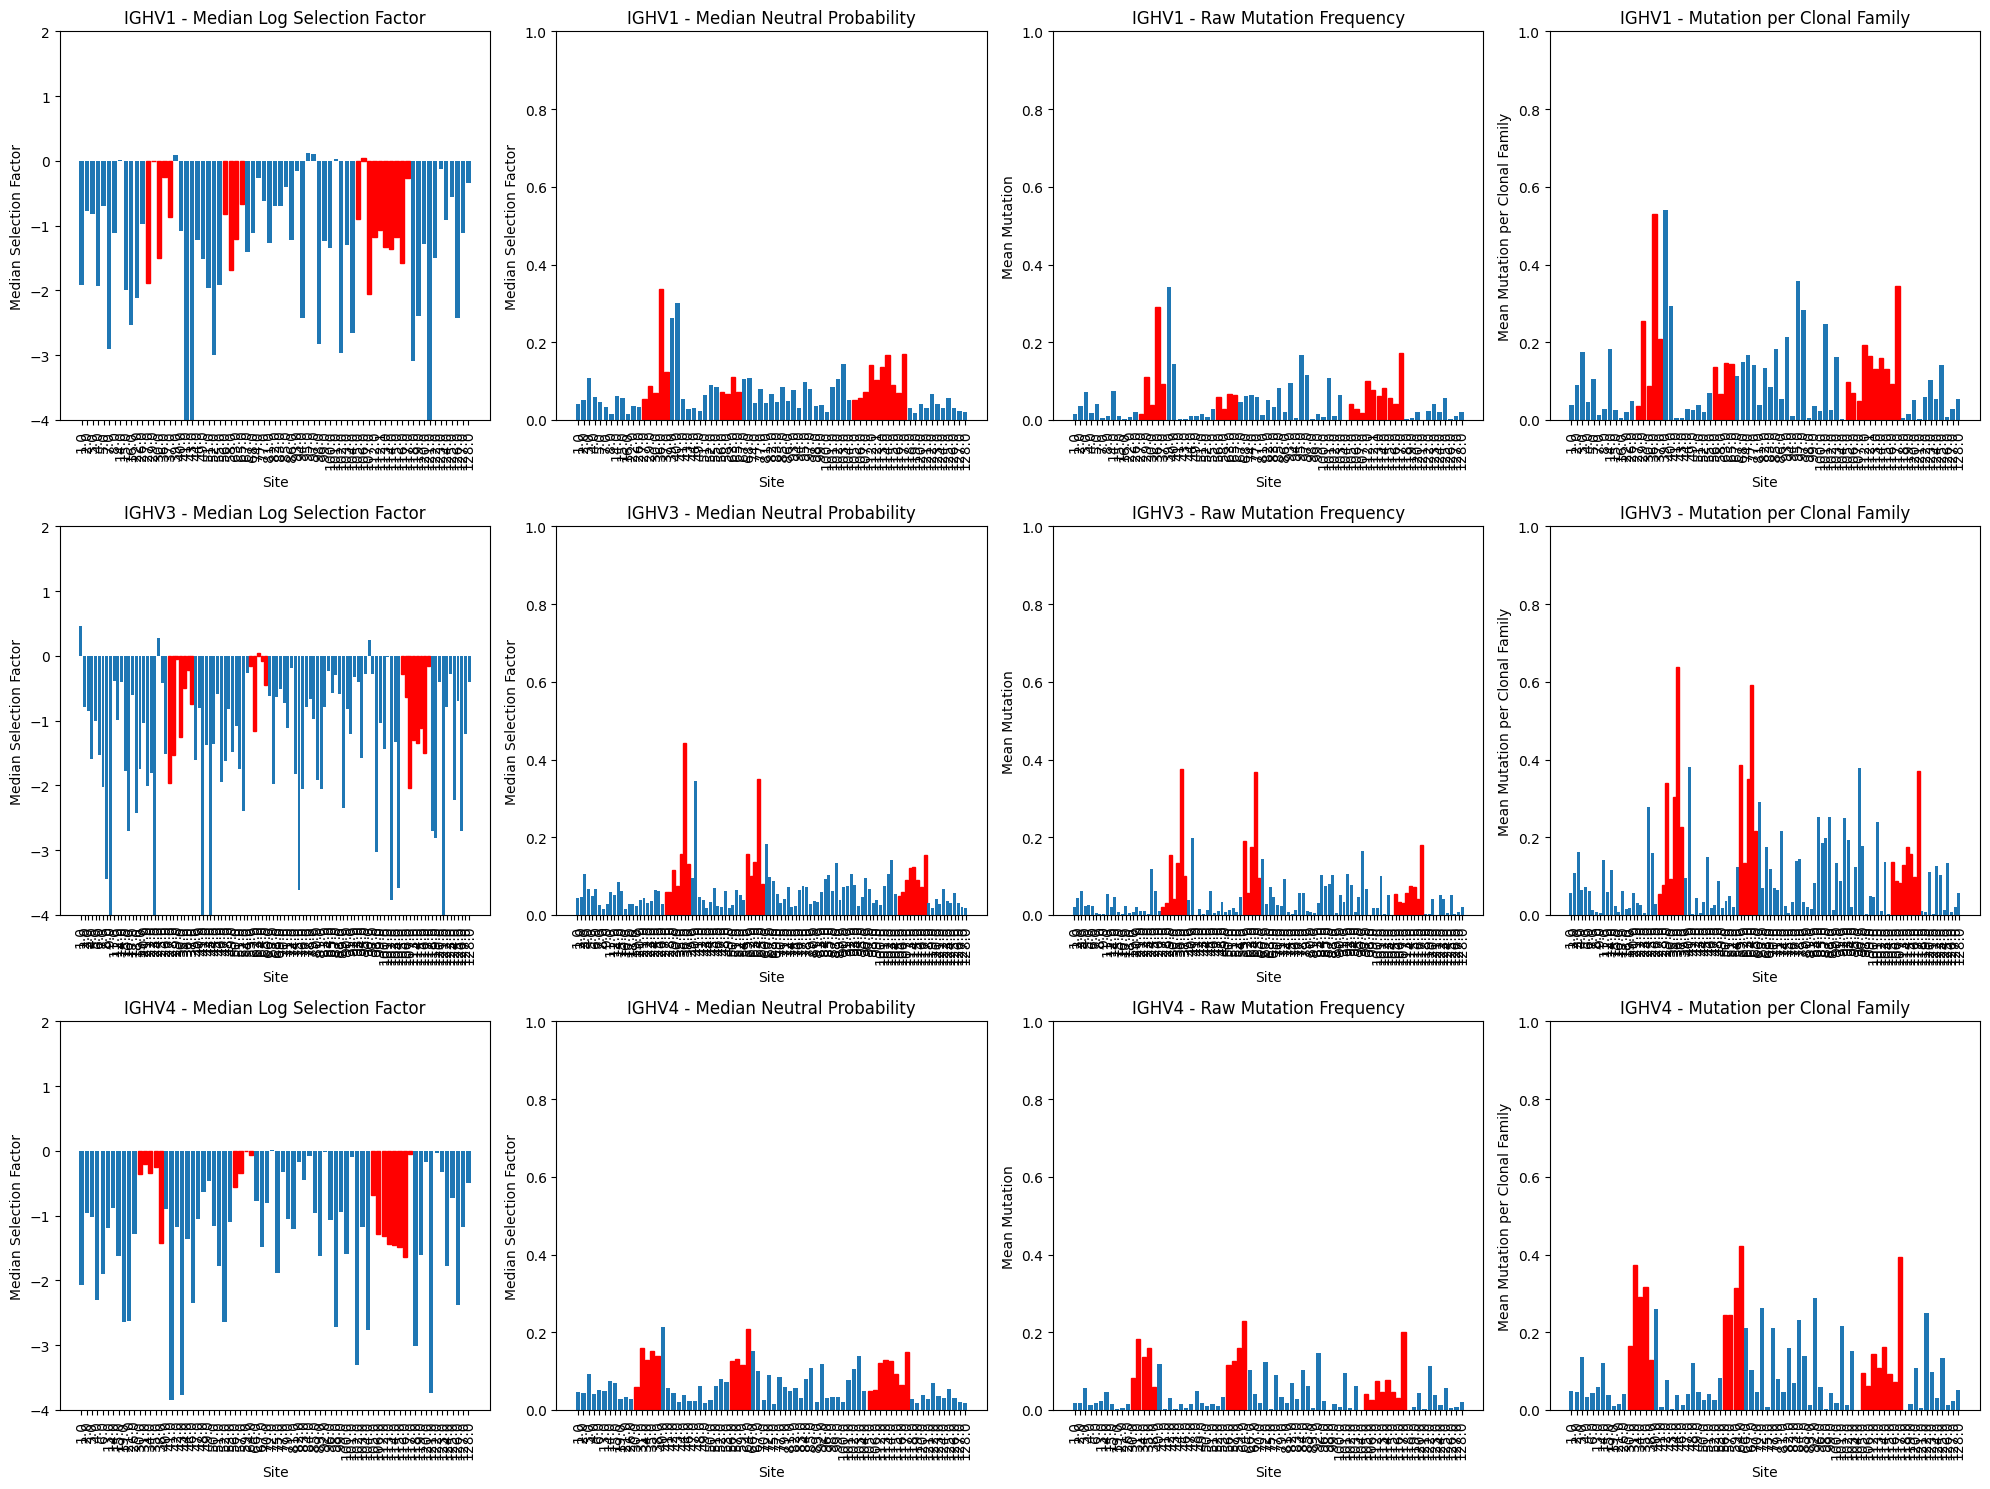

In [ ]:
def plot_detailed_selection_mutation_comparison(data, family_column='v_family', 
                                      figsize=(20, 15), min_pct=0.1):
    """
    Creates vertically stacked barplots comparing:
    1. Median selection factor
    2. Raw mutation frequency 
    3. Mutation frequency per clonal family
    for each site across different immunoglobulin gene families.
    
    Parameters:
    -----------
    data : pandas.DataFrame
        The dataframe containing selection factor and mutation data
    family_column : str, optional
        Column to use for family grouping ('v_family' or 'j_family'), default: 'v_family'
    figsize : tuple, optional
        Figure size as (width, height), default: (20, 15)
    min_pct : float, optional
        Minimum percentage of pcp_index per family for a position to be included, default: 0.1
        
    Returns:
    --------
    tuple
        (fig, axes) - The figure and axis objects
    """
    # Input validation
    if family_column not in ['v_family', 'j_family']:
        raise ValueError("family_column must be either 'v_family' or 'j_family'")
    
    # Make a copy of the dataframe to avoid modifying the original
    df = data.copy()
    
    filtered_df = pd.DataFrame()
    # Filter out positions that appear in less than min_pct of pcp_index per family
    for family in df[family_column].unique():
        family_df = df[df[family_column] == family]
        # Count the total number of unique pcp_index values for this family
        total_pcp_indices = family_df['pcp_index'].nunique()
        # For each site, count how many unique pcp_index values it appears with
        site_pcp_counts = family_df.groupby('site')['pcp_index'].nunique()
        # Calculate the percentage of pcp_index coverage for each site
        site_pcp_percentages = site_pcp_counts / total_pcp_indices
        # Keep only sites that appear in at least min_pct of the pcp_indices for this family
        sites_above_threshold = site_pcp_percentages[site_pcp_percentages >= min_pct].index
        # Filter the family dataframe to only include these sites
        filtered_family_df = family_df[family_df['site'].isin(sites_above_threshold)]
        # Add to the overall filtered dataframe
        filtered_df = pd.concat([filtered_df, filtered_family_df])

    # Calculate median selection factor for each family and site
    filtered_df['log_selection_factor'] = filtered_df['selection_factor'].apply(lambda x: np.log(x + 1e-10))  # Log normalization
    selection_data = filtered_df.groupby([family_column, 'site'])['log_selection_factor'].median().reset_index()
    
    
    # calculate median neutral probability for each family and site
    neutral_prob_data = filtered_df.groupby([family_column, 'site'])['neutral_prob'].median().reset_index()

    # Calculate raw mutation frequency (mean mutation across all instances)
    raw_mutation_data = filtered_df.groupby([family_column, 'site'])['mutation'].mean().reset_index()
    
    # Calculate mutation frequency per clonal family
    mutation_per_clonal_family_data = (
        filtered_df.groupby([family_column, 'sample_id', 'family', 'site'])
        .mutation.max()
        .reset_index()
        .groupby([family_column, 'site'])
        .mutation.mean()
        .reset_index()
    )

    # Determine CDR sites
    cdr_sites = df[df['is_cdr'] == True]['site'].unique() if 'is_cdr' in df.columns else []

    # Create a figure with subplots for each family
    unique_families = sorted(selection_data[family_column].unique())
    fig, axes = plt.subplots(len(unique_families), 4, figsize=figsize)
    
    # Ensure axes is 2D even if there's only one family
    if len(unique_families) == 1:
        axes = axes.reshape(1, -1)
    
    # Iterate through families
    for i, family in enumerate(unique_families):
        # Filter data for this family
        family_selection = selection_data[selection_data[family_column] == family]
        family_neutral = neutral_prob_data[neutral_prob_data[family_column] == family]
        family_raw_mutation = raw_mutation_data[raw_mutation_data[family_column] == family]
        family_mutation_per_clonal = mutation_per_clonal_family_data[mutation_per_clonal_family_data[family_column] == family]
        
        # Prepare axes
        ax_selection = axes[i, 0]
        ax_neutral = axes[i, 1]
        ax_raw_mutation = axes[i, 2]
        ax_mutation_per_clonal = axes[i, 3]
        
        # limit axes
        ax_selection.set_ylim(-4, 2)  # Adjust as needed   
        ax_neutral.set_ylim(0, 1)  # Adjust as needed
        ax_raw_mutation.set_ylim(0, 1)
        ax_mutation_per_clonal.set_ylim(0, 1)  # Adjust as needed

        # Plot selection factor
        selection_bars = ax_selection.bar(
            family_selection['site'].astype(str), 
            family_selection['log_selection_factor']
        )
        ax_selection.set_title(f'{family} - Median Log Selection Factor')
        ax_selection.set_xlabel('Site')
        ax_selection.set_ylabel('Median Selection Factor')
        ax_selection.set_xticklabels(family_selection['site'], rotation=90)
        
        # Color CDR sites red
        for j, site in enumerate(family_selection['site'].astype(str)):
            if site in map(str, cdr_sites):
                selection_bars[j].set_color('red')

        # Plot neutral probability
        neutral_bars = ax_neutral.bar(
            family_neutral['site'].astype(str), 
            family_neutral['neutral_prob']
        )
        ax_neutral.set_title(f'{family} - Median Neutral Probability')
        ax_neutral.set_xlabel('Site')
        ax_neutral.set_ylabel('Median Selection Factor')
        ax_neutral.set_xticklabels(family_selection['site'], rotation=90)
        
        # Color CDR sites red
        for j, site in enumerate(family_neutral['site'].astype(str)):
            if site in map(str, cdr_sites):
                neutral_bars[j].set_color('red')
        
        # Plot raw mutation frequency
        raw_mutation_bars = ax_raw_mutation.bar(
            family_raw_mutation['site'].astype(str), 
            family_raw_mutation['mutation']
        )
        ax_raw_mutation.set_title(f'{family} - Raw Mutation Frequency')
        ax_raw_mutation.set_xlabel('Site')
        ax_raw_mutation.set_ylabel('Mean Mutation')
        ax_raw_mutation.set_xticklabels(family_raw_mutation['site'], rotation=90)
        
        # Color CDR sites red
        for j, site in enumerate(family_raw_mutation['site'].astype(str)):
            if site in map(str, cdr_sites):
                raw_mutation_bars[j].set_color('red')
        
        # Plot mutation frequency per clonal family
        mutation_per_clonal_bars = ax_mutation_per_clonal.bar(
            family_mutation_per_clonal['site'].astype(str), 
            family_mutation_per_clonal['mutation']
        )
        ax_mutation_per_clonal.set_title(f'{family} - Mutation per Clonal Family')
        ax_mutation_per_clonal.set_xlabel('Site')
        ax_mutation_per_clonal.set_ylabel('Mean Mutation per Clonal Family')
        ax_mutation_per_clonal.set_xticklabels(family_mutation_per_clonal['site'], rotation=90)
        
        # Color CDR sites red
        for j, site in enumerate(family_mutation_per_clonal['site'].astype(str)):
            if site in map(str, cdr_sites):
                mutation_per_clonal_bars[j].set_color('red')
    
    # Adjust layout
    plt.tight_layout()
    
    return fig, axes

fig, axes = plot_detailed_selection_mutation_comparison(pd.merge(common_site_sub_probs_df, get_most_common_parent_codon(common_site_sub_probs_df), on=['site', 'parent_codon'], how='inner'), family_column='v_family')  # For V families


In [ ]:
site_sub_probs_df['neutral_prob'] * site_sub_probs_df['selection_factor']
#neutral_prob

0          0.009315
1          0.002802
2          0.001946
3          0.011869
4          0.002350
             ...   
2646366    0.001391
2646367    0.002128
2646368    0.002094
2646369    0.002271
2646370    0.002009
Length: 2646371, dtype: float64

In [ ]:
site_sub_probs_df['neutral_prob'] * site_sub_probs_df['selection_factor']


0          0.009315
1          0.002802
2          0.001946
3          0.011869
4          0.002350
             ...   
2646366    0.001391
2646367    0.002128
2646368    0.002094
2646369    0.002271
2646370    0.002009
Length: 2646371, dtype: float64

### To see effect of J gene on V gene selection factors, examine changes in V gene for different J genes, while keeping the V gene constant (and vice versa)

In [ ]:
pd.merge(site_sub_probs_df, get_most_common_parent_codon(site_sub_probs_df), on=['site', 'parent_codon'], how='inner').groupby(['site', 'parent_codon']).size()

site   parent_codon
1.0    CAG             11802
2.0    GTG             16018
3.0    CAG             17108
4.0    CTG             17367
5.0    GTG             12436
                       ...  
124.0  GTC             21311
125.0  ACC             19277
126.0  GTC             21402
127.0  TCC             17986
128.0  TCA             20298
Length: 131, dtype: int64

/tmp/ipykernel_4138/4239223832.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
/tmp/ipykernel_4138/4239223832.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


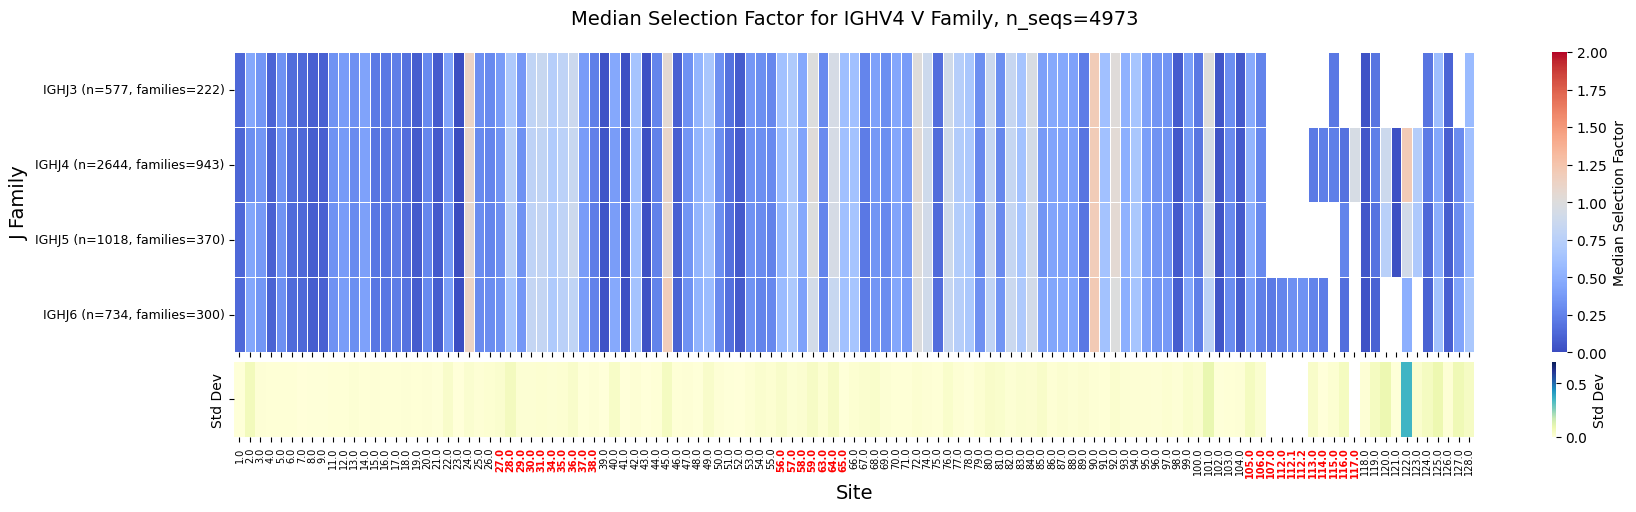

/tmp/ipykernel_4138/4239223832.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
/tmp/ipykernel_4138/4239223832.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


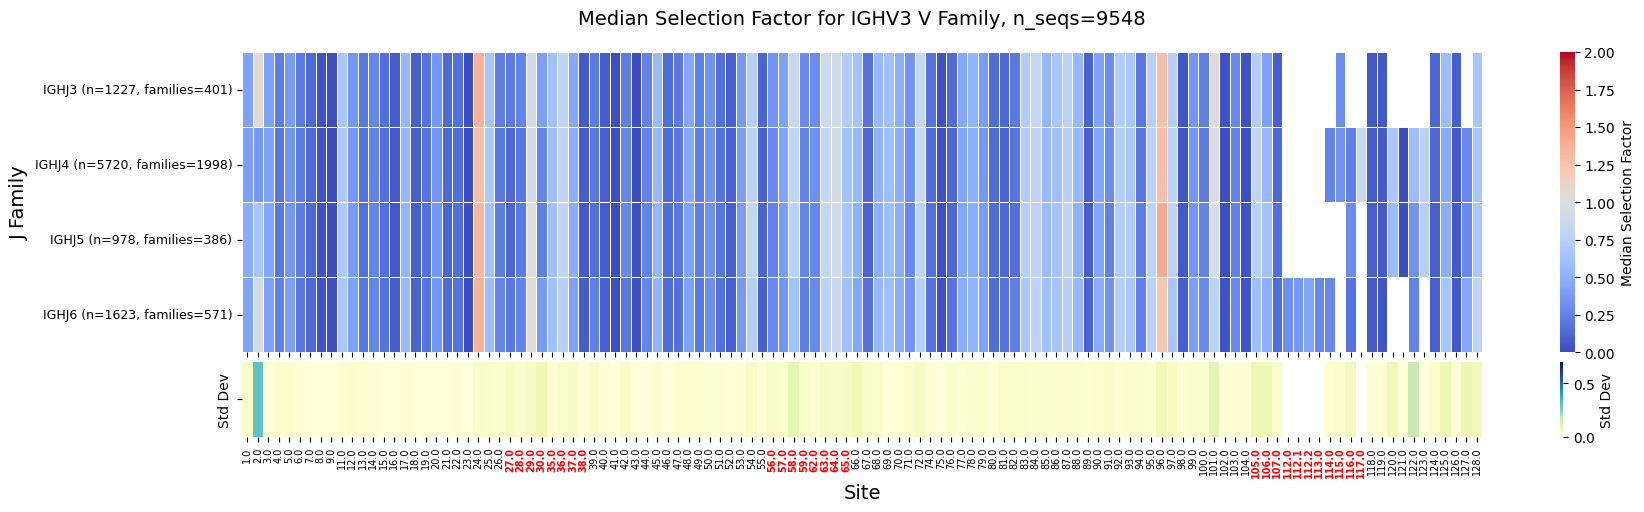

/tmp/ipykernel_4138/4239223832.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
/tmp/ipykernel_4138/4239223832.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


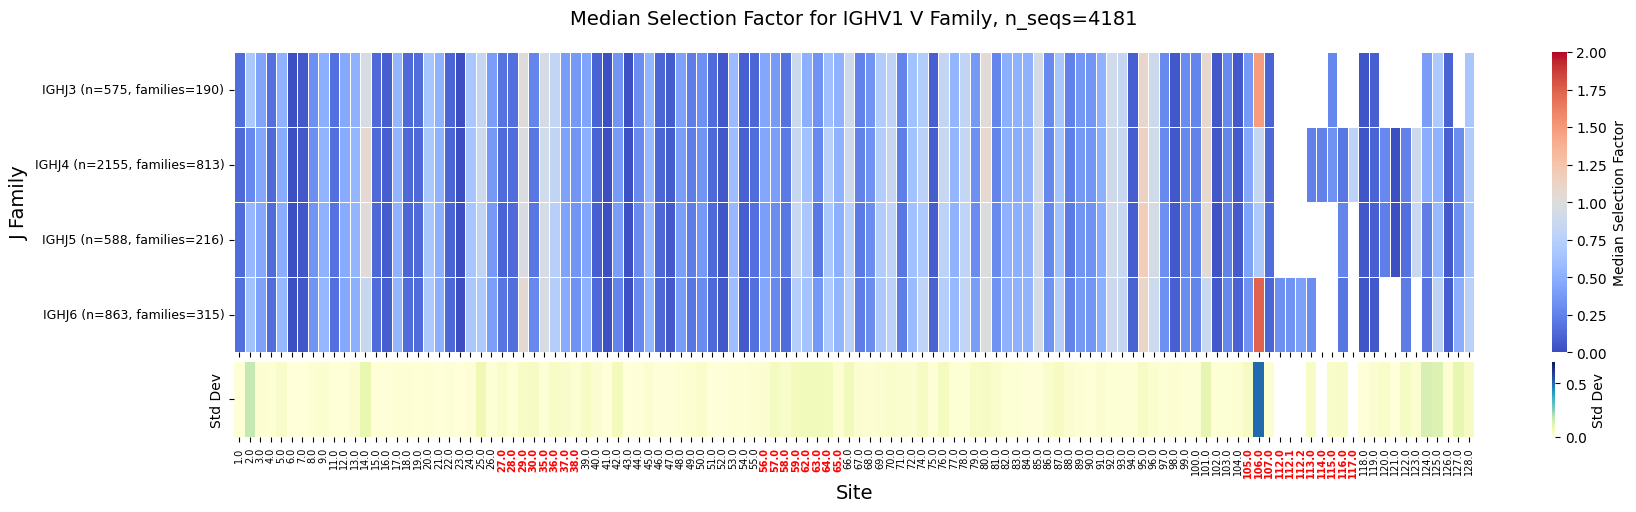

In [ ]:
# Plot mean selection factor for J families, per constant V family. Also filter for most common codon
for v_family in common_site_sub_probs_df['v_family'].unique():
    cur_df = common_site_sub_probs_df[common_site_sub_probs_df.v_family == v_family]
    fig, (ax1, ax2) = plot_selection_factor_heatmap(pd.merge(cur_df, get_most_common_parent_codon(cur_df), on=['site', 'parent_codon'], how='inner'), family_column='j_family', title=f"Median Selection Factor for {v_family} V Family, n_seqs={cur_df['pcp_index'].nunique()}", statistic='median')


/tmp/ipykernel_4138/4239223832.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
/tmp/ipykernel_4138/4239223832.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


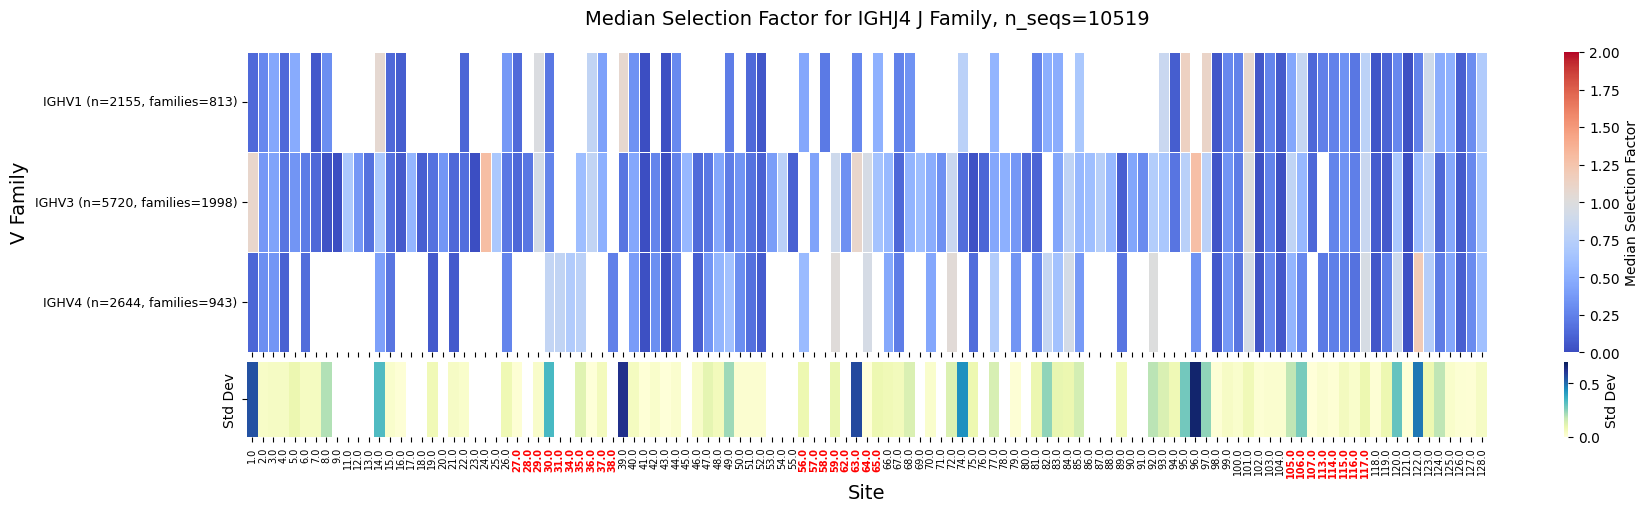

/tmp/ipykernel_4138/4239223832.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
/tmp/ipykernel_4138/4239223832.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


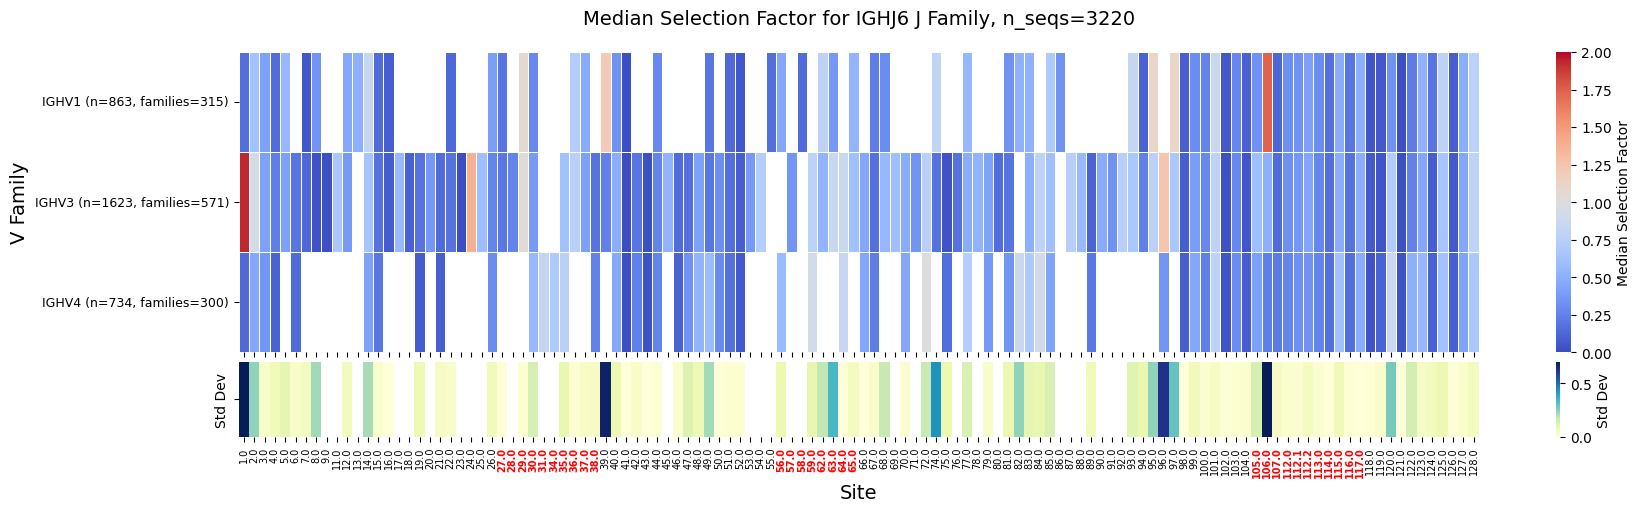

/tmp/ipykernel_4138/4239223832.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
/tmp/ipykernel_4138/4239223832.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


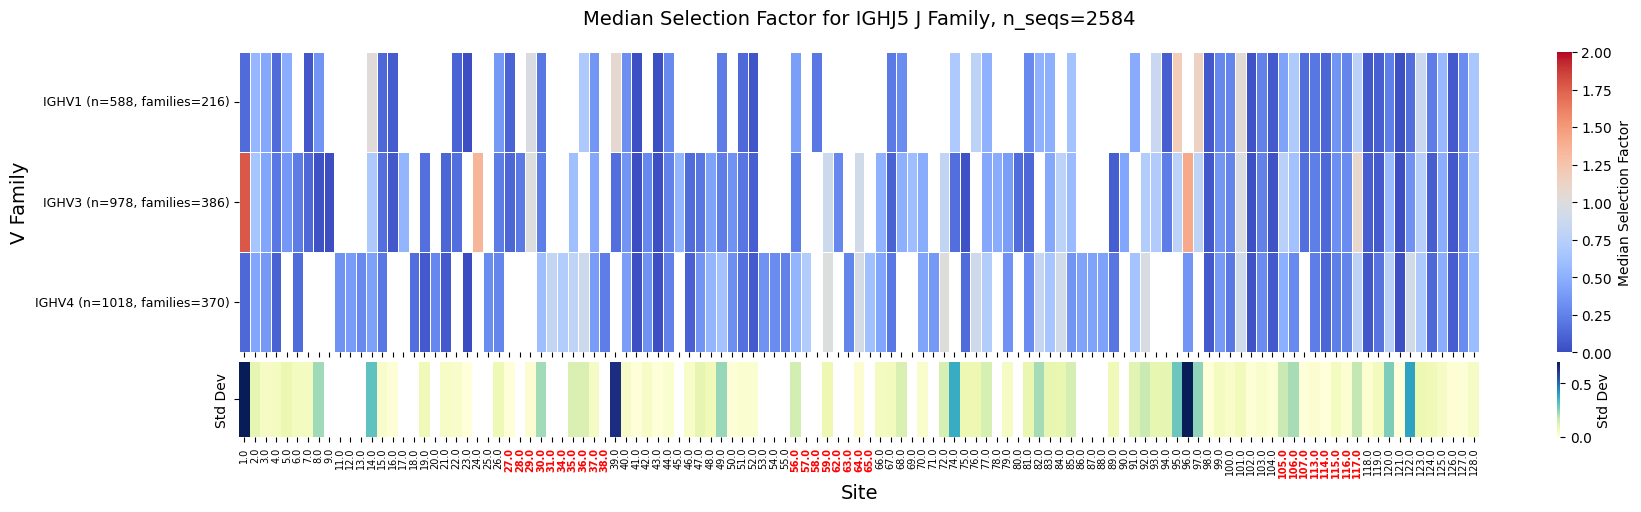

/tmp/ipykernel_4138/4239223832.py:58: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  family_clonal_families_count = df.groupby(family_column).apply(lambda x: x[['family', 'sample_id']].drop_duplicates().shape[0]).reset_index(name='unique_combinations')
/tmp/ipykernel_4138/4239223832.py:195: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


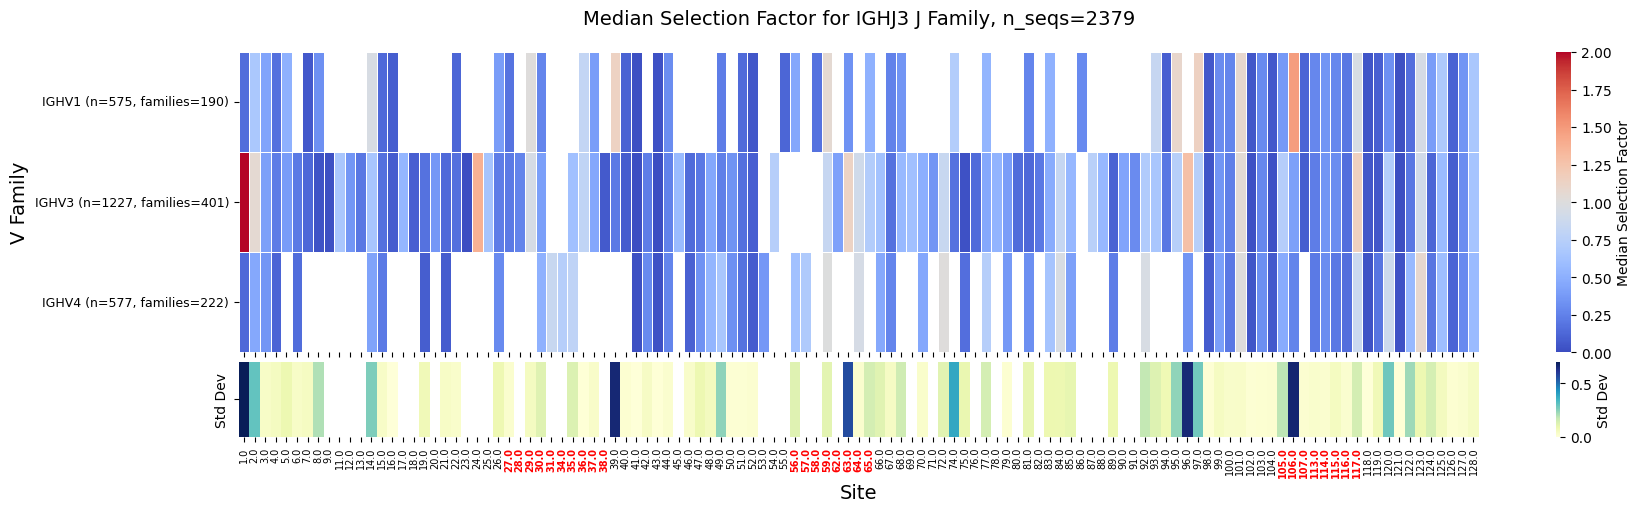

In [ ]:
# Plot mean selection factor for V families, per constant J family
for j_family in common_site_sub_probs_df['j_family'].unique():
    cur_df = common_site_sub_probs_df[common_site_sub_probs_df.j_family == j_family]
    #fig, ax = plot_selection_factor_heatmap(cur_df, family_column='v_family', title=f"Median Selection Factor for {j_family} J Family, n_seqs={cur_df['pcp_index'].nunique()}", statistic='median')
    fig, (ax1, ax2) = plot_selection_factor_heatmap(pd.merge(cur_df, get_most_common_parent_codon(cur_df), on=['site', 'parent_codon'], how='inner'), family_column='v_family', title=f"Median Selection Factor for {j_family} J Family, n_seqs={cur_df['pcp_index'].nunique()}", statistic='median')



## add germline information

In [6]:
site_sub_probs_df

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,child_aa,v_gene,j_gene,v_family,j_family,sample_id,family
0,tensor(0.1021),tensor(0.1323),tensor(0.0135),False,0,1.0,False,CAG,Q,CAG,Q,IGHV7-4-1*02,IGHJ4*02,IGHV7,IGHJ4,sample-igg-SC-24,1401
1,tensor(0.0300),tensor(0.1323),tensor(0.0040),False,1,1.0,False,CAG,Q,CAG,Q,IGHV7-4-1*02,IGHJ4*02,IGHV7,IGHJ4,sample-igg-SC-24,1401
2,tensor(0.0111),tensor(0.2299),tensor(0.0025),False,2,1.0,False,CAG,Q,CAG,Q,IGHV4-59*01,IGHJ4*02,IGHV4,IGHJ4,sample-igg-SC-24,474
3,tensor(0.0546),tensor(0.2625),tensor(0.0143),False,3,1.0,False,CAG,Q,CAG,Q,IGHV4-31*03,IGHJ6*02,IGHV4,IGHJ6,sample-igg-SC-24,238
4,tensor(0.0108),tensor(0.2625),tensor(0.0028),False,4,1.0,False,CAG,Q,CAG,Q,IGHV4-31*03,IGHJ6*02,IGHV4,IGHJ6,sample-igg-SC-24,238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646366,tensor(0.0014),tensor(1.1224),tensor(0.0016),False,21747,128.0,False,TCA,S,TCA,S,IGHV1-8*02,IGHJ1*01,IGHV1,IGHJ1,sample-igg-W-109,62
2646367,tensor(0.0018),tensor(1.0773),tensor(0.0019),False,21748,128.0,False,TCA,S,TCA,S,IGHV3-7*01,IGHJ5*02,IGHV3,IGHJ5,sample-igg-W-109,10
2646368,tensor(0.0017),tensor(1.0773),tensor(0.0019),False,21749,128.0,False,TCA,S,TCA,S,IGHV3-7*01,IGHJ5*02,IGHV3,IGHJ5,sample-igg-W-109,10
2646369,tensor(0.0018),tensor(1.2498),tensor(0.0022),False,21750,128.0,False,TCA,S,TCA,S,IGHV1-18*01,IGHJ4*02,IGHV1,IGHJ4,sample-igg-W-117,10


In [27]:
germline_codons_df = pd.read_csv(localify(f"DATA_DIR/germline_codons.csv"))
germline_codons_df['site'] = germline_codons_df['site'].astype(float)

site_sub_probs_df_germline = pd.merge(site_sub_probs_df, germline_codons_df.rename(columns={'codon':'germline_codon', 'amino_acid':'germline_amino_acid'}).drop(columns=['v_family']), on=['v_gene', 'site'], how='left')

site_sub_probs_df_germline['is_germline_aa'] = site_sub_probs_df_germline.parent_aa == site_sub_probs_df_germline.germline_amino_acid
site_sub_probs_df_germline['is_germline_codon'] = site_sub_probs_df_germline.parent_codon == site_sub_probs_df_germline.germline_codon
site_sub_probs_df_germline['selection_factor'] = site_sub_probs_df_germline['selection_factor'].apply(lambda x: x.item())
site_sub_probs_df_germline['log_selection_factor'] = site_sub_probs_df_germline['selection_factor'].apply(lambda x: np.log(x + 1e-10))  # Log normalization

AttributeError: 'str' object has no attribute 'item'

<Axes: xlabel='site', ylabel='Count'>

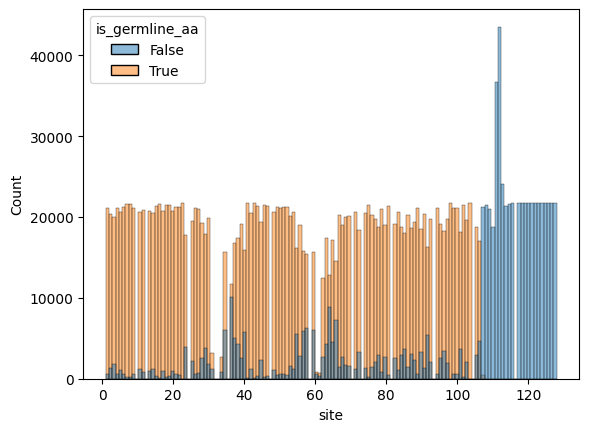

In [9]:
sns.histplot(site_sub_probs_df_germline, x='site', hue='is_germline_aa')

In [16]:
### tools for comparing two groups (can be full v families or just two v genes)

def compare_v_families(aa_site_subs_selection_df_germline, v_family1, v_family2, vcolumn='v_family', codons_or_aa='codons', lower_log_selection_factor_lim=-4, create_randomized=False):
    '''
    vcolumn: column to use for v family comparison, e.g. 'v_family' or 'v_gene'
    '''
    if codons_or_aa == 'codons':
        median_log_selection_factors_1 = aa_site_subs_selection_df_germline[(aa_site_subs_selection_df_germline.is_germline_codon == True) & (aa_site_subs_selection_df_germline[vcolumn] == v_family1)].groupby(['site', 'parent_aa', 'parent_codon']).log_selection_factor.median().reset_index().copy()
        median_log_selection_factors_2 = aa_site_subs_selection_df_germline[(aa_site_subs_selection_df_germline.is_germline_codon == True) & (aa_site_subs_selection_df_germline[vcolumn] == v_family2)].groupby(['site', 'parent_aa', 'parent_codon']).log_selection_factor.median().reset_index().copy()
        median_log_selection_factors_compare = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, on=['site', 'parent_aa', 'parent_codon'], how='inner', suffixes=('_1', '_2'))
    elif codons_or_aa == 'aa':
        median_log_selection_factors_1 = aa_site_subs_selection_df_germline[(aa_site_subs_selection_df_germline.is_germline_aa == True) & (aa_site_subs_selection_df_germline[vcolumn] == v_family1)].groupby(['site', 'parent_aa']).log_selection_factor.median().reset_index().copy()
        median_log_selection_factors_2 = aa_site_subs_selection_df_germline[(aa_site_subs_selection_df_germline.is_germline_aa == True) & (aa_site_subs_selection_df_germline[vcolumn] == v_family2)].groupby(['site', 'parent_aa']).log_selection_factor.median().reset_index().copy()
        median_log_selection_factors_compare = pd.merge(median_log_selection_factors_1, median_log_selection_factors_2, on=['site', 'parent_aa'], how='inner', suffixes=('_1', '_2'))
    
    plot_dnsm_regression(median_log_selection_factors_compare, lower_log_selection_factor_lim=lower_log_selection_factor_lim, create_randomized=create_randomized, v_family1=v_family1, v_family2=v_family2)
    plot_site_comparison(median_log_selection_factors_compare, lower_log_selection_factor_lim=-4)
    
    return median_log_selection_factors_compare

def plot_dnsm_regression(median_log_selection_factors_compare, v_family1='v_family1', v_family2='v_family2', lower_log_selection_factor_lim=-4, create_randomized=False):
    # Drop NaN values for comparison
    clean_df = median_log_selection_factors_compare.dropna(subset=['log_selection_factor_1', 'log_selection_factor_2'])

    # Trim values below lower_log_selection_factor_lim
    clean_df_trimmed = clean_df.copy()
    clean_df_trimmed['log_selection_factor_1'] = clean_df_trimmed['log_selection_factor_1'].clip(lower=lower_log_selection_factor_lim)
    clean_df_trimmed['log_selection_factor_2'] = clean_df_trimmed['log_selection_factor_2'].clip(lower=lower_log_selection_factor_lim)

    # Calculate R-squared for original data
    r_original, p_original = pearsonr(clean_df_trimmed['log_selection_factor_1'], 
                                    clean_df_trimmed['log_selection_factor_2'])
    r_squared_original = r_original**2

    # Plot for the original coupled data (with trimmed values)
    plt.figure(figsize=(7, 5))
    g1 = sns.jointplot(data=clean_df_trimmed, x='log_selection_factor_1', y='log_selection_factor_2', 
                kind='hex', height=8, gridsize=75,
                marginal_kws=dict(bins=50, fill=True))
    # add x=y line
    xlim = g1.ax_joint.get_xlim()
    ylim = g1.ax_joint.get_ylim()
    lims = [max(xlim[0], ylim[0]), min(xlim[1], ylim[1])]
    g1.ax_joint.plot(lims, lims, 'r--', alpha=0.8, linewidth=2, label='x=y')

    g1.fig.suptitle(f'{v_family1} vs {v_family2} Comparison of Log Selection Factors for Germline encoded codons\nR² = {r_squared_original:.3f}', y=1.02)
    
    plt.tight_layout()
    plt.show()

    if create_randomized:
        # Create randomized version
        np.random.seed(42)
        randomized_df = clean_df_trimmed.copy()
        randomized_df['log_selection_factor_2'] = clean_df_trimmed['log_selection_factor_2'].sample(frac=1).values

        # Calculate R-squared for randomized data
        r_random, p_random = pearsonr(randomized_df['log_selection_factor_1'], 
                                    randomized_df['log_selection_factor_2'])
        r_squared_random = r_random**2

        # Plot for the randomized coupled data
        plt.figure(figsize=(7, 5))
        g2 = sns.jointplot(data=randomized_df, x='log_selection_factor_1', y='log_selection_factor_2', 
                    kind='hex', height=8, gridsize=75,
                    marginal_kws=dict(bins=50, fill=True))
        
        # add x=y line
        xlim = g2.ax_joint.get_xlim()
        ylim = g2.ax_joint.get_ylim()
        lims = [max(xlim[0], ylim[0]), min(xlim[1], ylim[1])]
        g2.ax_joint.plot(lims, lims, 'r--', alpha=0.8, linewidth=2, label='x=y')

        g2.fig.suptitle(f'Randomized {v_family1} vs {v_family2} Comparison of Log Selection Factors for Germline encoded codons\nR² = {r_squared_random:.3f}', y=1.02)
        plt.tight_layout()
        plt.show()

    # Drop things lower than lower_log_selection_factor_lim
    clean_df_trimmed = clean_df_trimmed[(clean_df_trimmed['log_selection_factor_1'] > lower_log_selection_factor_lim) | (clean_df_trimmed['log_selection_factor_2'] > lower_log_selection_factor_lim)]

    # Calculate R-squared for filtered data
    r_filtered, p_filtered = pearsonr(clean_df_trimmed['log_selection_factor_1'], 
                                    clean_df_trimmed['log_selection_factor_2'])
    r_squared_filtered = r_filtered**2

    # Plot for the original coupled data (with filtered values)
    plt.figure(figsize=(7, 5))
    g3 = sns.jointplot(data=clean_df_trimmed, x='log_selection_factor_1', y='log_selection_factor_2', 
                kind='hex', height=8, gridsize=75,
                marginal_kws=dict(bins=50, fill=True))
    # add x=y line
    xlim = g3.ax_joint.get_xlim()
    ylim = g3.ax_joint.get_ylim()
    lims = [max(xlim[0], ylim[0]), min(xlim[1], ylim[1])]
    g3.ax_joint.plot(lims, lims, 'r--', alpha=0.8, linewidth=2, label='x=y')

    g3.fig.suptitle(f'{v_family1} vs {v_family2} Comparison of Log Selection Factors for Germline encoded codons (only over {lower_log_selection_factor_lim} log selection factor)\nR² = {r_squared_filtered:.3f}', y=1.02)
    plt.tight_layout()
    plt.show()
    if create_randomized:
        # Create randomized version for filtered data
        np.random.seed(42)
        randomized_df_filtered = clean_df_trimmed.copy()
        randomized_df_filtered['log_selection_factor_2'] = clean_df_trimmed['log_selection_factor_2'].sample(frac=1).values

        # Calculate R-squared for filtered randomized data
        r_random_filtered, p_random_filtered = pearsonr(randomized_df_filtered['log_selection_factor_1'], 
                                                        randomized_df_filtered['log_selection_factor_2'])
        r_squared_random_filtered = r_random_filtered**2

        # Plot for the randomized filtered data
        plt.figure(figsize=(7, 5))
        g4 = sns.jointplot(data=randomized_df_filtered, x='log_selection_factor_1', y='log_selection_factor_2', 
                    kind='hex', height=8, gridsize=75,
                    marginal_kws=dict(bins=50, fill=True))
            # add x=y line
        xlim = g4.ax_joint.get_xlim()
        ylim = g4.ax_joint.get_ylim()
        lims = [max(xlim[0], ylim[0]), min(xlim[1], ylim[1])]
        g4.ax_joint.plot(lims, lims, 'r--', alpha=0.8, linewidth=2, label='x=y')
        g4.fig.suptitle(f'Randomized {v_family1} vs {v_family2} Comparison of Log Selection Factors for Germline encoded codons (only over {lower_log_selection_factor_lim} log selection factor)\nR² = {r_squared_random_filtered:.3f}', y=1.02)
        plt.tight_layout()
        plt.show()


def plot_site_comparison(median_log_selection_factors_compare, lower_log_selection_factor_lim=-4):
    # Drop NaN values for comparison
    clean_df = median_log_selection_factors_compare.dropna(subset=['log_selection_factor_1', 'log_selection_factor_2'])

    site_count = len(clean_df['site'].drop_duplicates())

    # Trim values below lower_log_selection_factor_lim
    clean_df_trimmed = clean_df.copy()
    clean_df_trimmed['log_selection_factor_1'] = clean_df_trimmed['log_selection_factor_1'].clip(lower=lower_log_selection_factor_lim)
    clean_df_trimmed['log_selection_factor_2'] = clean_df_trimmed['log_selection_factor_2'].clip(lower=lower_log_selection_factor_lim)
    clean_df['abs_difference'] = (clean_df['log_selection_factor_1'] - clean_df['log_selection_factor_2']).abs()
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=clean_df, x='site', y='abs_difference', hue='selection_factor_target_aa', alpha=0.5)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(f'Absolute Difference in Log Selection Factors by Site (n={site_count})')
    plt.tight_layout()
    plt.show()



ValueError: can only convert an array of size 1 to a Python scalar

In [17]:
compare_v_families(site_sub_probs_df_germline, 'IGHV3', 'IGHV4', codons_or_aa='codons')


AttributeError: 'DataFrameGroupBy' object has no attribute 'log_selection_factor'

In [14]:
site_sub_probs_df_germline

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,...,v_gene,j_gene,v_family,j_family,sample_id,family,germline_codon,germline_amino_acid,is_germline_aa,is_germline_codon
0,tensor(0.1021),tensor(0.1323),tensor(0.0135),False,0,1.0,False,CAG,Q,CAG,...,IGHV7-4-1*02,IGHJ4*02,IGHV7,IGHJ4,sample-igg-SC-24,1401,CAG,Q,True,True
1,tensor(0.0300),tensor(0.1323),tensor(0.0040),False,1,1.0,False,CAG,Q,CAG,...,IGHV7-4-1*02,IGHJ4*02,IGHV7,IGHJ4,sample-igg-SC-24,1401,CAG,Q,True,True
2,tensor(0.0111),tensor(0.2299),tensor(0.0025),False,2,1.0,False,CAG,Q,CAG,...,IGHV4-59*01,IGHJ4*02,IGHV4,IGHJ4,sample-igg-SC-24,474,CAG,Q,True,True
3,tensor(0.0546),tensor(0.2625),tensor(0.0143),False,3,1.0,False,CAG,Q,CAG,...,IGHV4-31*03,IGHJ6*02,IGHV4,IGHJ6,sample-igg-SC-24,238,CAG,Q,True,True
4,tensor(0.0108),tensor(0.2625),tensor(0.0028),False,4,1.0,False,CAG,Q,CAG,...,IGHV4-31*03,IGHJ6*02,IGHV4,IGHJ6,sample-igg-SC-24,238,CAG,Q,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646366,tensor(0.0014),tensor(1.1224),tensor(0.0016),False,21747,128.0,False,TCA,S,TCA,...,IGHV1-8*02,IGHJ1*01,IGHV1,IGHJ1,sample-igg-W-109,62,NaN,NaN,False,False
2646367,tensor(0.0018),tensor(1.0773),tensor(0.0019),False,21748,128.0,False,TCA,S,TCA,...,IGHV3-7*01,IGHJ5*02,IGHV3,IGHJ5,sample-igg-W-109,10,NaN,NaN,False,False
2646368,tensor(0.0017),tensor(1.0773),tensor(0.0019),False,21749,128.0,False,TCA,S,TCA,...,IGHV3-7*01,IGHJ5*02,IGHV3,IGHJ5,sample-igg-W-109,10,NaN,NaN,False,False
2646369,tensor(0.0018),tensor(1.2498),tensor(0.0022),False,21750,128.0,False,TCA,S,TCA,...,IGHV1-18*01,IGHJ4*02,IGHV1,IGHJ4,sample-igg-W-117,10,NaN,NaN,False,False


### how diverged are the different families?


/tmp/ipykernel_15317/2160548233.py:46: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  numeric_pivot = pivot_data.applymap(lambda x: codon_to_num.get(x, -1))
/tmp/ipykernel_15317/2160548233.py:89: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


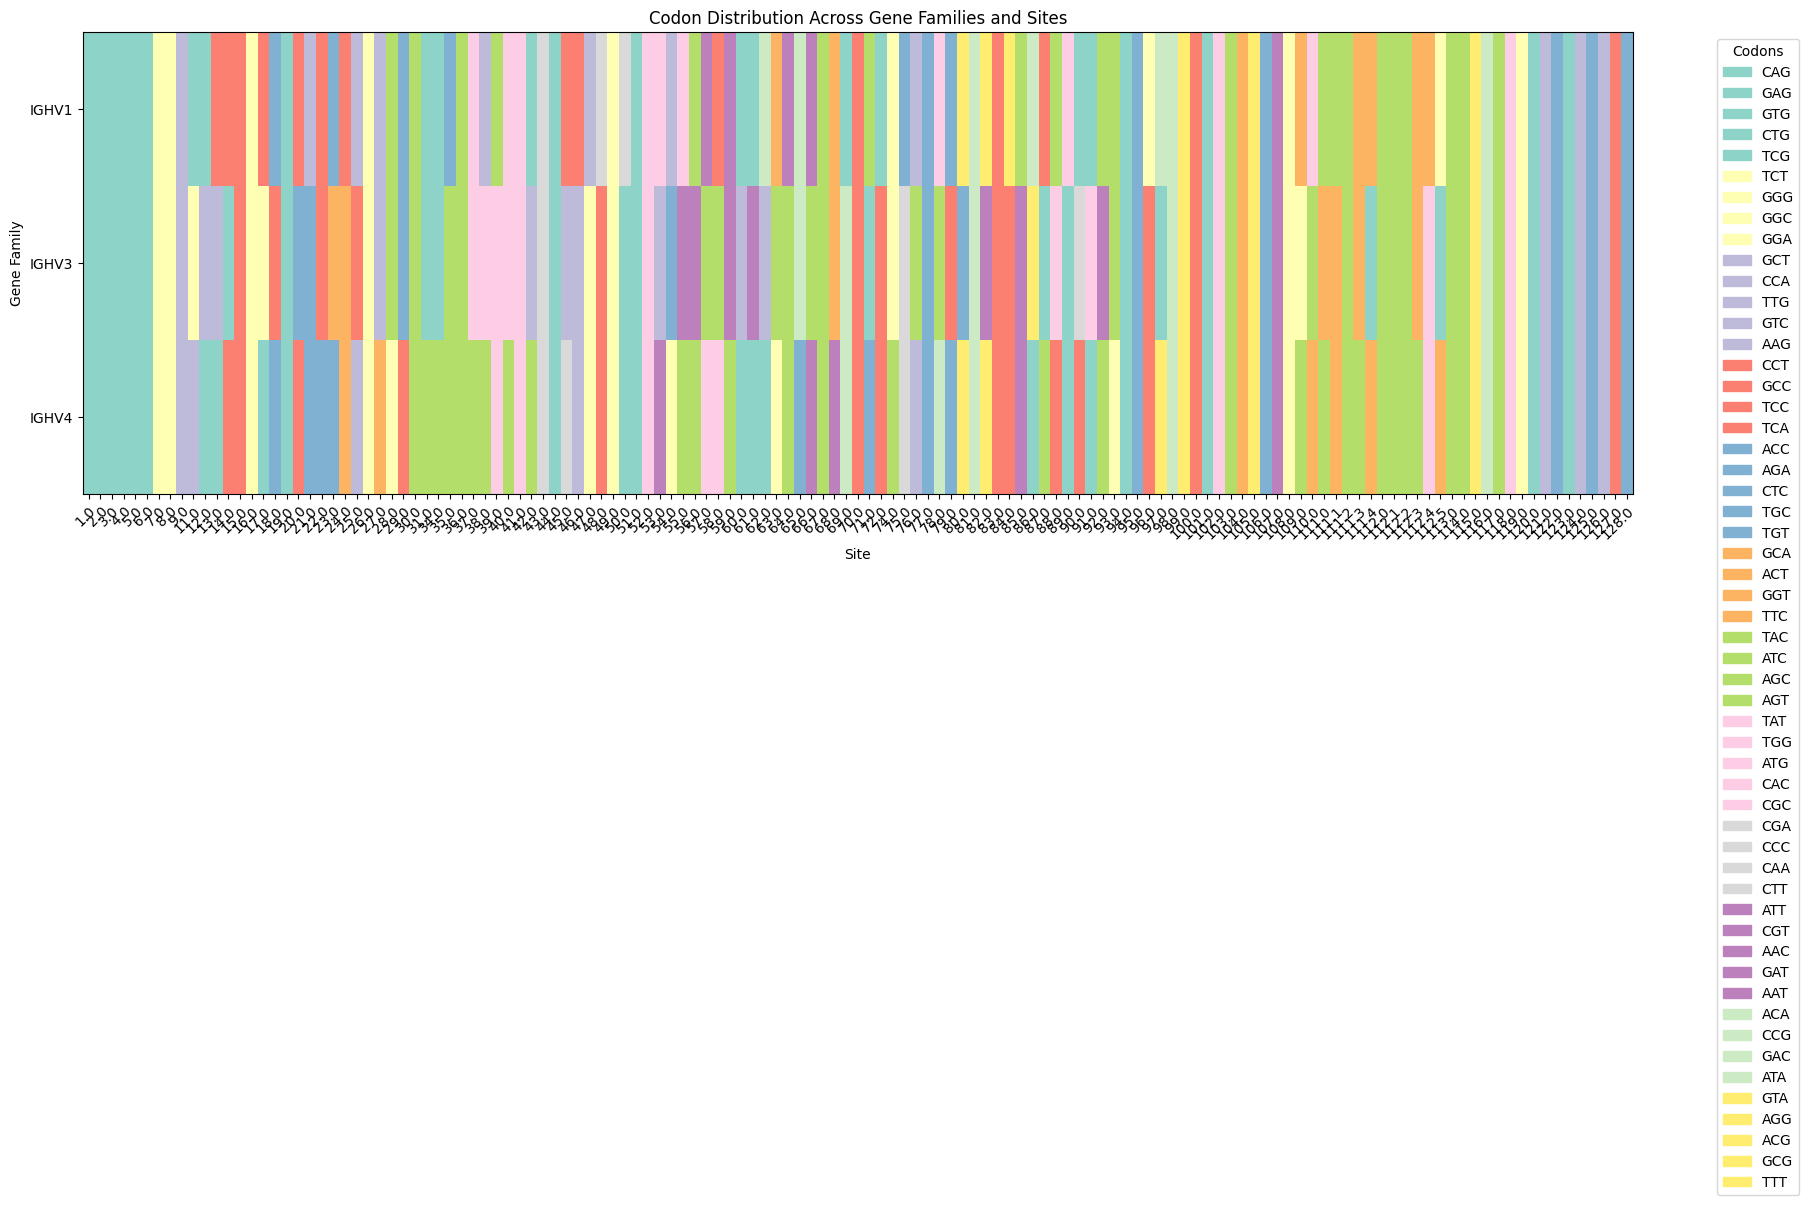

In [ ]:
import matplotlib.patches as mpatches

def plot_codon_heatmap(df, gene_family_column='gene_family', site_column='site', parent_codon_column='parent_codon'):
    """
    Create a colored heatmap showing the distribution of parent codons 
    across different gene families and sites.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe containing gene family, site, and parent codon information
    gene_family_column : str, optional
        Column name for gene families, default: 'gene_family'
    site_column : str, optional
        Column name for sites, default: 'site'
    parent_codon_column : str, optional
        Column name for parent codons, default: 'parent_codon'
    
    Returns:
    --------
    tuple
        (fig, ax) - The figure and axis objects
    """
    # Pivot the data to create a matrix of gene families, sites, and codons
    pivot_data = df.pivot_table(
        index=gene_family_column, 
        columns=site_column, 
        values=parent_codon_column, 
        aggfunc='first'
    )
    
    # Get unique codons for color mapping
    unique_codons = df[parent_codon_column].unique()
    
    # Create a color palette
    # Use a colorblind-friendly palette with enough distinct colors
    codon_colors = plt.cm.Set3(np.linspace(0, 1, len(unique_codons)))
    codon_color_dict = dict(zip(unique_codons, codon_colors))
    
    # Create the figure and axes
    fig, ax = plt.subplots(figsize=(20, 6))
    
    # Create a custom color-coded heatmap
    # Start by creating a numeric mapping of codons
    codon_to_num = {codon: i for i, codon in enumerate(unique_codons)}
    numeric_pivot = pivot_data.applymap(lambda x: codon_to_num.get(x, -1))
    
    # Plot the heatmap
    im = ax.imshow(numeric_pivot, cmap=plt.cm.Set3, aspect='auto')
    
    # Set ticks
    ax.set_xticks(np.arange(len(pivot_data.columns)))
    ax.set_yticks(np.arange(len(pivot_data.index)))
    ax.set_xticklabels(pivot_data.columns)
    ax.set_yticklabels(pivot_data.index)
    
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Add text annotations
    # for i in range(len(pivot_data.index)):
    #     for j in range(len(pivot_data.columns)):
    #         text = pivot_data.iloc[i, j]
    #         ax.text(j, i, str(text), 
    #                 ha="center", va="center", 
    #                 color="black" if text is not np.nan else "white")
    
    # Create a custom colorbar
    # Create a list of patches for the legend
    legend_patches = [
        mpatches.Patch(color=codon_color_dict[codon], label=codon) 
        for codon in unique_codons
    ]
    
    # Add the legend
    plt.legend(
        handles=legend_patches, 
        title="Codons", 
        bbox_to_anchor=(1.05, 1), 
        loc='upper left'
    )
    
    # Set title and labels
    plt.title("Codon Distribution Across Gene Families and Sites")
    plt.xlabel("Site")
    plt.ylabel("Gene Family")
    
    # Adjust layout to prevent cutting off labels
    plt.tight_layout()
    
    return fig, ax

# Example usage:
# fig, ax = plot_codon_heatmap(most_common_codon_vfam_df)

# Example usage:
fig, ax = plot_codon_heatmap(most_common_codon_vfam_df[most_common_codon_vfam_df.gene_family.isin(['IGHV3', 'IGHV4', 'IGHV1'])])

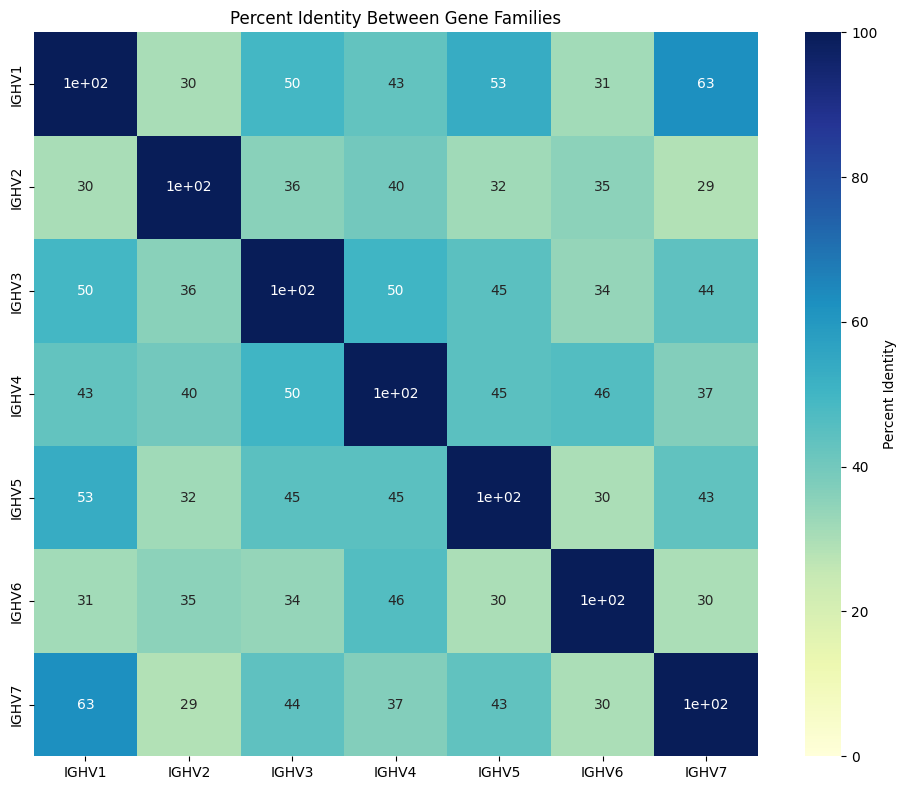

In [ ]:
def calculate_family_percent_identity(df, gene_family_column='gene_family', site_column='site', parent_codon_column='parent_codon'):
    """
    Calculate percent identity between every pair of gene families based on their codons.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe containing gene family, site, and parent codon information
    gene_family_column : str, optional
        Column name for gene families, default: 'gene_family'
    site_column : str, optional
        Column name for sites, default: 'site'
    parent_codon_column : str, optional
        Column name for parent codons, default: 'parent_codon'
    
    Returns:
    --------
    pandas.DataFrame
        Symmetric matrix of percent identities between gene families
    """
    # Pivot the data to create a matrix of gene families, sites, and codons
    pivot_data = df.pivot_table(
        index=gene_family_column, 
        columns=site_column, 
        values=parent_codon_column, 
        aggfunc='first'
    )
    
    # Get list of unique families
    families = pivot_data.index.tolist()
    
    # Create a DataFrame to store percent identities
    percent_identity_matrix = pd.DataFrame(
        index=families, 
        columns=families, 
        dtype=float
    )
    
    # Calculate percent identity for each pair of families
    for i, family1 in enumerate(families):
        for j, family2 in enumerate(families):
            # Skip comparing a family to itself
            if i == j:
                percent_identity_matrix.loc[family1, family2] = 100.0
                continue
            
            # Get codons for both families
            family1_codons = pivot_data.loc[family1].dropna()
            family2_codons = pivot_data.loc[family2].dropna()
            
            # Find common sites
            common_sites = set(family1_codons.index) & set(family2_codons.index)
            
            # Calculate identity
            if not common_sites:
                percent_identity_matrix.loc[family1, family2] = 0.0
                continue
            
            # Count matching codons
            matching_codons = sum(
                family1_codons.loc[site] == family2_codons.loc[site] 
                for site in common_sites
            )
            
            # Calculate percent identity
            percent_identity = (matching_codons / len(common_sites)) * 100
            
            # Store in both symmetric positions
            percent_identity_matrix.loc[family1, family2] = percent_identity
            percent_identity_matrix.loc[family2, family1] = percent_identity
    
    return percent_identity_matrix

def plot_percent_identity_heatmap(percent_identity_matrix):
    """
    Create a heatmap visualization of the percent identity matrix.
    
    Parameters:
    -----------
    percent_identity_matrix : pandas.DataFrame
        Matrix of percent identities between gene families
    
    Returns:
    --------
    tuple
        (fig, ax) - The figure and axis objects
    """
    # Create the figure and axes
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create the heatmap
    sns.heatmap(
        percent_identity_matrix, 
        annot=True,  # Show the actual values
        cmap='YlGnBu',  # Color palette
        center=50,  # Center the colormap at 50%
        vmin=0,  # Minimum value
        vmax=100,  # Maximum value
        square=True,  # Make the plot square
        cbar_kws={'label': 'Percent Identity'}
    )
    
    plt.title('Percent Identity Between Gene Families')
    plt.tight_layout()
    
    return fig, ax

# Example usage:
percent_identity = calculate_family_percent_identity(most_common_codon_vfam_df)
fig, ax = plot_percent_identity_heatmap(percent_identity)
# plt.show()

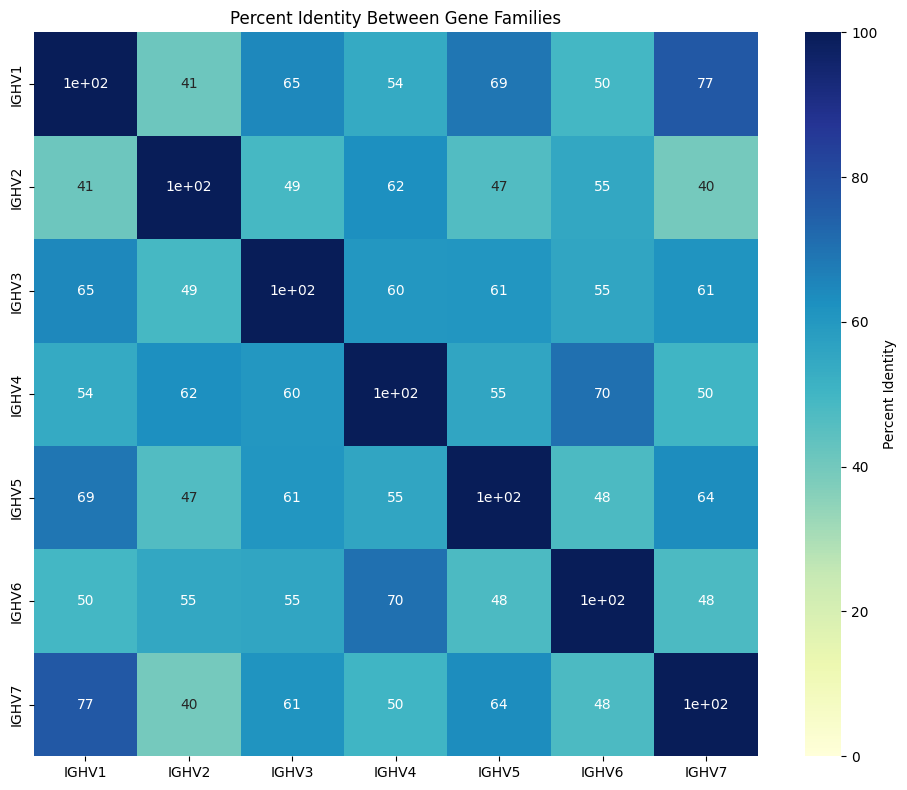

In [ ]:
percent_identity = calculate_family_percent_identity(most_common_aa_vfam_df, parent_codon_column='parent_aa')
fig, ax = plot_percent_identity_heatmap(percent_identity)
plt.show()

In [ ]:


germline_df = pd.read_csv("../data/human_ighv_aa_seqs.csv")

# drop any rows where the "sequence" column contains either a `*` or a `X`
germline_df = germline_df[~germline_df["sequence"].str.contains("[*X]")].reset_index(drop=True)

germline_df["v_family"] = germline_df["gene"].str.split("-", expand=True)[0]

max_len = max(germline_df["sequence"].apply(len))
# pad sequences with `-` to make them all the same length
germline_df["sequence"] = germline_df["sequence"].apply(lambda x: x + "-"*(max_len - len(x)))

FileNotFoundError: [Errno 2] No such file or directory: '../data/human_ighv_aa_seqs.csv'

## counts based approach

In [ ]:
site_sub_probs_df.groupby(['sample_id', 'family', 'site']).mutation.max().reset_index().groupby('site').mutation.mean()

site
1.0      0.062105
2.0      0.095220
3.0      0.142507
4.0      0.048447
5.0      0.088262
           ...   
124.0    0.026930
125.0    0.130009
126.0    0.008762
127.0    0.025126
128.0    0.055019
Name: mutation, Length: 144, dtype: float64

In [ ]:
site_sub_probs_df.groupby(['v_family', 'sample_id', 'family', 'site']).mutation.max().reset_index().groupby(['v_family', 'site']).mutation.mean().reset_index()

,v_family,site,mutation
0,IGHV1,1.0,0.042473
1,IGHV1,2.0,0.089944
2,IGHV1,3.0,0.158026
3,IGHV1,4.0,0.049969
4,IGHV1,5.0,0.115553
...,...,...,...
944,IGHV7,124.0,0.020833
945,IGHV7,125.0,0.083333
946,IGHV7,126.0,0.020833
947,IGHV7,127.0,0.020833


<Axes: >

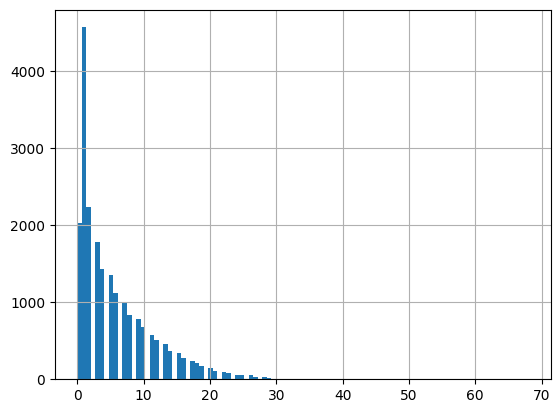

In [ ]:
# distribution of mutations count per pcp
site_sub_probs_df.groupby('pcp_index').mutation.sum().hist(bins=100)

<Axes: xlabel='site'>

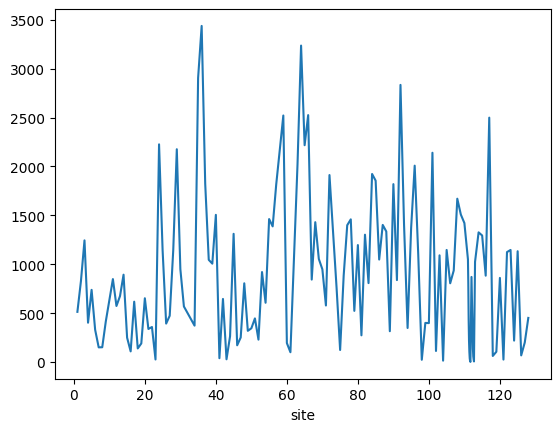

In [ ]:
# distribution of mutation counts per site
site_sub_probs_df[site_sub_probs_df.mutation == True].groupby(['site']).size().plot()

<Axes: xlabel='site'>

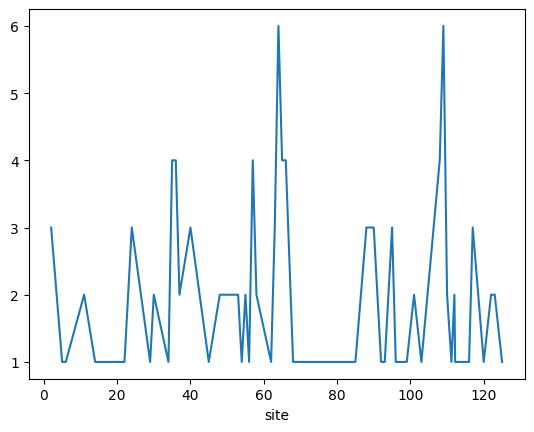

In [ ]:
site_sub_probs_df[site_sub_probs_df.family == 1401]
site_sub_probs_df[(site_sub_probs_df.mutation == True) & (site_sub_probs_df.family == 1401)].groupby(['site']).size().plot()

In [ ]:
site_sub_probs_df[site_sub_probs_df.family == 1401].pcp_index.nunique()

20

In [ ]:
site_sub_probs_df[(site_sub_probs_df.family == 1401)]

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,child_aa,v_gene_h,j_gene,v_family,j_family,sample_id,family
0,0.118513,0.078600,0.009315,False,0,1.0,False,CAG,Q,CAG,Q,IGHV7-4-1*02,IGHJ4*02,IGHV7,IGHJ4,sample-igg-SC-24,1401
1,0.035649,0.078600,0.002802,False,1,1.0,False,CAG,Q,CAG,Q,IGHV7-4-1*02,IGHJ4*02,IGHV7,IGHJ4,sample-igg-SC-24,1401
2567,0.182620,0.334433,0.061074,False,2567,1.0,False,CAG,Q,CAG,Q,IGHV4-30-2*01,IGHJ4*02,IGHV4,IGHJ4,sample-igg-SC-17,1401
2568,0.096536,0.273699,0.026422,False,2568,1.0,False,CAG,Q,CAG,Q,IGHV4-30-2*01,IGHJ4*02,IGHV4,IGHJ4,sample-igg-SC-17,1401
2569,0.024198,0.273699,0.006623,False,2569,1.0,False,CAG,Q,CAG,Q,IGHV4-30-2*01,IGHJ4*02,IGHV4,IGHJ4,sample-igg-SC-17,1401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2636533,0.027005,0.725953,0.019604,False,11898,128.0,False,TCA,S,TCA,S,IGHV3-23*01,IGHJ3*02,IGHV3,IGHJ3,sample-igg-W-103,1401
2636534,0.019640,0.725953,0.014258,False,11899,128.0,False,TCA,S,TCA,S,IGHV3-23*01,IGHJ3*02,IGHV3,IGHJ3,sample-igg-W-103,1401
2636535,0.012650,0.725953,0.009183,False,11900,128.0,False,TCA,S,TCA,S,IGHV3-23*01,IGHJ3*02,IGHV3,IGHJ3,sample-igg-W-103,1401
2640219,0.021809,0.625922,0.013650,False,15589,128.0,False,TCA,S,TCA,S,IGHV4-34*01,IGHJ4*02,IGHV4,IGHJ4,sample-igg-W-19,1401


In [ ]:
pcp_df[(site_sub_probs_df.sample_id == 'sample-igg-W-103') & (pcp_df.family == 1401)]

/tmp/ipykernel_14822/4172473784.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pcp_df[(site_sub_probs_df.sample_id == 'sample-igg-W-103') & (pcp_df.family == 1401)]


,orig_pcp_idx,sample_id,family,parent_name,child_name,branch_length,depth,distance,parent_is_naive,child_is_leaf,...,cdr2_codon_end,cdr3_codon_start,cdr3_codon_end,v_family,nt_rates,nt_csps,parent_aa,j_gene,v_gene_h,j_family
11889,195049,sample-igg-W-103,1401,Node1,1GTGGTGAGGAAT,0.055074,2,0.067365,False,True,...,171.0,288.0,327.0,IGHV3,"tensor([0.4659, 0.6480, 1.1762, 0.5008, 0.6850...","tensor([[0.1922, 0.4680, 0.0000, 0.3398],\n ...",EVQLLESGGGLVQPGGSLRLSCAASGFTFSNYAMSWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3
11890,195050,sample-igg-W-103,1401,Node1,Node2,0.020677,2,0.032967,False,False,...,171.0,288.0,327.0,IGHV3,"tensor([0.4659, 0.6480, 1.1762, 0.5008, 0.6850...","tensor([[0.1922, 0.4680, 0.0000, 0.3398],\n ...",EVQLLESGGGLVQPGGSLRLSCAASGFTFSNYAMSWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3
11891,195051,sample-igg-W-103,1401,Node2,1CGCCAATATCGC,0.067319,3,0.100287,False,True,...,171.0,288.0,327.0,IGHV3,"tensor([0.4659, 0.6480, 1.1762, 0.5008, 0.6850...","tensor([[0.1922, 0.4680, 0.0000, 0.3398],\n ...",EVQLLESGGGLVQPGGSLRLSCAASGFTFSNYAMSWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3
11892,195052,sample-igg-W-103,1401,Node2,Node3,0.031260,3,0.064227,False,False,...,171.0,288.0,327.0,IGHV3,"tensor([0.4659, 0.6480, 1.1762, 0.5008, 0.6850...","tensor([[0.1922, 0.4680, 0.0000, 0.3398],\n ...",EVQLLESGGGLVQPGGSLRLSCAASGFTFSNYAMSWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3
11893,195053,sample-igg-W-103,1401,Node3,Node4,0.041356,4,0.105583,False,False,...,171.0,288.0,327.0,IGHV3,"tensor([0.7965, 1.0768, 1.5411, 0.9170, 0.8454...","tensor([[0.2032, 0.4157, 0.0000, 0.3812],\n ...",EMQLLESGGGLVQPGGSLRLSCVASGFTFSNYAMSWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3
11894,195054,sample-igg-W-103,1401,Node4,Node5,0.030383,5,0.135966,False,False,...,171.0,288.0,327.0,IGHV3,"tensor([0.7965, 1.0768, 1.5411, 0.9170, 0.8454...","tensor([[0.2032, 0.4157, 0.0000, 0.3812],\n ...",EMQLLESGGGLVQPGGSLRLSCVASGFTFSNYAMSWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3
11895,195059,sample-igg-W-103,1401,Node4,2TTGAGCGGTTAC,0.026451,5,0.132034,False,True,...,171.0,288.0,327.0,IGHV3,"tensor([0.7965, 1.0768, 1.5411, 0.9170, 0.8454...","tensor([[0.2032, 0.4157, 0.0000, 0.3812],\n ...",EMQLLESGGGLVQPGGSLRLSCVASGFTFSNYAMSWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3
11896,195060,sample-igg-W-103,1401,Node3,Node7,0.044684,4,0.108911,False,False,...,171.0,288.0,327.0,IGHV3,"tensor([0.7965, 1.0768, 1.5411, 0.9170, 0.8454...","tensor([[0.2032, 0.4157, 0.0000, 0.3812],\n ...",EMQLLESGGGLVQPGGSLRLSCVASGFTFSNYAMSWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3
11897,195061,sample-igg-W-103,1401,Node7,Node8,0.004486,5,0.113397,False,False,...,171.0,288.0,327.0,IGHV3,"tensor([0.7965, 1.0768, 1.5411, 0.9170, 0.8454...","tensor([[0.2032, 0.4157, 0.0000, 0.3812],\n ...",EMQLLESGGGLVQPGGSLRLSCVASGFSFGNYAMNWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3
11898,195062,sample-igg-W-103,1401,Node8,Node9,0.035519,6,0.148916,False,False,...,171.0,288.0,327.0,IGHV3,"tensor([0.7965, 1.0768, 1.5411, 0.9170, 0.8454...","tensor([[0.2032, 0.4157, 0.0000, 0.3812],\n ...",EMQLLESGGGLVQPGGSLRLSCVASGFSFGNYAMNWVRQAPGKGLE...,IGHJ3*02,IGHV3-23*01,IGHJ3


## Vanwinkle data

datasets in names datasets had a lot of N's in them, so I used this to filter:

(netam_env) nharel@ermine:~/re$ python pcp-pipeline/scripts/filter_pcp_with_N_and_naive.py ~/data/v1/vanwinkle-170-igh_pcp_2025-03-05_MASKED_NI_test_no-naive_DXSMVALID.csv.gz 
Saved to: /home/nharel/data/v1/vanwinkle-170-igh_pcp_2025-03-05_MASKED_NI_test_no-naive_DXSMVALID_noN_no-naive.csv.gz

also add branch length calculation

Loading /home/nharel/data/v1/vanwinkle-170-igh_pcp_2025-03-05_MASKED_NI_test_no-naive_DXSMVALID_noN_no-naive.csv.gz
Using cached models: /home/nharel/re/netam/netam/_pretrained/thrifty-0.2.0.zip
Using ThriftyHumV0.2-59 for neutral model on device None


Evaluating model: 100%|██████████| 2437/2437 [00:04<00:00, 551.93it/s] 


Loading model
Loading branch lengths


Calculating model predictions: 100%|██████████| 24/24 [02:35<00:00,  6.48s/it]


Preparing heavy chain plot data
ANARCI seq length mismatch! 888333863-igh 17035
Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...
Computing site substitution probabilities dataframe...


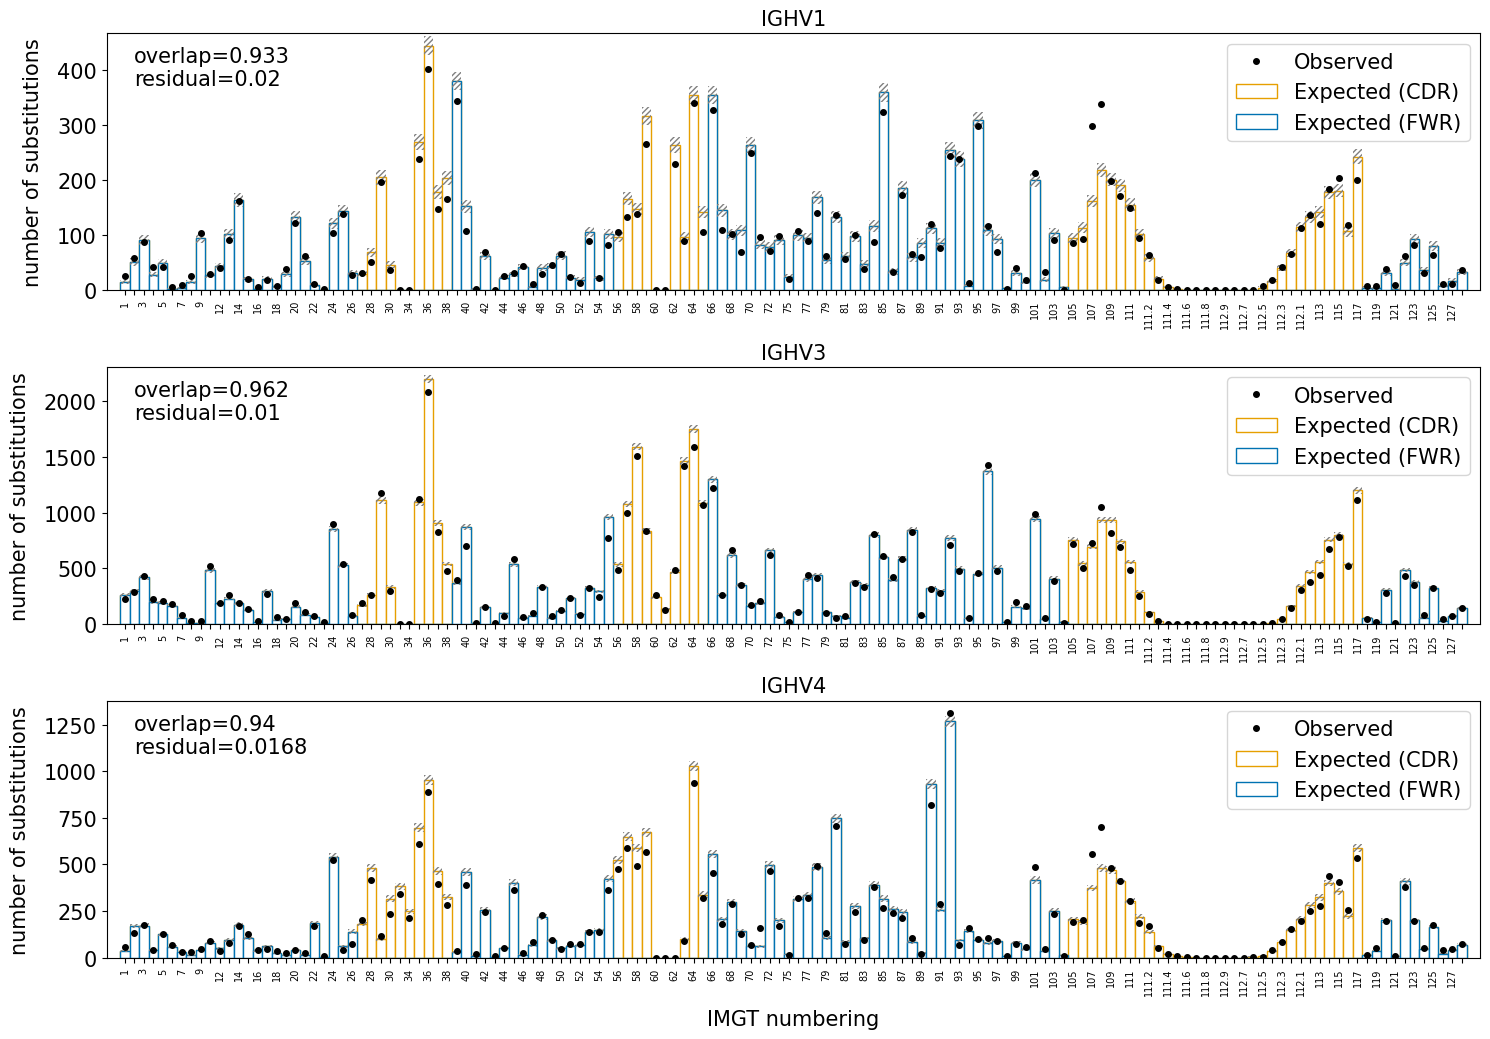

In [ ]:
dataset_name = "v1vanwinkleheavyTestnoN"
model_name = "dnsm_1m-v1jaffe+v1tang-joint"

crepe_prefix = localify(f"DNSM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DNSM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
    dnsm_zoo.write_branch_lengths("/fh/fast/matsen_e/shared/bcr-mut-sel/dnsm/dnsm-experiments-1/dnsm-train/trained_models/dnsm_1m-v1jaffe+v1tang-joint", "v1vanwinkleheavyTestnoN", f"{test_output_prefix}.branch_lengths_csv")

    # when trying to run this, I got an error about not being in the anarci dict. so I added the same entry as the 
    #     "v1vanwinkleheavyTestnoN": "DATA_DIR/anarci/vanwinkle-170-igh_anarci-seqs_imgt_H_patch.csv", is this okay??
complete_plotter, plotter_dict = write_sites_oe(
    crepe_prefix=crepe_prefix,
    dataset_name=dataset_name,
    #branch_length_path=f"/fh/fast/matsen_e/wdumm/for_noam/dnsm_1m-v1jaffe+v1tang-joint_ON_v1vanwinkleheavyTest_branch_lengths_csv",
    branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
    csv_output_path=f"{test_output_prefix}-sites-oe.csv",
    v_families=["IGHV1", "IGHV2", "IGHV3", "IGHV4", "IGHV5", "IGHV6", "IGHV7"],
    fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
    min_log_prob=-4,
    replace_title=True,
)
complete_plotter = complete_plotter["h"]

### Comparing selection factors and mutation frequencies between V3 and V4

In [ ]:

def site_sub_probs_df_without_low_freq(in_plotter, quantile_cutoff=0.05):
    site_sub_probs_df = in_plotter.site_sub_probs_df.copy()
    site_counts = site_sub_probs_df["site"].value_counts()
    cutoff = site_counts.quantile(quantile_cutoff)
    sites_above_cutoff = set(site_counts[site_counts > cutoff].index)
    site_sub_probs_df = site_sub_probs_df[site_sub_probs_df["site"].isin(sites_above_cutoff)]
    return site_sub_probs_df

def sort_df_by_site(df):
    sorted_index = natsorted(df.index, key=lambda x: df.loc[x, 'site'])
    return df.iloc[sorted_index]

def build_persite_df(site_sub_probs_df):
    persite_df = site_sub_probs_df.groupby(['site', 'is_cdr']).agg(
        mean_prob=('prob', 'mean'),
        mean_neutral_prob=('neutral_prob', 'mean'),
        mean_selection_factor=('selection_factor', 'mean'),
        mut_freq=('mutation', 'mean')
    ).reset_index()

    persite_df = sort_df_by_site(persite_df)

    return persite_df


# Assign plotters for all seven IGHV families
plotterV1 = plotter_dict["IGHV1h"]
plotterV2 = plotter_dict["IGHV2h"]
plotterV3 = plotter_dict["IGHV3h"]
plotterV4 = plotter_dict["IGHV4h"]
plotterV5 = plotter_dict["IGHV5h"]
plotterV6 = plotter_dict["IGHV6h"]
plotterV7 = plotter_dict["IGHV7h"]

# First, build persite dataframes for all seven IGHV families
# this can be used to get sites in common that are present in at least 0.05 of each family
persiteV1 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV1))
persiteV2 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV2))
persiteV3 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV3))
persiteV4 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV4))
persiteV5 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV5))
persiteV6 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV6))
persiteV7 = build_persite_df(site_sub_probs_df_without_low_freq(plotterV7))

# Create a list of all persite dataframes that are not None
persite_dfs = []
for i in range(1, 8):
    var_name = f"persiteV{i}"
    if globals()[var_name] is not None and len(globals()[var_name]) > 0:
        persite_dfs.append(globals()[var_name])

# Find common sites across all non-empty dataframes
if persite_dfs:
    common_sites = set(persite_dfs[0]["site"])
    for df in persite_dfs[1:]:
        common_sites &= set(df["site"])
    
    print(f"Found {len(common_sites)} common sites across available V families")
else:
    common_sites = set()
    print("No valid persite dataframes found")

# Restrict each persite dataframe to common sites
for i in range(1, 8):
    var_name = f"persiteV{i}"
    var_name_common = f"persiteV{i}_common"
    
    if globals()[var_name] is not None and len(globals()[var_name]) > 0:
        globals()[var_name_common] = globals()[var_name][globals()[var_name]["site"].isin(common_sites)]
        print(f"{var_name_common}: {len(globals()[var_name_common])} rows")
    else:
        globals()[var_name_common] = None
        print(f"{var_name_common} is None (source dataframe was empty)")



for plotter in plotter_dict.values():
    for colname in ["neutral_prob", "selection_factor", "prob"]:
        plotter.site_sub_probs_df[colname] = plotter.site_sub_probs_df[colname].apply(lambda it: it.item())
for colname in ["neutral_prob", "selection_factor", "prob"]:
    complete_plotter.site_sub_probs_df[colname] = complete_plotter.site_sub_probs_df[colname].apply(lambda it: it.item())


    complete_plotter.mut_obs_pred_df


In [ ]:
# add j gene data
vanwinkle_j_df = load_pcp_df('/fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/vanwinkle-170-igh_pcp_2025-03-05_MASKED_NI_no-naive_addJ.csv.gz')
complete_plotter.pcp_df = pd.merge(complete_plotter.pcp_df, vanwinkle_j_df.rename(columns={'parent_h':'parent', 'child_h':'child'})[['parent', 'child', 'j_gene', 'v_gene_h']], on=['orig_pcp_idx', 'parent', 'child'], how='left')
